# Electric Motor Temperature (PMSM) — eksploracyjna analiza danych

## Notebook #1 — charakterystyka danych przed klasteryzacją i augmentacją

**Cel:** zrozumienie jakości danych, struktury profili, rozkładów zmiennych, zależności czasowych, zachowania termicznego i elektrycznego oraz przygotowanie zaleceń do późniejszej klasteryzacji i augmentacji.

**Zbiór danych:** Kaggle — *Electric Motor Temperature*, plik `measures_v2.csv`, próbkowanie 2 Hz.

---

## 0. Cel i zakres

Notebook odpowiada na pytania:

1. Czy dane są kompletne i spójne?
2. Jak różnią się profile pracy?
3. Jak wyglądają rozkłady poszczególnych kanałów?
4. Czy sygnały wykazują multimodalność, skośność lub wartości odstające?
5. Jak wyglądają relacje między prędkością, momentem, prądami, napięciami i temperaturami?
6. Jak duże jest opóźnienie termiczne?
7. Czy profil powinien być analizowany w całości, czy w segmentach?
8. Jakie cechy powinny być używane do przyszłej klasteryzacji?
9. Jakie relacje fizyczne trzeba zachować podczas augmentacji?

Notebook **nie wykonuje końcowej klasteryzacji** — przygotowuje podstawy do dalszych etapów.

# 1. Zrozumienie domeny

W danych każda wartość `profile_id` reprezentuje niezależną sesję pomiarową. Kolejność wierszy w profilu odpowiada porządkowi czasowemu. Nie ma jawnej kolumny timestamp, dlatego oś czasu rekonstruujemy na podstawie kolejności próbek i znanej częstotliwości 2 Hz.

Kanały dzielimy na:

- **elektryczne:** `u_q`, `u_d`, `i_q`, `i_d`,
- **operacyjne:** `motor_speed`, `torque`,
- **kontekstowe:** `coolant`, `ambient`,
- **termiczne:** `pm`, `stator_yoke`, `stator_tooth`, `stator_winding`.

Temperatury traktujemy jako **wynik działania układu**, a nie bezpośrednie wejście do przyszłej klasteryzacji reżimów pracy.

# 2. Importy i konfiguracja

In [19]:
import json
import logging
import platform
import sys
import time
import warnings
from pathlib import Path
from typing import Any, Sequence

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "figure.max_open_warning": 0})

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

In [20]:
DATA_PATH = "./dataset/raw/measures_v2.csv"
ID_COL = "profile_id"

ELECTRICAL_FEATURES = ["u_q", "u_d", "i_q", "i_d"]
OPERATIONAL_FEATURES = ["motor_speed", "torque"]
CONTEXT_FEATURES = ["coolant", "ambient"]
TEMPERATURE_FEATURES = ["pm", "stator_yoke", "stator_tooth", "stator_winding"]

DRIVER_FEATURES = ELECTRICAL_FEATURES + OPERATIONAL_FEATURES
CONDITION_FEATURES = DRIVER_FEATURES + CONTEXT_FEATURES
ALL_FEATURES = CONDITION_FEATURES + TEMPERATURE_FEATURES

SAMPLING_FREQUENCY_HZ = 2
SECONDS_PER_SAMPLE = 1.0 / SAMPLING_FREQUENCY_HZ

SEGMENT_LENGTHS_SECONDS = [60, 120, 300]
SEGMENT_OVERLAP = 0.5

RANDOM_STATE = 42
OUTPUT_DIRECTORY = "eda_outputs"
FIGURE_DIRECTORY = "eda_outputs/figures"

MAX_POINTS_FOR_SCATTER = 25000
MAX_ROWS_FOR_PAIRPLOT = 6000
MAX_EXAMPLE_PROFILES_TO_PLOT = 4

USE_SYNTHETIC_DATA = False

DATA_LABEL = "real Kaggle data"

In [21]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
    stream=sys.stdout,
    force=True,
)
LOGGER = logging.getLogger("eda")

OUTPUT_DIR = Path(OUTPUT_DIRECTORY)
FIGURE_DIR = Path(FIGURE_DIRECTORY)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXPORTED_TABLES: dict[str, str] = {}

def save_figure(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=130, bbox_inches="tight")

def export_table(frame: pd.DataFrame, filename: str, description: str, index: bool = False) -> pd.DataFrame:
    frame.to_csv(OUTPUT_DIR / filename, index=index)
    EXPORTED_TABLES[filename] = description
    LOGGER.info("Zapisano %-30s (%d wierszy) -> %s", filename, len(frame), description)
    return frame

RNG = np.random.default_rng(RANDOM_STATE)

def subsample_rows(frame: pd.DataFrame, max_rows: int) -> pd.DataFrame:
    if len(frame) <= max_rows:
        return frame
    idx = np.sort(RNG.choice(len(frame), size=max_rows, replace=False))
    return frame.iloc[idx]

# 3. Wczytanie danych

In [22]:
path = Path(DATA_PATH)
if not path.exists():
    raise FileNotFoundError(
        f"Nie znaleziono pliku {path.resolve()}\n"
        "Umieść measures_v2.csv obok notebooka lub zmień DATA_PATH."
    )

raw_df = pd.read_csv(path)
print(f"Kształt danych: {raw_df.shape}")
print(f"Liczba profili: {raw_df[ID_COL].nunique()}")
raw_df.head()

Kształt danych: (1330816, 13)
Liczba profili: 69


,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.4507,18.8052,19.0867,-0.3501,18.2932,0.0029,0.0044,0.0003,24.5542,18.3165,19.8507,0.1871,17
1,-0.3257,18.8186,19.0924,-0.3058,18.2948,0.0003,0.0006,-0.0008,24.5381,18.3150,19.8507,0.2454,17
2,-0.4409,18.8288,19.0894,-0.3725,18.2941,0.0024,0.0013,0.0004,24.5447,18.3263,19.8507,0.1766,17
3,-0.3270,18.8356,19.0830,-0.3162,18.2925,0.0061,0.0000,0.0020,24.5540,18.3308,19.8506,0.2383,17
4,-0.4712,18.8570,19.0825,-0.3323,18.2914,0.0031,-0.0643,0.0372,24.5654,18.3267,19.8506,0.2082,17


# 4. Jakość danych

## 4.1 Walidacja jakości i typów danych dla każdej kolumny

Dla każdej zmiennej raportujemy typ danych, liczbę wartości niepustych, udział braków, liczbę wartości nieskończonych, liczbę wartości unikalnych oraz informację, czy kolumna jest stała.

In [23]:
def build_quality_report(frame: pd.DataFrame) -> pd.DataFrame:
    records = []

    for col in frame.columns:
        series = frame[col]
        is_numeric = pd.api.types.is_numeric_dtype(series)
        n_inf = int(np.isinf(series.to_numpy()).sum()) if is_numeric else 0
        nunique = int(series.nunique(dropna=True))

        records.append({
            "column": col,
            "dtype": str(series.dtype),
            "non_null": int(series.notna().sum()),
            "missing": int(series.isna().sum()),
            "missing_pct": 100.0 * series.isna().mean(),
            "n_infinite": n_inf,
            "n_unique": nunique,
            "is_constant": nunique <= 1,
            "mean": series.mean() if is_numeric else np.nan,
            "std": series.std() if is_numeric else np.nan,
        })

    return pd.DataFrame(records)

quality_report = build_quality_report(raw_df)
export_table(quality_report, "data_quality_report.csv", "Audyt jakości danych dla każdej kolumny")
quality_report

23:57:53 | INFO    | Zapisano data_quality_report.csv        (13 wierszy) -> Audyt jakości danych dla każdej kolumny


,column,dtype,non_null,missing,missing_pct,n_infinite,n_unique,is_constant,mean,std
0,u_q,float64,1330816,0,0.0000,0,1271775,False,54.2790,44.1732
1,coolant,float64,1330816,0,0.0000,0,1110504,False,36.2300,21.7861
2,stator_winding,float64,1330816,0,0.0000,0,1262754,False,66.3427,28.6721
3,u_d,float64,1330816,0,0.0000,0,1295778,False,-25.1338,63.0920
4,stator_tooth,float64,1330816,0,0.0000,0,1229045,False,56.8786,22.9522
5,motor_speed,float64,1330816,0,0.0000,0,777565,False,2202.0807,1859.6634
6,i_d,float64,1330816,0,0.0000,0,1047491,False,-68.7168,64.9332
7,i_q,float64,1330816,0,0.0000,0,1024944,False,37.4128,92.1819
8,pm,float64,1330816,0,0.0000,0,1316978,False,58.5068,19.0015
9,stator_yoke,float64,1330816,0,0.0000,0,1228478,False,48.1880,19.9910


## 4.2 Duplikaty, integralność identyfikatora i walidacja globalna

In [24]:
n_duplicate_rows = int(raw_df.duplicated().sum())

id_series = raw_df[ID_COL]
id_is_integer_like = bool(np.allclose(id_series.dropna() % 1, 0))
id_has_missing = bool(id_series.isna().any())
id_min = id_series.min()

n_infinite_total = int(quality_report["n_infinite"].sum())

qidx = quality_report.set_index("column")
constant_sensor_cols = [
    c for c in ALL_FEATURES
    if c in qidx.index and bool(qidx.loc[c, "is_constant"])
]

missing_sensor_cols = [
    c for c in ALL_FEATURES
    if c in qidx.index and int(qidx.loc[c, "missing"]) > 0
]

validation = pd.DataFrame({
    "check": [
        "duplicate rows",
        "profile_id integer-like",
        "profile_id has missing",
        "profile_id minimum",
        "total infinite values",
        "constant sensor channels",
        "sensor columns with missing values",
    ],
    "result": [
        f"{n_duplicate_rows}",
        str(id_is_integer_like),
        str(id_has_missing),
        f"{id_min}",
        f"{n_infinite_total}",
        ", ".join(constant_sensor_cols) if constant_sensor_cols else "none",
        ", ".join(missing_sensor_cols) if missing_sensor_cols else "none",
    ],
    "status": [
        "OK" if n_duplicate_rows == 0 else "REVIEW",
        "OK" if id_is_integer_like else "REVIEW",
        "OK" if not id_has_missing else "REVIEW",
        "OK" if pd.notna(id_min) and id_min >= 0 else "REVIEW",
        "OK" if n_infinite_total == 0 else "REVIEW",
        "OK" if not constant_sensor_cols else "REVIEW",
        "OK" if not missing_sensor_cols else "REVIEW",
    ],
})

print("Podsumowanie walidacji")
print("-" * 60)
validation

Podsumowanie walidacji
------------------------------------------------------------


,check,result,status
0,duplicate rows,0,OK
1,profile_id integer-like,True,OK
2,profile_id has missing,False,OK
3,profile_id minimum,2,OK
4,total infinite values,0,OK
5,constant sensor channels,none,OK
6,sensor columns with missing values,none,OK


> **Wynik statystyczny.** Raport jakości zawiera dokładną liczbę wierszy i kolumn, liczbę profili, liczbę braków i wartości nieskończonych oraz informacje o typach danych.
>
> **Interpretacja dziedzinowa.** Wszystkie flagi `REVIEW` należy rozwiązać przed klasteryzacją i augmentacją. Stały kanał nie wnosi informacji rozdzielającej, a braki utrudniają obliczanie odległości.

# 5. Analiza profili

Każdy `profile_id` jest niezależną sesją pomiarową z własną długością i dynamiką. Profilów nie wolno łączyć ze sobą podczas budowy segmentów.

In [25]:
work_df = raw_df.copy()
work_df["_row_in_profile"] = work_df.groupby(ID_COL).cumcount()
work_df["_time_seconds"] = work_df["_row_in_profile"] * SECONDS_PER_SAMPLE

profile_ids = sorted(work_df[ID_COL].unique())
n_profiles = len(profile_ids)
grouped = work_df.groupby(ID_COL)

print(f"Liczba profili: {n_profiles}")
print(f"Zakres profile_id: {min(profile_ids)} ... {max(profile_ids)}")

Liczba profili: 69
Zakres profile_id: 2 ... 81


## 5.1 Tabela podsumowująca profile

In [26]:
def summarise_profile(
    pid: int,
    frame: pd.DataFrame,
    fixed_edge_seconds: float = 60.0,
    fs: float | None = None,
) -> dict[str, Any]:
    if fs is None:
        fs = float(SAMPLING_FREQUENCY_HZ)

    n = len(frame)
    duration_s = n / fs
    edge_samples = max(1, min(int(fixed_edge_seconds * fs), n // 4))

    temp_mean_series = frame[TEMPERATURE_FEATURES].mean(axis=1)
    temp_zagr_start = float(temp_mean_series.iloc[:edge_samples].mean())
    temp_zagr_end = float(temp_mean_series.iloc[-edge_samples:].mean())
    temp_zagr_mean = float(temp_mean_series.mean())
    temp_zagr_min = float(temp_mean_series.min())
    temp_zagr_max = float(temp_mean_series.max())

    return {
        ID_COL: pid,
        "n_samples": n,
        "samples": n,
        "duration_s": duration_s,
        "duration_min": duration_s / 60.0,
        "temp_zagr_min": temp_zagr_min,
        "temp_zagr_mean": temp_zagr_mean,
        "temp_zagr_max": temp_zagr_max,
        "temp_zagr_start": temp_zagr_start,
        "temp_zagr_end": temp_zagr_end,
        "temp_delta": temp_zagr_max - temp_zagr_min,
        "stator_winding_max": float(frame["stator_winding"].max()),
        "pm_max": float(frame["pm"].max()),
        "avg_speed": float(frame["motor_speed"].mean()),
        "avg_torque": float(frame["torque"].mean()),
        "speed_std": float(frame["motor_speed"].std()),
        "torque_std": float(frame["torque"].std()),
        "dynamics_score": float(frame[DRIVER_FEATURES].std().mean()),
        "avg_temperature": temp_zagr_mean,
        "min_temperature": temp_zagr_min,
        "max_temperature": temp_zagr_max,
        "temperature_increase": temp_zagr_end - temp_zagr_start,
    }

profile_summary = pd.DataFrame([
    summarise_profile(pid, grouped.get_group(pid))
    for pid in profile_ids
])

export_table(profile_summary, "profile_summary.csv",
             "Podsumowanie wielkości, czasu i zachowania profili")

shortest_profile = int(profile_summary.loc[profile_summary["samples"].idxmin(), ID_COL])
longest_profile = int(profile_summary.loc[profile_summary["samples"].idxmax(), ID_COL])
most_variable_profile = int(profile_summary.loc[profile_summary["dynamics_score"].idxmax(), ID_COL])
least_variable_profile = int(profile_summary.loc[profile_summary["dynamics_score"].idxmin(), ID_COL])
hottest_profile = int(profile_summary.loc[profile_summary["temp_zagr_max"].idxmax(), ID_COL])
coldest_profile = int(profile_summary.loc[profile_summary["temp_zagr_min"].idxmin(), ID_COL])

print(f"Najkrótszy profil: {shortest_profile}")
print(f"Najdłuższy profil: {longest_profile}")
print(f"Najbardziej dynamiczny profil: {most_variable_profile}")
print(f"Najmniej dynamiczny profil: {least_variable_profile}")
print(f"Najgorętszy profil: {hottest_profile}")
print(f"Najzimniejszy profil: {coldest_profile}")

print(profile_summary.sort_values("temp_zagr_max", ascending=False).head(5))
print("========================")
profile_summary.sort_values("temp_zagr_mean", ascending=False).head(20)


23:57:54 | INFO    | Zapisano profile_summary.csv            (69 wierszy) -> Podsumowanie wielkości, czasu i zachowania profili
Najkrótszy profil: 47
Najdłuższy profil: 20
Najbardziej dynamiczny profil: 29
Najmniej dynamiczny profil: 7
Najgorętszy profil: 79
Najzimniejszy profil: 13
    profile_id  n_samples  samples  duration_s  duration_min  temp_zagr_min  temp_zagr_mean  temp_zagr_max  temp_zagr_start  temp_zagr_end  temp_delta  \
66          79      31154    31154  15577.0000      259.6167        24.4740         69.2991       107.7888          28.5422        80.7421     83.3148   
46          58      33382    33382  16691.0000      278.1833        36.4303         75.9037       107.4585          40.0293        66.8513     71.0282   
63          75      13472    13472   6736.0000      112.2667        22.4101         70.6980       107.2712          26.0917        43.3547     84.8610   
34          46       2180     2180   1090.0000       18.1667        90.4077        100.4991       10

,profile_id,n_samples,samples,duration_s,duration_min,temp_zagr_min,temp_zagr_mean,temp_zagr_max,temp_zagr_start,temp_zagr_end,temp_delta,stator_winding_max,pm_max,avg_speed,avg_torque,speed_std,torque_std,dynamics_score,avg_temperature,min_temperature,max_temperature,temperature_increase
34,46,2180,2180,1090.0000,18.1667,90.4077,100.4991,107.0685,93.5909,102.6161,16.6607,127.5048,92.9146,2625.3810,-23.6169,1343.5954,83.4487,283.0461,100.4991,90.4077,107.0685,9.0252
44,56,33123,33123,16561.5000,276.0250,47.5554,80.9621,106.6994,84.1040,86.2492,59.1440,131.6751,97.5527,2360.8304,4.9210,1291.3382,105.2704,281.2413,80.9621,47.5554,106.6994,2.1452
47,59,7475,7475,3737.5000,62.2917,55.3101,80.8689,105.7258,71.1465,58.4987,50.4158,132.7246,92.4374,2714.6521,31.6186,1248.0840,90.7052,269.7790,80.8689,55.3101,105.7258,-12.6478
39,51,6261,6261,3130.5000,52.1750,42.3888,80.0734,99.8993,45.9075,92.4991,57.5106,122.7929,84.5971,2855.3166,-29.3319,1497.9766,106.6397,317.4572,80.0734,42.3888,99.8993,46.5916
46,58,33382,33382,16691.0000,278.1833,36.4303,75.9037,107.4585,40.0293,66.8513,71.0282,131.1544,92.9798,3070.3076,37.1274,1316.4612,79.1778,274.8392,75.9037,36.4303,107.4585,26.8220
37,49,10816,10816,5408.0000,90.1333,45.8431,75.2517,94.7724,47.5145,94.4510,48.9293,128.0469,81.9199,2722.7862,3.8090,1622.1042,117.4919,339.8367,75.2517,45.8431,94.7724,46.9365
21,24,15015,15015,7507.5000,125.1250,19.8158,74.8577,97.8276,23.9208,49.2946,78.0118,123.2649,113.6066,5494.8057,37.2142,152.8515,31.6439,63.2873,74.8577,19.8158,97.8276,25.3738
17,19,10410,10410,5205.0000,86.7500,20.1716,74.1285,82.8771,22.6336,57.2357,62.7055,102.3750,96.7841,5979.2328,39.5391,339.4179,19.4305,78.6665,74.1285,20.1716,82.8771,34.6021
49,61,14516,14516,7258.0000,120.9667,46.6979,73.6259,105.9806,85.7330,73.1591,59.2827,129.6652,92.7644,2248.0652,3.7083,1868.9814,82.5349,370.5969,73.6259,46.6979,105.9806,-12.5739
62,74,23761,23761,11880.5000,198.0083,49.9460,73.3156,105.1854,72.6122,63.0149,55.2394,129.2834,91.9251,2091.7207,-13.3631,1936.5356,82.6257,382.5380,73.3156,49.9460,105.1854,-9.5973


In [27]:
# Profile o najwyższej/najniższej średniej, maksymalnej oraz minimalnej temperaturze
hottest_avg_idx = profile_summary["temp_zagr_mean"].idxmax()
coldest_avg_idx = profile_summary["temp_zagr_mean"].idxmin()
hottest_max_idx = profile_summary["temp_zagr_max"].idxmax()
coldest_min_idx = profile_summary["temp_zagr_min"].idxmin()

def profile_temp_extrema_row(selection: str, idx: int) -> dict[str, Any]:
    row = profile_summary.loc[idx]
    pid = int(row[ID_COL])
    return {
        "selection": selection,
        ID_COL: pid,
        "temp_zagr_min": float(row["temp_zagr_min"]),
        "temp_zagr_mean": float(row["temp_zagr_mean"]),
        "temp_zagr_max": float(row["temp_zagr_max"]),
        "temp_zagr_start": float(row["temp_zagr_start"]),
        "temp_zagr_end": float(row["temp_zagr_end"]),
        "temp_delta": float(row["temp_delta"]),
        "stator_winding_max": float(row["stator_winding_max"]),
        "pm_max": float(row["pm_max"]),
    }


profile_summary_temp_extrema = pd.DataFrame([
    profile_temp_extrema_row("highest_avg_temperature", hottest_avg_idx),
    profile_temp_extrema_row("lowest_avg_temperature", coldest_avg_idx),
    profile_temp_extrema_row("highest_max_temperature", hottest_max_idx),
    profile_temp_extrema_row("lowest_min_temperature", coldest_min_idx),
])


# Ekstrema dla poszczególnych kanałów temperaturowych
temp_extrema_rows = []

for col in TEMPERATURE_FEATURES:
    max_idx = work_df[col].idxmax()
    min_idx = work_df[col].idxmin()
    avg_by_profile = grouped[col].mean()

    hottest_avg_profile = avg_by_profile.idxmax()
    coldest_avg_profile = avg_by_profile.idxmin()

    min_temp = float(work_df.loc[min_idx, col])
    max_temp = float(work_df.loc[max_idx, col])

    temp_extrema_rows.append({
        "temperature_variable": col,
        "profile_id_min_temperature": int(work_df.loc[min_idx, ID_COL]),
        "min_temperature": min_temp,
        "profile_id_max_temperature": int(work_df.loc[max_idx, ID_COL]),
        "max_temperature": max_temp,
        "delta_temperature": max_temp - min_temp,
        "profile_id_lowest_avg_temperature": int(coldest_avg_profile),
        "lowest_avg_temperature": float(avg_by_profile.loc[coldest_avg_profile]),
        "profile_id_highest_avg_temperature": int(hottest_avg_profile),
        "highest_avg_temperature": float(avg_by_profile.loc[hottest_avg_profile]),
    })

temp_extrema_summary = pd.DataFrame(temp_extrema_rows)


# Eksport
export_table(
    profile_summary_temp_extrema,
    "profile_summary_temperature_extrema.csv",
    "Profile z najwyższą i najniższą średnią oraz maksymalną i minimalną temperaturą",
)

export_table(
    temp_extrema_summary,
    "temperature_extrema_by_vars.csv",
    "Profile z temperaturą maksymalną, minimalną oraz najwyższą i najniższą średnią "
    "dla poszczególnych zmiennych termicznych",
)


# Podgląd wyników
print("\n\nProfile o najwyższej/najniższej średniej, maksymalnej i minimalnej temperaturze uśrednionej:")
display(profile_summary_temp_extrema)

print("Profile o najwyższej/najniższej średniej, maksymalnej i minimalnej dla poszczególnych zmiennych termicznych:")
display(temp_extrema_summary)

23:57:54 | INFO    | Zapisano profile_summary_temperature_extrema.csv (4 wierszy) -> Profile z najwyższą i najniższą średnią oraz maksymalną i minimalną temperaturą
23:57:54 | INFO    | Zapisano temperature_extrema_by_vars.csv (4 wierszy) -> Profile z temperaturą maksymalną, minimalną oraz najwyższą i najniższą średnią dla poszczególnych zmiennych termicznych


Profile o najwyższej/najniższej średniej, maksymalnej i minimalnej temperaturze uśrednionej:


,selection,profile_id,temp_zagr_min,temp_zagr_mean,temp_zagr_max,temp_zagr_start,temp_zagr_end,temp_delta,stator_winding_max,pm_max
0,highest_avg_temperature,46,90.4077,100.4991,107.0685,93.5909,102.6161,16.6607,127.5048,92.9146
1,lowest_avg_temperature,3,19.7333,25.6979,31.4284,20.9346,19.8590,11.6951,39.1018,29.0116
2,highest_max_temperature,79,24.4740,69.2991,107.7888,28.5422,80.7421,83.3148,128.2466,97.1533
3,lowest_min_temperature,13,19.1907,26.6644,32.4885,19.7740,20.3020,13.2978,39.4498,31.8783


Profile o najwyższej/najniższej średniej, maksymalnej i minimalnej dla poszczególnych zmiennych termicznych:


,temperature_variable,profile_id_min_temperature,min_temperature,profile_id_max_temperature,max_temperature,delta_temperature,profile_id_lowest_avg_temperature,lowest_avg_temperature,profile_id_highest_avg_temperature,highest_avg_temperature
0,pm,21,20.8570,24,113.6066,92.7497,3,26.2851,46,88.9849
1,stator_yoke,5,18.0767,58,101.1480,83.0713,3,22.5614,46,96.4384
2,stator_tooth,4,18.1340,73,111.9464,93.8124,3,24.9112,46,103.1007
3,stator_winding,4,18.5858,29,141.3629,122.7771,3,29.0338,46,113.4722


In [28]:
%whos DataFrame

Variable                       Type         Data/Info
-----------------------------------------------------
df_sub                         DataFrame    Shape: (88488, 2)
profile                        DataFrame    Shape: (35906, 17)
profile_df                     DataFrame    Shape: (35906, 16)
profile_summary                DataFrame    Shape: (69, 22)
profile_summary_temp_extrema   DataFrame    Shape: (4, 10)
qidx                           DataFrame    Shape: (13, 9)
quality_report                 DataFrame    Shape: (13, 10)
raw_df                         DataFrame    Shape: (1330816, 13)
temp_extrema_summary           DataFrame    Shape: (4, 10)
validation                     DataFrame    Shape: (7, 3)
work_df                        DataFrame    Shape: (1330816, 15)


23:57:54 | INFO    | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
23:57:54 | INFO    | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
23:57:54 | INFO    | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


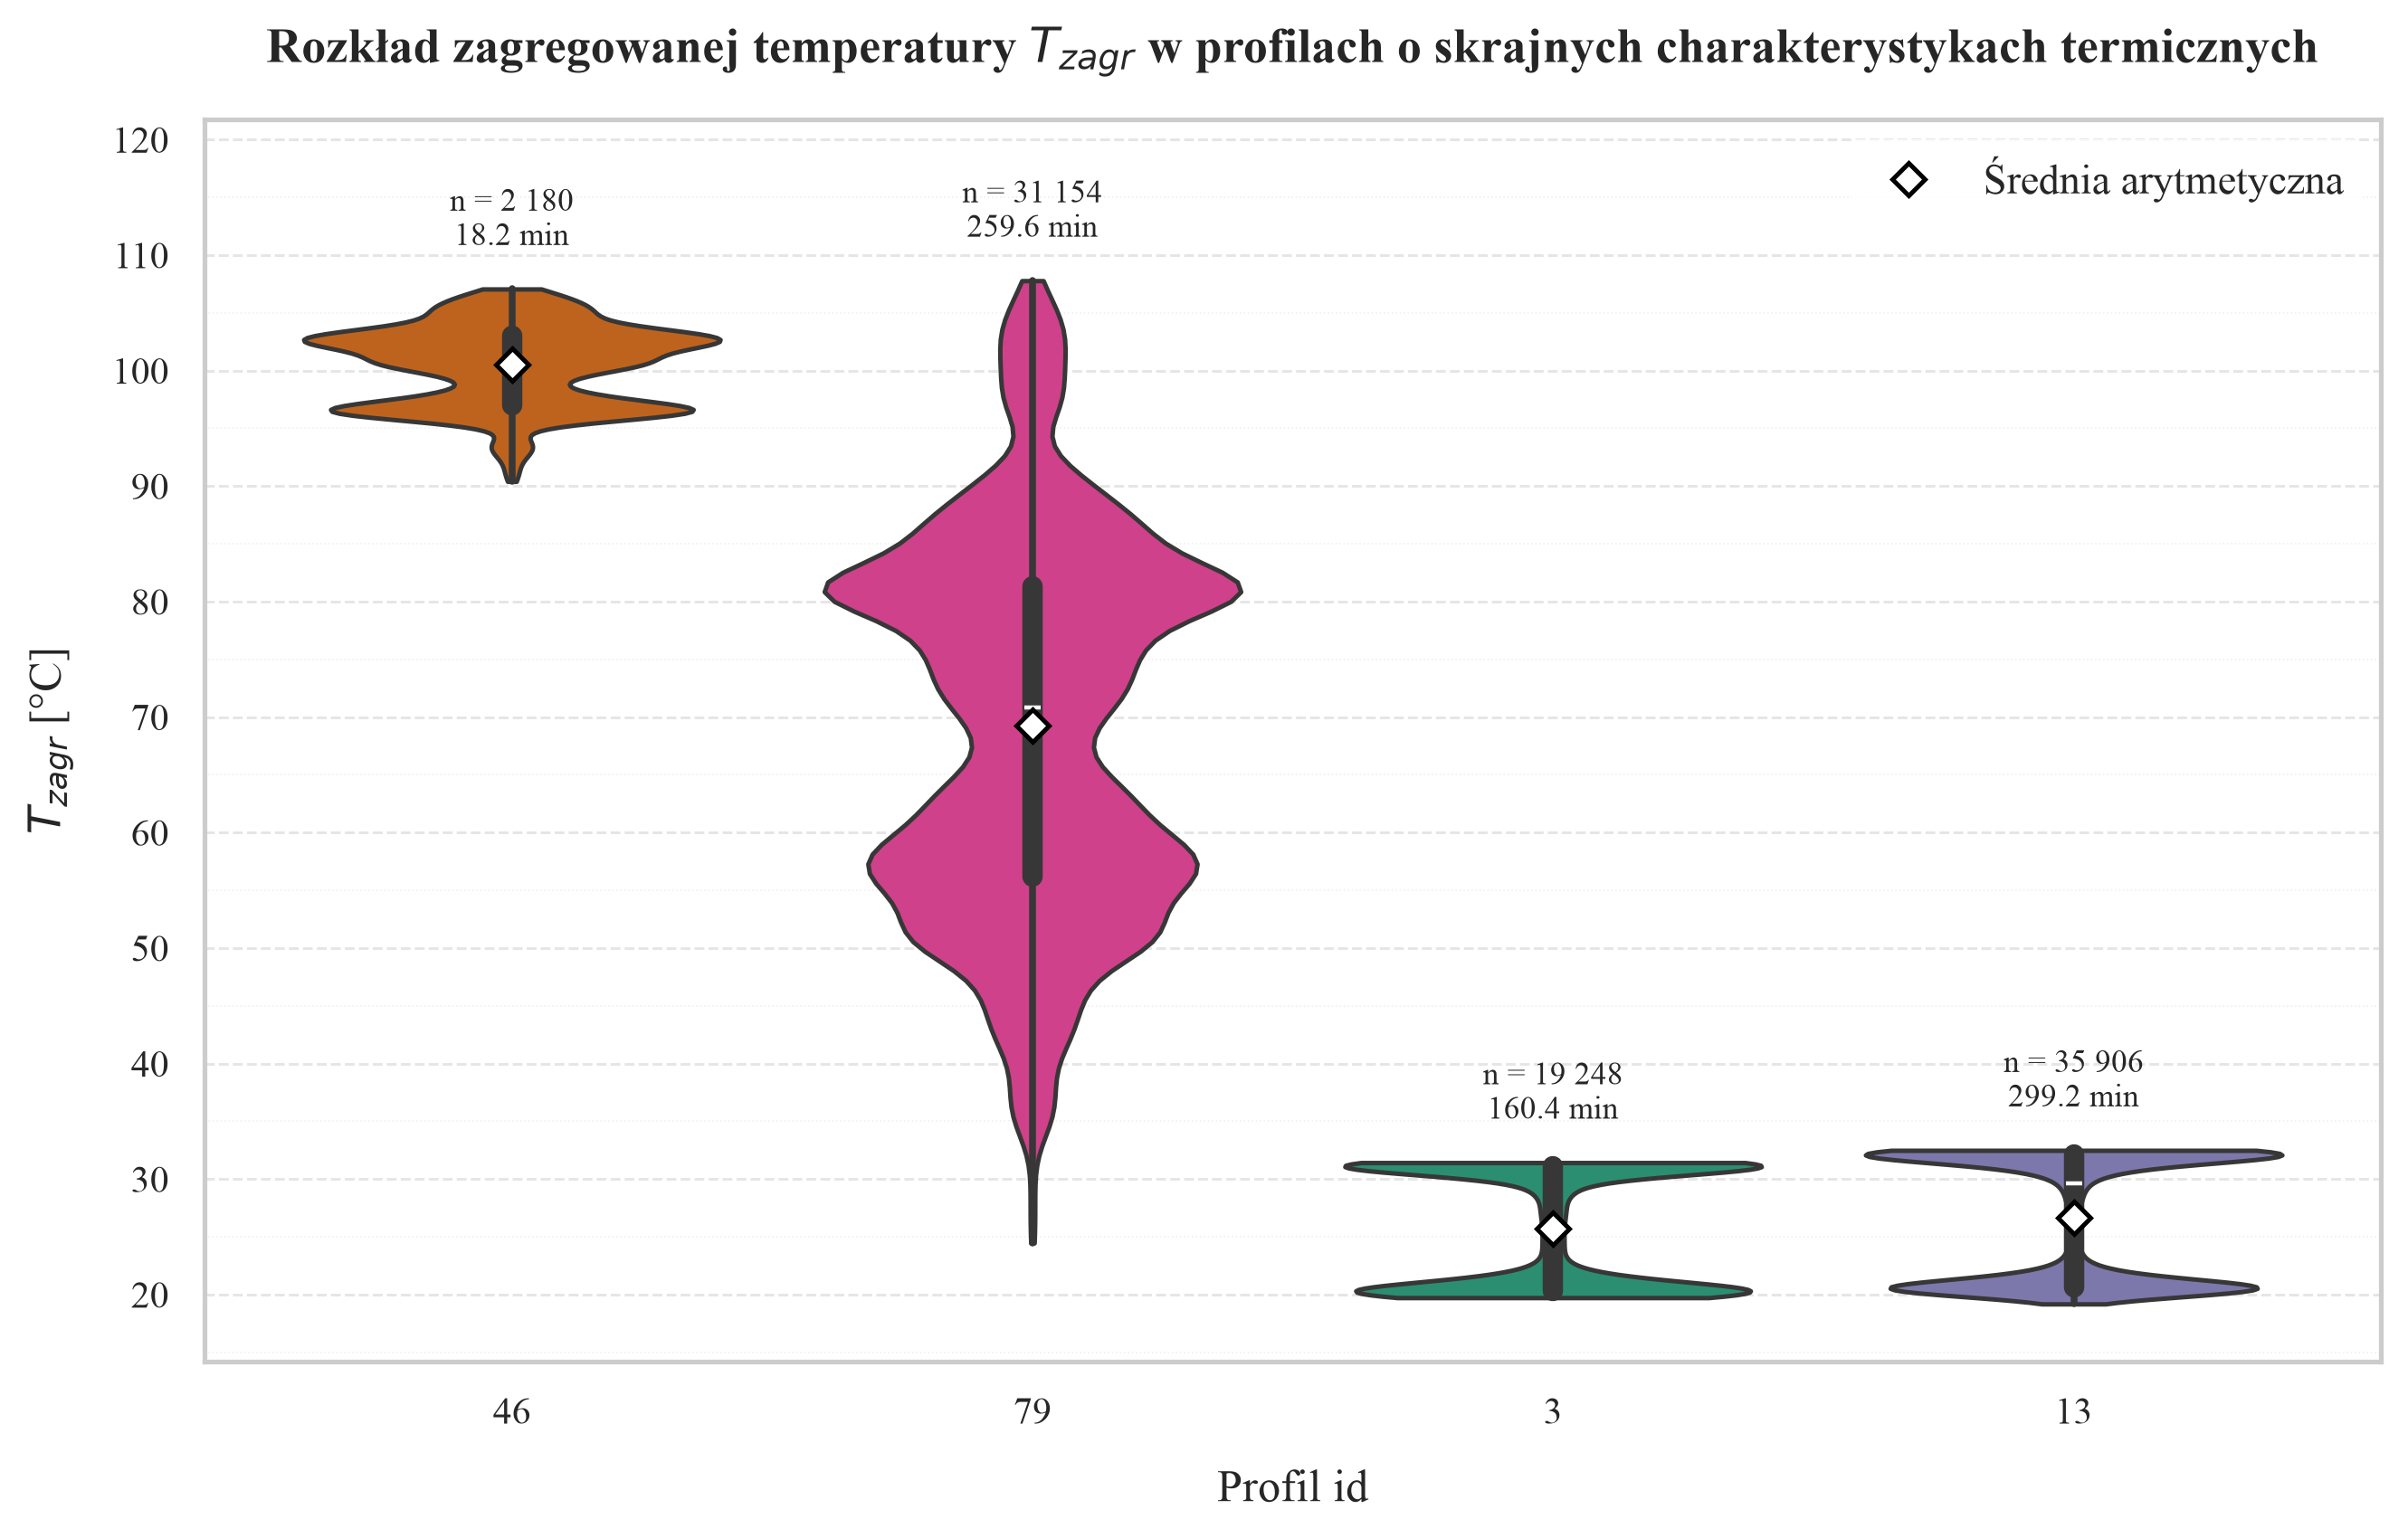

In [29]:
from matplotlib.ticker import MultipleLocator


# ============================================================
# 1. KONFIGURACJA STYLU AKADEMICKIEGO
# ============================================================

sns.set_theme(style="whitegrid")



plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


# ============================================================
# 2. WYBRANE PROFILE — STAŁA KOLEJNOŚĆ
# ============================================================

selected_profiles = [46, 79, 3, 13]


# ============================================================
# 3. PALETA KOLORÓW
# ============================================================

palette = {
    "46": "#d95f02",   # najwyższa średnia
    "79": "#e7298a",   # najwyższe maksimum
    "3":  "#1b9e77",   # najniższa średnia
    "13": "#7570b3",   # najniższe minimum
}


# ============================================================
# 4. PRZYGOTOWANIE DANYCH
# ============================================================

violin_frames = []

for pid in selected_profiles:

    profile_df = grouped.get_group(pid).copy()

    # Zagregowana temperatura dla każdej próbki:
    # średnia z wszystkich kanałów termicznych
    profile_df["aggregated_temperature"] = (
        profile_df[TEMPERATURE_FEATURES]
        .mean(axis=1)
    )

    violin_frames.append(
        profile_df[
            [ID_COL, "aggregated_temperature"]
        ]
    )


df_sub = pd.concat(
    violin_frames,
    ignore_index=True
)

# Seaborn ma traktować profile jako kategorie,
# a nie ciągłą zmienną liczbową
df_sub[ID_COL] = df_sub[ID_COL].astype(str)

order_labels = [str(pid) for pid in selected_profiles]


# ============================================================
# 5. GENEROWANIE WYKRESU
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.8),
    dpi=300
)

sns.violinplot(
    data=df_sub,
    x=ID_COL,
    y="aggregated_temperature",

    # hue = profile_id pozwala przypisać indywidualne kolory
    hue=ID_COL,

    order=order_labels,
    hue_order=order_labels,
    palette=palette,

    cut=0,          # KDE nie wychodzi poza zakres danych
    inner="box",    # IQR + mediana
    linewidth=1.2,
    density_norm="width",

    legend=False,
    ax=ax,
)


# ============================================================
# 6. ŚREDNIA ARYTMETYCZNA
# ============================================================

means = (
    df_sub
    .groupby(ID_COL)["aggregated_temperature"]
    .mean()
    .reindex(order_labels)
)

for idx, mean_val in enumerate(means):

    ax.plot(
        idx,
        mean_val,
        marker="D",
        markersize=6,
        color="white",
        markeredgecolor="black",
        markeredgewidth=1.2,
        linestyle="None",
        zorder=6,
    )


# ============================================================
# 7. LICZBA PRÓBEK I CZAS TRWANIA PROFILU
# ============================================================

for idx, pid in enumerate(selected_profiles):

    info = profile_summary.loc[
        profile_summary[ID_COL] == pid
    ].iloc[0]

    profile_max = df_sub.loc[
        df_sub[ID_COL] == str(pid),
        "aggregated_temperature"
    ].max()

    annotation = (
        f'n = {int(info["samples"]):,}\n'
        f'{info["duration_min"]:.1f} min'
    ).replace(",", " ")

    ax.text(
        idx,
        profile_max + 3,
        annotation,
        ha="center",
        va="bottom",
        fontsize=8.5,
    )


# ============================================================
# 8. TYTUŁ I OPIS OSI
# ============================================================

ax.set_title(
    "Rozkład zagregowanej temperatury $T_{zagr}$ "
    "w profilach o skrajnych charakterystykach termicznych",
    pad=15,
    fontweight="bold",
)

ax.set_xlabel(
    "Profil id",
    labelpad=10
)

ax.set_ylabel(
    "$T_{zagr}$ [°C]",
    labelpad=10
)


# ============================================================
# 9. GĘSTSZA OŚ Y
# ============================================================

# główne oznaczenia co 10°C
ax.yaxis.set_major_locator(
    MultipleLocator(10)
)

# pomocnicze co 5°C
ax.yaxis.set_minor_locator(
    MultipleLocator(5)
)


# ============================================================
# 10. SIATKA
# ============================================================

ax.grid(
    True,
    axis="y",
    which="major",
    linestyle="--",
    linewidth=0.7,
    alpha=0.50
)

ax.grid(
    True,
    axis="y",
    which="minor",
    linestyle=":",
    linewidth=0.4,
    alpha=0.30
)

ax.grid(
    False,
    axis="x"
)


# ============================================================
# 11. LEGENDA — ŚREDNIA
# ============================================================

ax.plot(
    [],
    [],
    marker="D",
    markersize=6,
    color="white",
    markeredgecolor="black",
    markeredgewidth=1.2,
    linestyle="None",
    label="Średnia arytmetyczna",
)

ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="none"
)


# ============================================================
# 12. MIEJSCE NA ADNOTACJE NAD WYKRESAMI
# ============================================================

y_min = df_sub["aggregated_temperature"].min()
y_max = df_sub["aggregated_temperature"].max()

ax.set_ylim(
    y_min - 5,
    y_max + 14
)


# ============================================================
# 13. FINALIZACJA I ZAPIS
# ============================================================

plt.tight_layout()

plt.savefig(
    "output_violin_temperature_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

# Jeżeli korzystasz z własnej funkcji:
# save_figure(
#     fig,
#     "temperature_violin_extreme_profiles"
# )

plt.show()

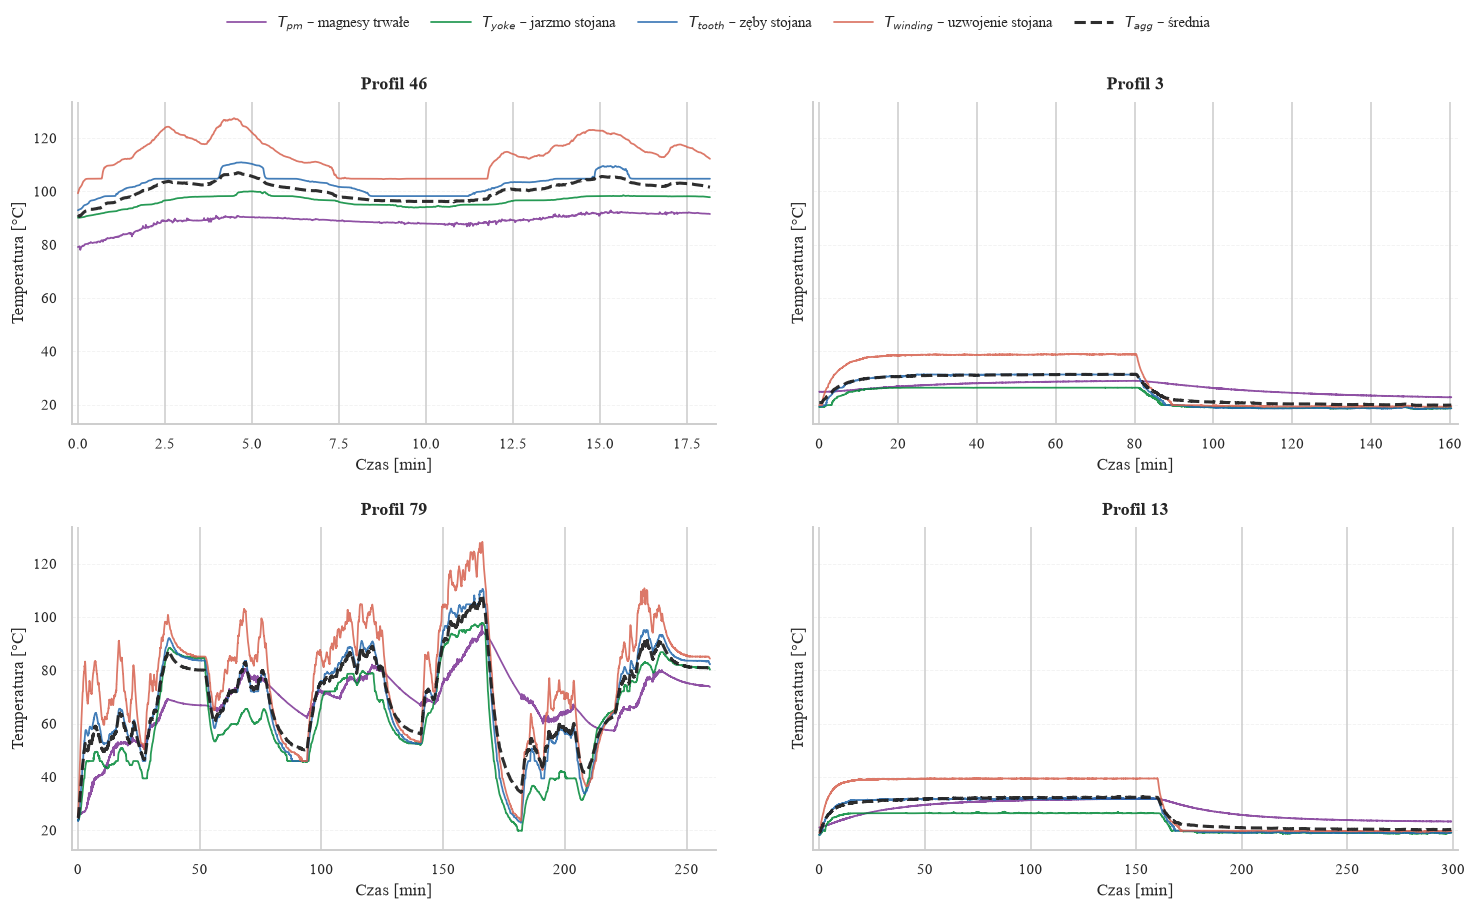

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# KONFIGURACJA
# ============================================================

selected_profiles = [46, 3, 79, 13]

temp_cols = [
    "pm",
    "stator_yoke",
    "stator_tooth",
    "stator_winding"
]

temp_labels = {
    "pm": r"$T_{pm}$ – magnesy trwałe",
    "stator_yoke": r"$T_{yoke}$ – jarzmo stojana",
    "stator_tooth": r"$T_{tooth}$ – zęby stojana",
    "stator_winding": r"$T_{winding}$ – uzwojenie stojana",
}

# Stonowana, kontrastowa paleta odpowiednia do publikacji
colors = {
    "pm": "#7B3294",
    "stator_yoke": "#008837",
    "stator_tooth": "#2166AC",
    "stator_winding": "#D6604D",
    "aggregated": "#222222",
}

# Styl akademicki
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# ============================================================
# WYKRES
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 8.5),
    sharey=True
)

axes = axes.ravel()


for ax, profile_id in zip(axes, selected_profiles):

    # --------------------------------------------------------
    # Dane profilu
    # --------------------------------------------------------

    profile = (
        work_df[work_df[ID_COL] == profile_id]
        .sort_values("_row_in_profile")
        .copy()
    )

    profile["t_minutes"] = profile["_time_seconds"] / 60.0

    # Średnia temperatura czterech komponentów
    profile["temp_aggregated"] = (
        profile[temp_cols].mean(axis=1)
    )


    # --------------------------------------------------------
    # Cztery sygnały temperatury
    # --------------------------------------------------------

    for col in temp_cols:

        ax.plot(
            profile["t_minutes"],
            profile[col],
            color=colors[col],
            linewidth=1.15,
            alpha=0.85,
            label=temp_labels[col]
        )


    # --------------------------------------------------------
    # Temperatura zagregowana
    # --------------------------------------------------------

    ax.plot(
        profile["t_minutes"],
        profile["temp_aggregated"],
        color=colors["aggregated"],
        linewidth=2.0,
        linestyle="--",
        alpha=0.95,
        label=r"$T_{agg}$ – średnia"
    )


    # --------------------------------------------------------
    # Formatowanie panelu
    # --------------------------------------------------------

    ax.set_title(
        f"Profil {profile_id}",
        fontweight="bold",
        pad=8
    )

    ax.set_xlabel("Czas [min]")
    ax.set_ylabel("Temperatura [°C]")

    # Delikatna siatka tylko pozioma
    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.25
    )

    # Mały margines na osi X
    ax.margins(x=0.01)


# ============================================================
# WSPÓLNA LEGENDA
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=5,
    frameon=False,
    handlelength=2.7,
    columnspacing=1.5
)


# ============================================================
# UKŁAD
# ============================================================

fig.subplots_adjust(
    top=0.89,
    bottom=0.09,
    left=0.08,
    right=0.98,
    hspace=0.32,
    wspace=0.15
)

save_figure(
    fig,
    "temperature_profiles_46_3_79_13"
)

plt.show()

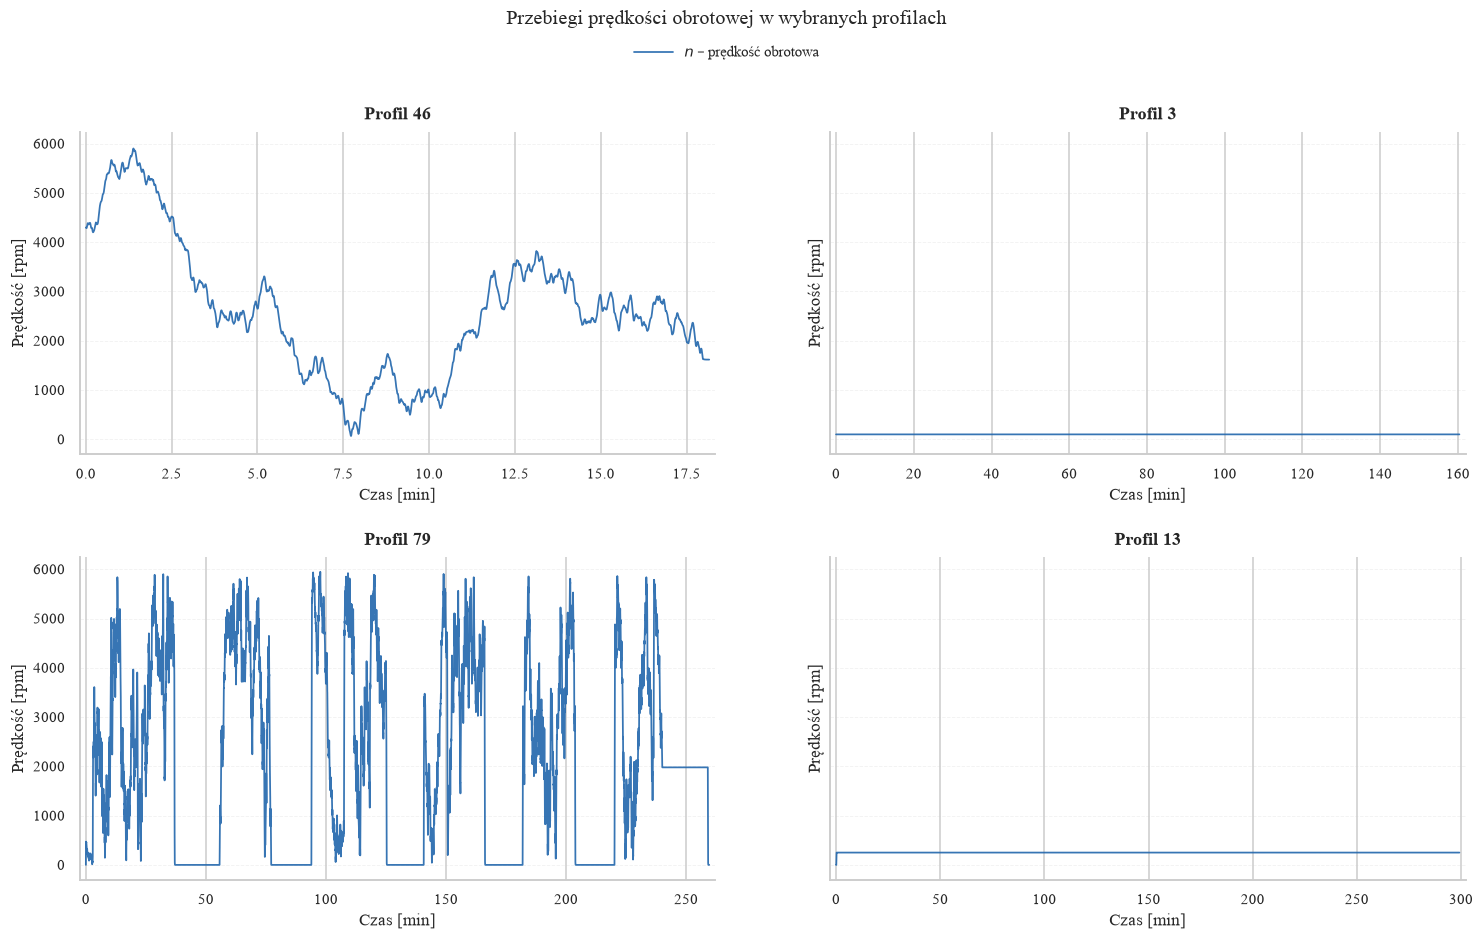

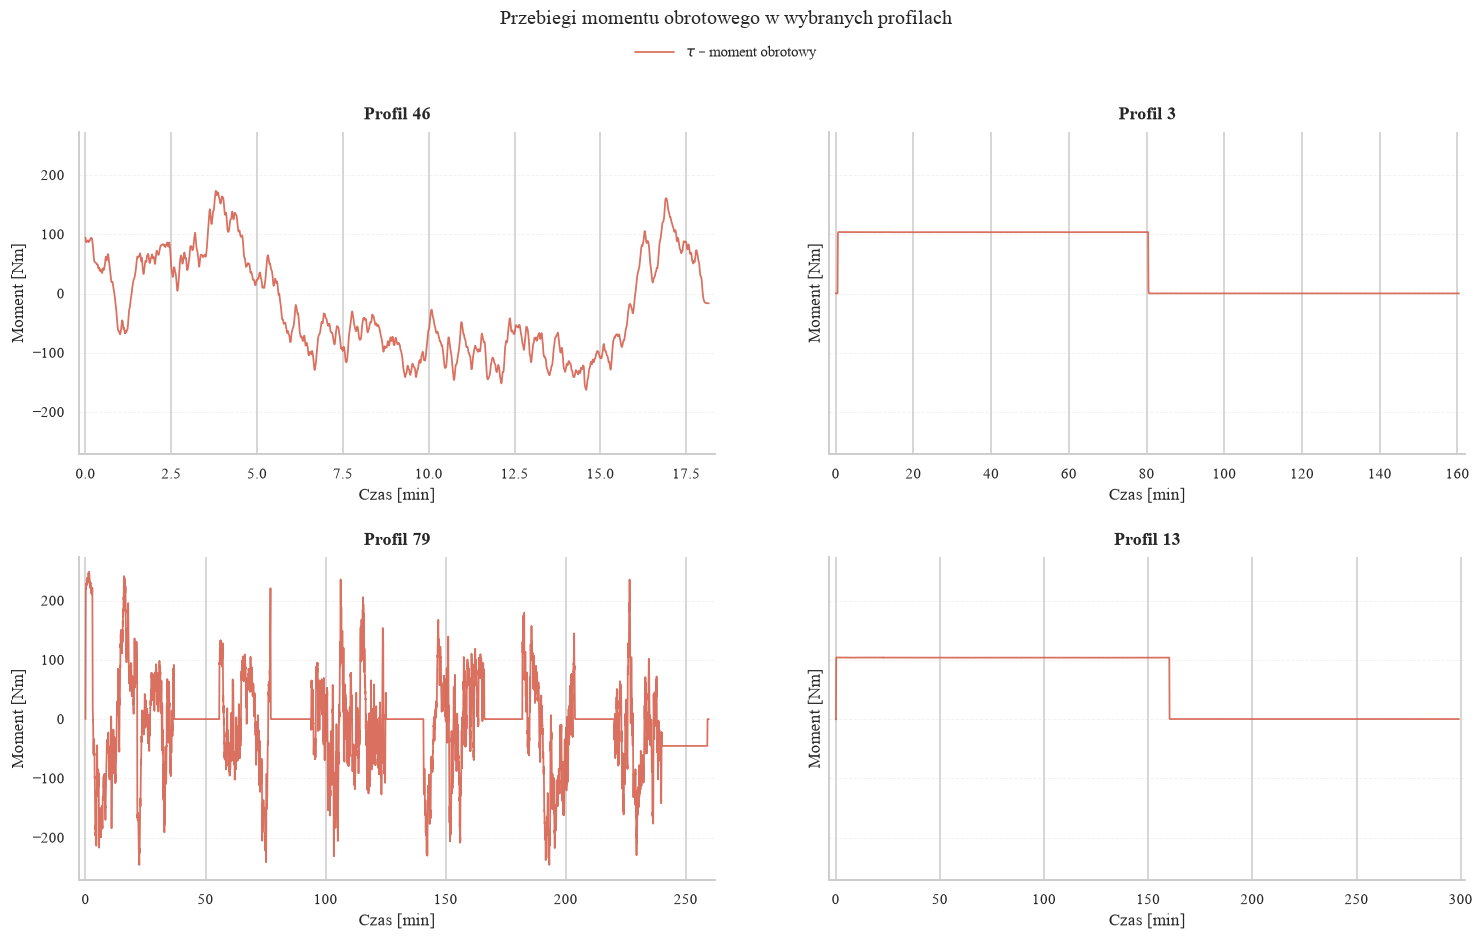

In [65]:
operational_series = [
    {
        "column": "motor_speed",
        "label": r"$n$ – prędkość obrotowa",
        "ylabel": "Prędkość [rpm]",
        "color": "#2166AC",
        "filename": "operational_speed_profiles_46_3_79_13",
        "title": "Przebiegi prędkości obrotowej w wybranych profilach",
    },
    {
        "column": "torque",
        "label": r"$\tau$ – moment obrotowy",
        "ylabel": "Moment [Nm]",
        "color": "#D6604D",
        "filename": "operational_torque_profiles_46_3_79_13",
        "title": "Przebiegi momentu obrotowego w wybranych profilach",
    },
]

for spec in operational_series:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8.5), sharey=True)
    axes = axes.ravel()

    for ax, profile_id in zip(axes, selected_profiles):
        profile = (
            work_df[work_df[ID_COL] == profile_id]
            .sort_values("_row_in_profile")
            .copy()
        )
        profile["t_minutes"] = profile["_time_seconds"] / 60.0

        ax.plot(
            profile["t_minutes"],
            profile[spec["column"]],
            color=spec["color"],
            linewidth=1.15,
            alpha=0.9,
            label=spec["label"],
        )

        ax.set_title(f"Profil {profile_id}", fontweight="bold", pad=8)
        ax.set_xlabel("Czas [min]")
        ax.set_ylabel(spec["ylabel"])
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.25)
        ax.margins(x=0.01)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.995),
        ncol=1,
        frameon=False,
        handlelength=2.7,
    )
    fig.suptitle(spec["title"], fontsize=13, y=1.02)
    fig.subplots_adjust(
        top=0.89,
        bottom=0.09,
        left=0.08,
        right=0.98,
        hspace=0.32,
        wspace=0.18,
    )
    save_figure(fig, spec["filename"])
    plt.show()

## 5.2 Rozkład długości i czasu trwania profili

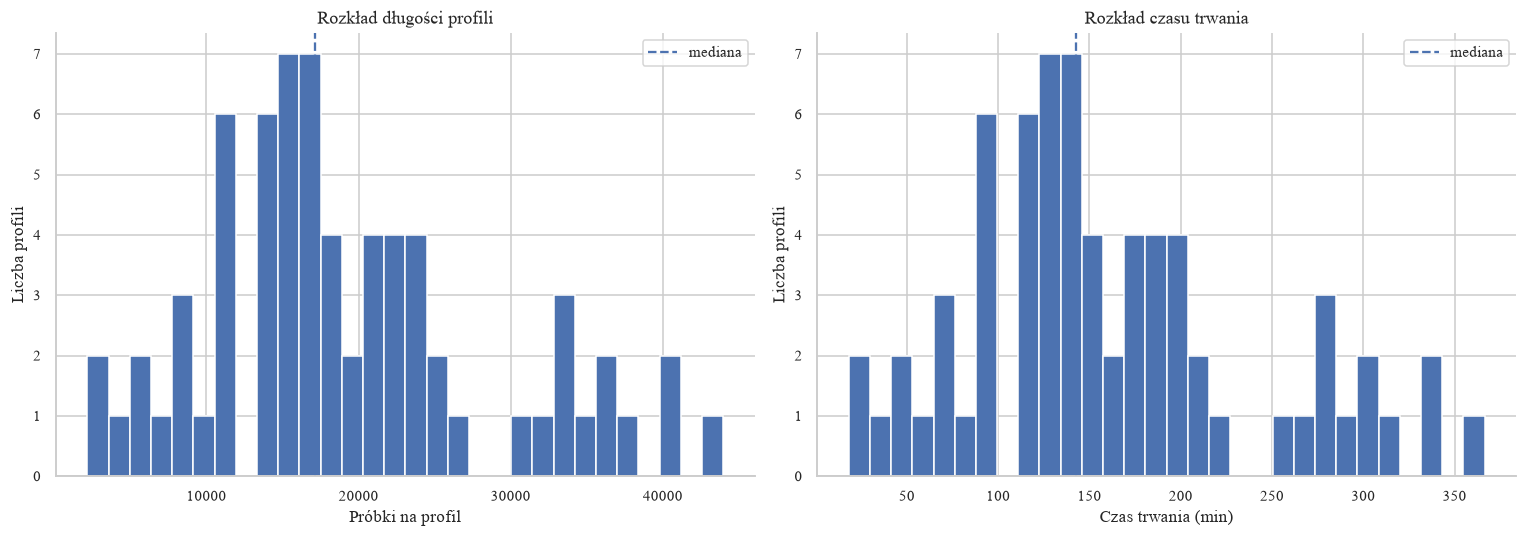

count      69.0000
mean    19287.1884
std      9606.7298
min      2176.0000
25%     14403.0000
50%     17142.0000
75%     23761.0000
max     43971.0000
Skośność długości: 0.646
Stosunek najdłuższy/najkrótszy: 20.2x


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(profile_summary["samples"], bins=min(30, n_profiles))
axes[0].axvline(profile_summary["samples"].median(), ls="--", label="mediana")
axes[0].set(xlabel="Próbki na profil", ylabel="Liczba profili", title="Rozkład długości profili")
axes[0].legend()

axes[1].hist(profile_summary["duration_min"], bins=min(30, n_profiles))
axes[1].axvline(profile_summary["duration_min"].median(), ls="--", label="mediana")
axes[1].set(xlabel="Czas trwania (min)", ylabel="Liczba profili", title="Rozkład czasu trwania")
axes[1].legend()

fig.tight_layout()
save_figure(fig, "05_profile_length_duration_hist")
plt.show()

length_stats = profile_summary["samples"].describe()
print(length_stats.to_string())
print(f"Skośność długości: {profile_summary['samples'].skew():.3f}")
print(f"Stosunek najdłuższy/najkrótszy: {profile_summary['samples'].max() / profile_summary['samples'].min():.1f}x")

/var/folders/nf/j0vc12bd6kvblbd7by89d73r0000gn/T/ipykernel_79362/312650570.py:84: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


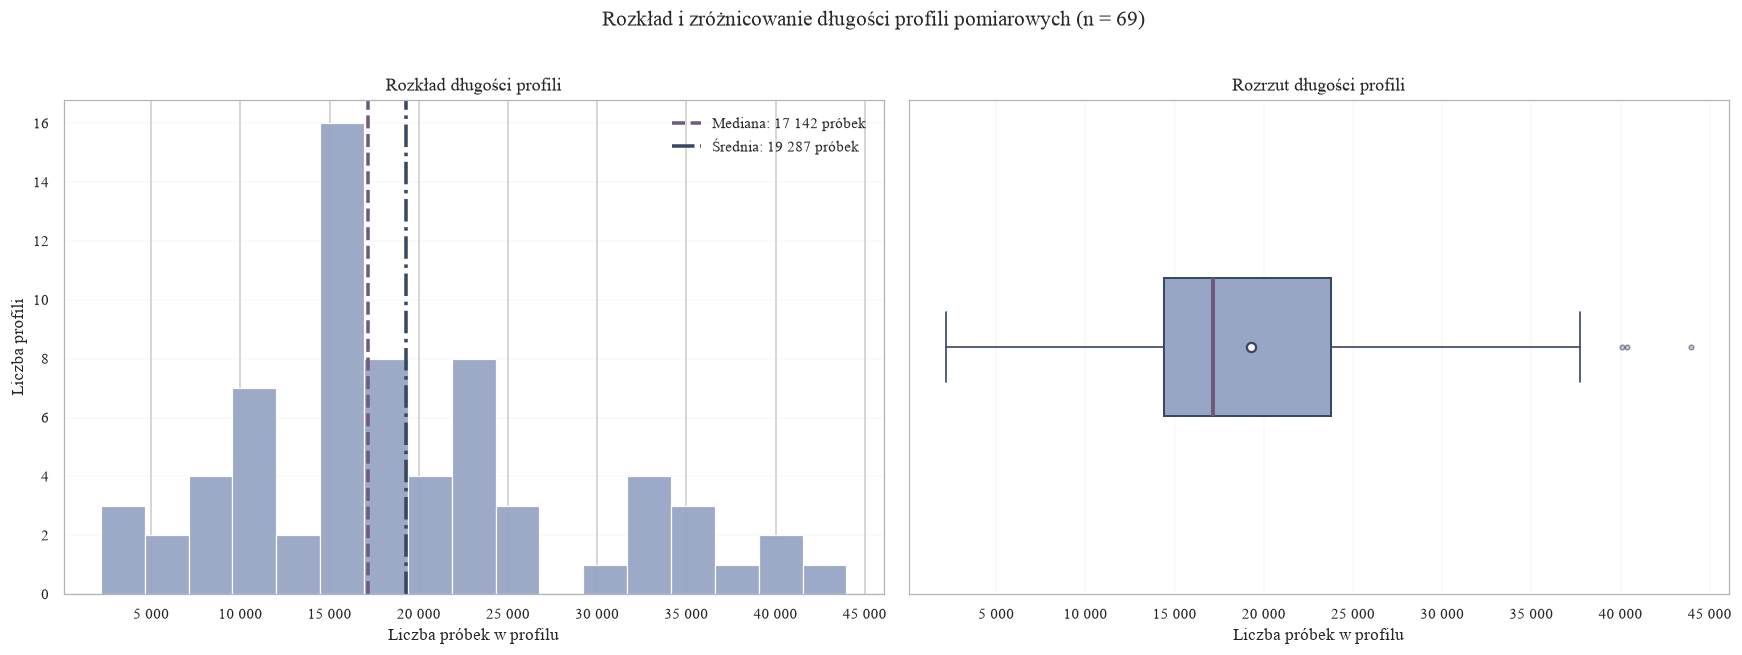

count      69.0000
mean    19287.1884
std      9606.7298
min      2176.0000
25%     14403.0000
50%     17142.0000
75%     23761.0000
max     43971.0000

Skośność długości: 0.646
Stosunek najdłuższego do najkrótszego profilu: 20.2×
Mediana czasu trwania: 142.8 min
Średni czas trwania: 160.7 min
Najkrótszy profil: 18.1 min
Najdłuższy profil: 366.4 min


In [32]:
from matplotlib.ticker import MaxNLocator, MultipleLocator, FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))

samples = profile_summary["samples"]
median_val = samples.median()
mean_val = samples.mean()

LIGHT_BLUE = "#97A6C4"
DARK_BLUE = "#384860"
ACCENT = "#6F5A7E"
BORDER = "#AEB4BC"


# ------------------------------------------------------------
# Format liczb: separator tysięcy jako spacja
# ------------------------------------------------------------

def format_thousands(x, pos=None):
    return f"{int(x):,}".replace(",", " ")


# ------------------------------------------------------------
# 1. Histogram długości profili
# ------------------------------------------------------------

axes[0].hist(
    samples,
    bins=17,
    color=LIGHT_BLUE,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.95
)

axes[0].axvline(
    median_val,
    color=ACCENT,
    linestyle="--",
    linewidth=2.3,
    label=f"Mediana: {median_val:,.0f} próbek".replace(",", " ")
)

axes[0].axvline(
    mean_val,
    color=DARK_BLUE,
    linestyle="-.",
    linewidth=2.3,
    label=f"Średnia: {mean_val:,.0f} próbek".replace(",", " ")
)

axes[0].set(
    xlabel="Liczba próbek w profilu",
    ylabel="Liczba profili",
    title="Rozkład długości profili"
)

# pełne wartości na osi Y
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))

# zagęszczenie osi X
axes[0].xaxis.set_major_locator(MultipleLocator(5000))
axes[0].xaxis.set_major_formatter(FuncFormatter(format_thousands))

axes[0].legend(
    frameon=False,
    loc="upper right",
    borderaxespad=0.8
)

axes[0].grid(axis="y", alpha=0.12)

# obramowanie
for spine in axes[0].spines.values():
    spine.set_visible(True)
    spine.set_color(BORDER)
    spine.set_linewidth(0.8)


# ------------------------------------------------------------
# 2. Wykres pudełkowy
# ------------------------------------------------------------

axes[1].boxplot(
    samples,
    vert=False,
    patch_artist=True,
    showmeans=True,
    widths=0.28,

    boxprops=dict(
        facecolor=LIGHT_BLUE,
        edgecolor=DARK_BLUE,
        linewidth=1.3
    ),

    medianprops=dict(
        color=ACCENT,
        linewidth=2.6
    ),

    meanprops=dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor=DARK_BLUE,
        markeredgewidth=1.5,
        markersize=6
    ),

    whiskerprops=dict(
        color=DARK_BLUE,
        linewidth=1.1
    ),

    capprops=dict(
        color=DARK_BLUE,
        linewidth=1.1
    ),

    flierprops=dict(
        marker="o",
        markersize=3,
        markerfacecolor=LIGHT_BLUE,
        markeredgecolor=DARK_BLUE,
        alpha=0.55
    )
)

axes[1].set(
    xlabel="Liczba próbek w profilu",
    title="Rozrzut długości profili"
)

# brak zbędnej osi Y dla pojedynczego boxplotu
axes[1].set_yticks([])

# zagęszczenie osi X
axes[1].xaxis.set_major_locator(MultipleLocator(5000))
axes[1].xaxis.set_major_formatter(FuncFormatter(format_thousands))

axes[1].grid(axis="x", alpha=0.12)

# obramowanie
for spine in axes[1].spines.values():
    spine.set_visible(True)
    spine.set_color(BORDER)
    spine.set_linewidth(0.8)


# ------------------------------------------------------------
# Cała figura
# ------------------------------------------------------------

fig.suptitle(
    f"Rozkład i zróżnicowanie długości profili pomiarowych (n = {n_profiles})",
    fontsize=14,
    y=1.02
)

fig.tight_layout()

save_figure(fig, "05_profile_length_distribution")
plt.show()


# ------------------------------------------------------------
# Statystyki opisowe
# ------------------------------------------------------------

print(samples.describe().to_string())

print(f"\nSkośność długości: {samples.skew():.3f}")

print(
    f"Stosunek najdłuższego do najkrótszego profilu: "
    f"{samples.max() / samples.min():.1f}×"
)

# 2 Hz = 120 próbek/min
print(f"Mediana czasu trwania: {median_val / 120:.1f} min")
print(f"Średni czas trwania: {mean_val / 120:.1f} min")
print(f"Najkrótszy profil: {samples.min() / 120:.1f} min")
print(f"Najdłuższy profil: {samples.max() / 120:.1f} min")

## 5.3 Jak bardzo różnią się profile? Odcisk punktu pracy

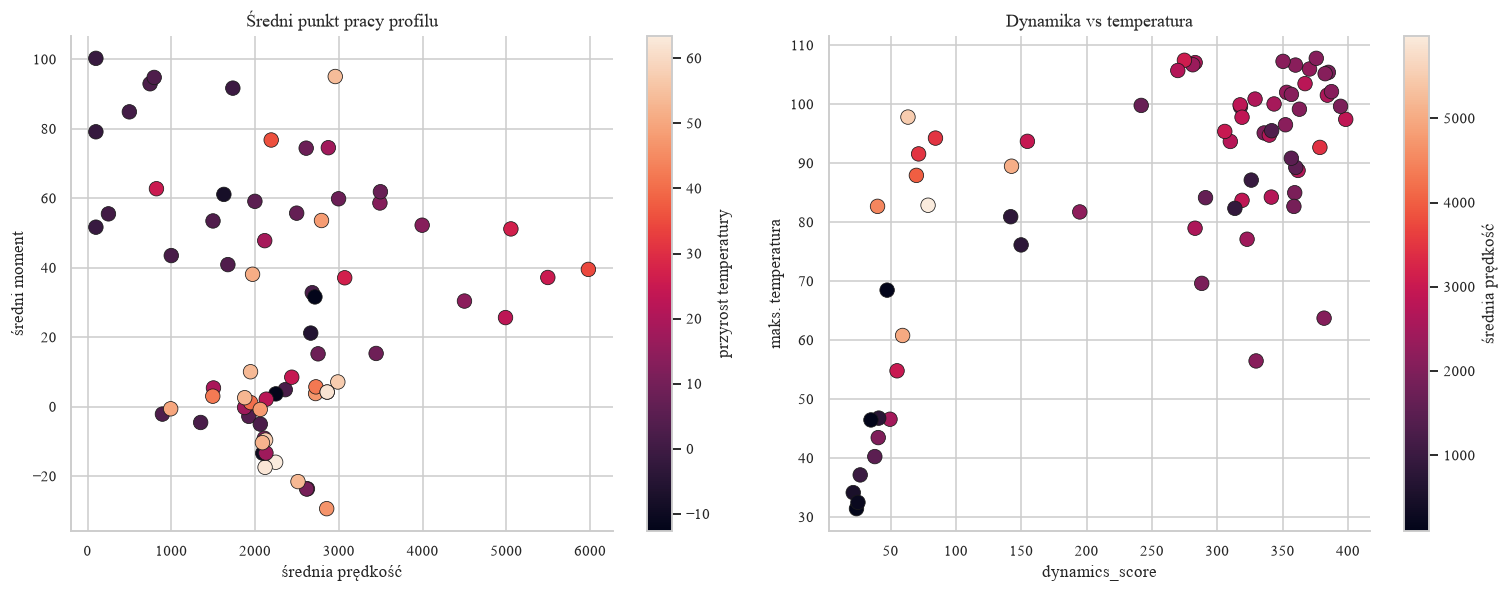

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sc = axes[0].scatter(
    profile_summary["avg_speed"],
    profile_summary["avg_torque"],
    c=profile_summary["temperature_increase"],
    s=90,
    edgecolor="k",
    linewidth=0.5,
)
axes[0].set(xlabel="średnia prędkość", ylabel="średni moment", title="Średni punkt pracy profilu")
fig.colorbar(sc, ax=axes[0], label="przyrost temperatury")

sc2 = axes[1].scatter(
    profile_summary["dynamics_score"],
    profile_summary["max_temperature"],
    c=profile_summary["avg_speed"],
    s=90,
    edgecolor="k",
    linewidth=0.5,
)
axes[1].set(xlabel="dynamics_score", ylabel="maks. temperatura", title="Dynamika vs temperatura")
fig.colorbar(sc2, ax=axes[1], label="średnia prędkość")

fig.tight_layout()
save_figure(fig, "05_profile_fingerprints")
plt.show()

> **Interpretacja.** Duże zróżnicowanie długości profili oznacza, że bezpośrednie porównywanie całych surowych przebiegów odległością euklidesową byłoby ryzykowne. Dalsza analiza powinna używać albo reprezentacji o stałej długości, albo segmentów.

# 6. Eksploracja cech — rozkłady jednowymiarowe

In [34]:
def descriptive_stats(frame: pd.DataFrame, cols: Sequence[str]) -> pd.DataFrame:
    records = []

    for col in cols:
        s = frame[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((s < lo) | (s > hi)).sum())

        records.append({
            "feature": col,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "q1": q1,
            "q3": q3,
            "max": s.max(),
            "iqr": iqr,
            "skewness": s.skew(),
            "kurtosis": s.kurtosis(),
            "n_outliers_iqr": n_out,
            "outlier_pct": 100.0 * n_out / max(len(s), 1),
            "range": s.max() - s.min(),
        })

    return pd.DataFrame(records)

feature_statistics = descriptive_stats(work_df, ALL_FEATURES)
export_table(feature_statistics, "feature_statistics.csv",
             "Statystyki opisowe wszystkich kanałów")

feature_statistics

23:57:58 | INFO    | Zapisano feature_statistics.csv         (12 wierszy) -> Statystyki opisowe wszystkich kanałów


,feature,mean,median,std,min,q1,q3,max,iqr,skewness,kurtosis,n_outliers_iqr,outlier_pct,range
0,u_q,54.2790,48.9382,44.1732,-25.2909,12.0699,90.0344,133.0370,77.9645,0.3149,-1.2431,0,0.0000,158.3279
1,u_d,-25.1338,-7.4298,63.0920,-131.5304,-78.6909,1.4703,131.4698,80.1612,0.1451,-0.2903,18872,1.4181,263.0002
2,i_q,37.4128,15.7740,92.1819,-293.4268,1.0959,100.6121,301.7079,99.5163,-0.1465,0.6775,65631,4.9316,595.1346
3,i_d,-68.7168,-51.0938,64.9332,-278.0036,-115.4061,-2.9797,0.0519,112.4264,-0.7073,-0.5653,0,0.0000,278.0555
4,motor_speed,2202.0807,1999.9767,1859.6634,-275.5491,317.1107,3760.6391,6000.0151,3443.5284,0.3865,-1.1478,0,0.0000,6275.5643
5,torque,31.1060,10.8604,77.1358,-246.4667,-0.1374,91.5972,261.0057,91.7346,-0.1271,0.6695,43461,3.2657,507.4724
6,coolant,36.2300,26.9001,21.7861,10.6238,18.6981,49.8575,101.5985,31.1594,1.0481,-0.0990,2,0.0002,90.9748
7,ambient,24.5653,24.7973,1.9295,8.7835,23.1848,26.2170,30.7142,3.0322,-0.3491,-0.1370,259,0.0195,21.9307
8,pm,58.5068,60.2663,19.0015,20.8570,43.1516,72.0084,113.6066,28.8568,0.0383,-0.7457,0,0.0000,92.7497
9,stator_yoke,48.1880,45.6255,19.9910,18.0767,31.9903,61.4608,101.1480,29.4705,0.4810,-0.6298,0,0.0000,83.0713


## 6.1 Histogramy i KDE

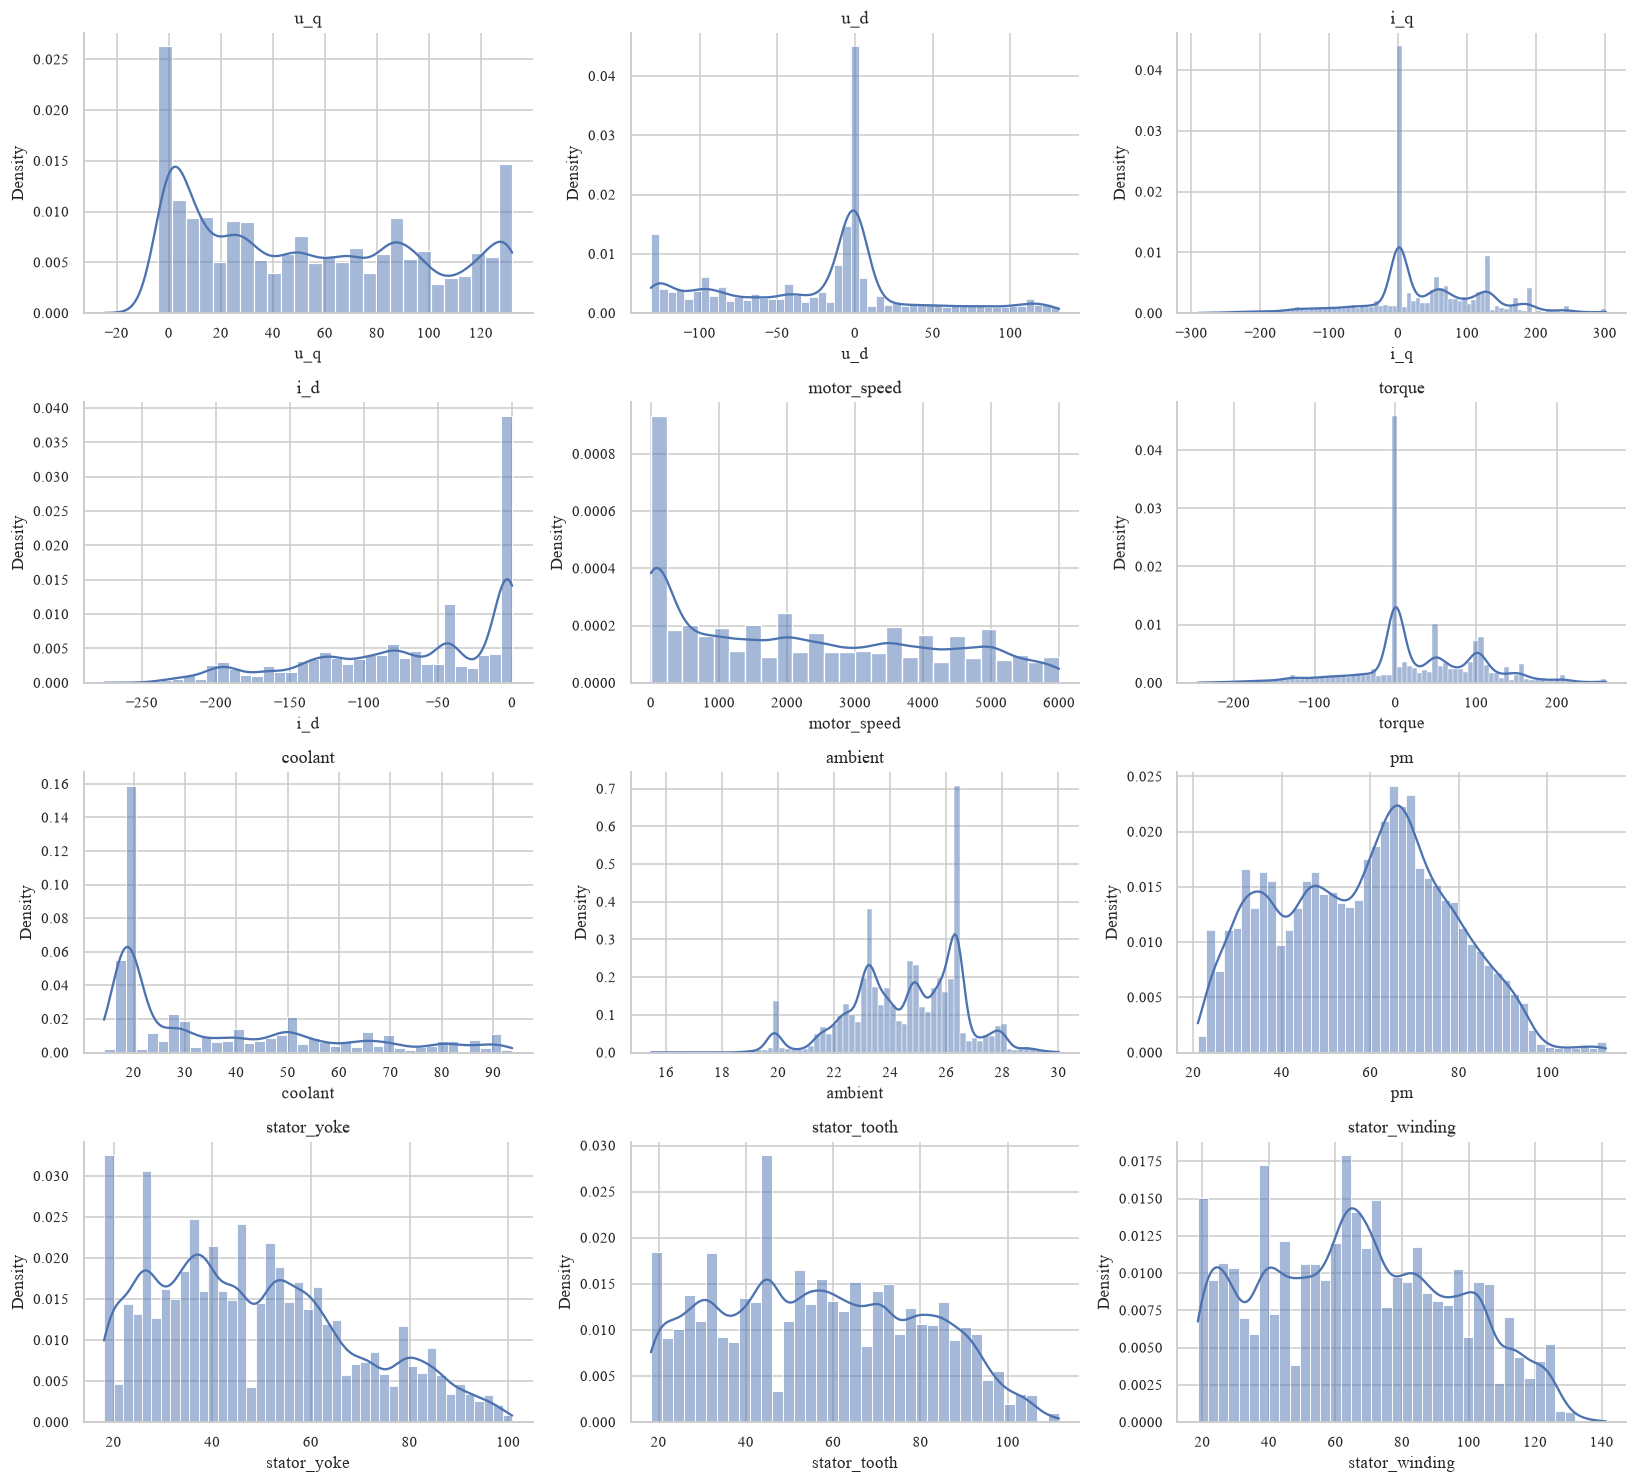

In [35]:
n = len(ALL_FEATURES)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, ALL_FEATURES):
    sample = subsample_rows(work_df[[col]], MAX_POINTS_FOR_SCATTER)[col].dropna()
    sns.histplot(sample, kde=True, ax=ax, stat="density")
    ax.set_title(col)

for ax in axes[n:]:
    ax.set_visible(False)

fig.tight_layout()
save_figure(fig, "06_histograms_kde")
plt.show()

## 6.3 Automatyczne flagi: skośność, ciężkie ogony, outliers, możliwa multimodalność

In [36]:
def flag_distribution(row: pd.Series) -> str:
    flags = []

    if abs(row["skewness"]) > 1.0:
        flags.append("strong skew")
    elif abs(row["skewness"]) > 0.5:
        flags.append("moderate skew")

    if row["kurtosis"] > 3.0:
        flags.append("heavy tails")
    elif row["kurtosis"] < -1.0:
        flags.append("flat / plateau")

    if row["outlier_pct"] > 5.0:
        flags.append("many IQR outliers")

    if row["kurtosis"] < -0.8:
        flags.append("possible multimodal")

    return ", ".join(flags) if flags else "approx. unimodal / symmetric"

dist_flags = feature_statistics[
    ["feature", "skewness", "kurtosis", "outlier_pct"]
].copy()

dist_flags["flags"] = feature_statistics.apply(flag_distribution, axis=1)
dist_flags

,feature,skewness,kurtosis,outlier_pct,flags
0,u_q,0.3149,-1.2431,0.0000,"flat / plateau, possible multimodal"
1,u_d,0.1451,-0.2903,1.4181,approx. unimodal / symmetric
2,i_q,-0.1465,0.6775,4.9316,approx. unimodal / symmetric
3,i_d,-0.7073,-0.5653,0.0000,moderate skew
4,motor_speed,0.3865,-1.1478,0.0000,"flat / plateau, possible multimodal"
5,torque,-0.1271,0.6695,3.2657,approx. unimodal / symmetric
6,coolant,1.0481,-0.0990,0.0002,strong skew
7,ambient,-0.3491,-0.1370,0.0195,approx. unimodal / symmetric
8,pm,0.0383,-0.7457,0.0000,approx. unimodal / symmetric
9,stator_yoke,0.4810,-0.6298,0.0000,approx. unimodal / symmetric


> **Interpretacja.** `motor_speed` i `torque` są szczególnie ważne pod kątem możliwej multimodalności, ponieważ cykle jazdy zatrzymują się w określonych punktach pracy. Kanały termiczne mogą być prawoskośne, ponieważ układ spędza dużo czasu blisko stanu chłodnego, a tylko część próbek pochodzi z wysokich temperatur.

# 7. Eksploracja szeregów czasowych

Wybrane profile reprezentatywne: [29, 20, 79, 7]


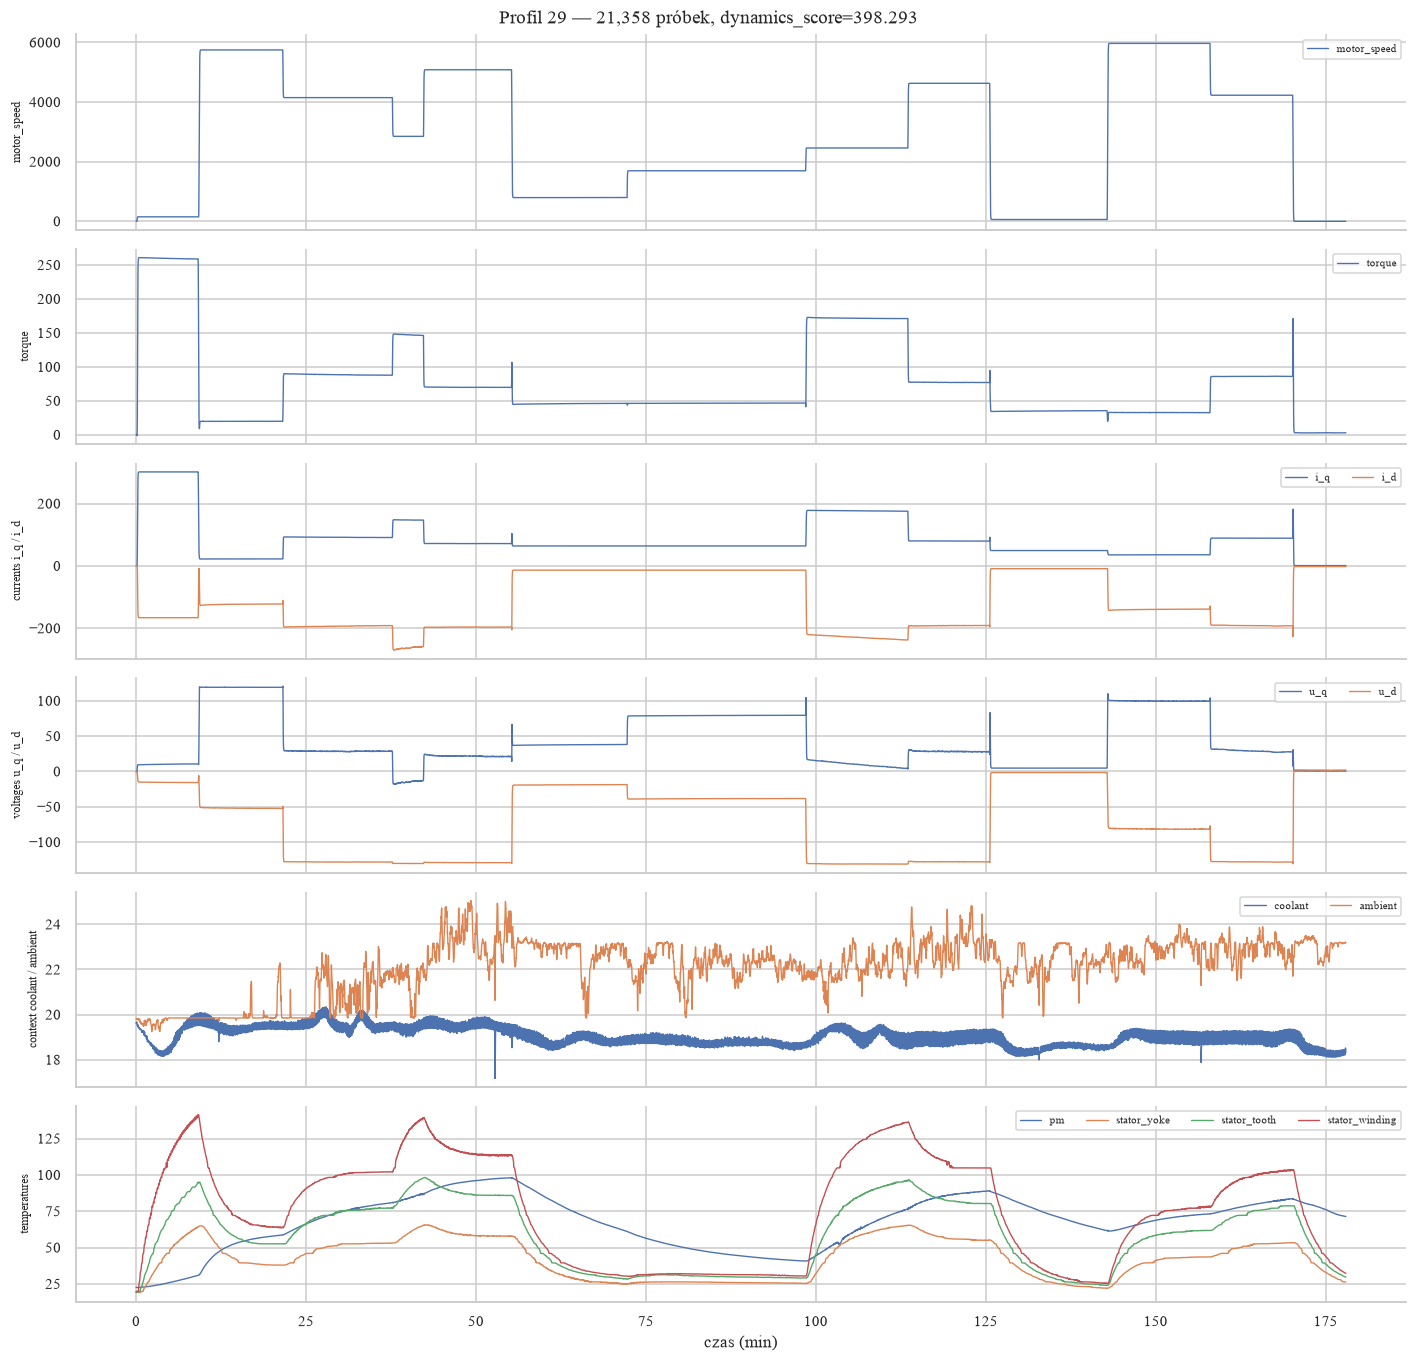

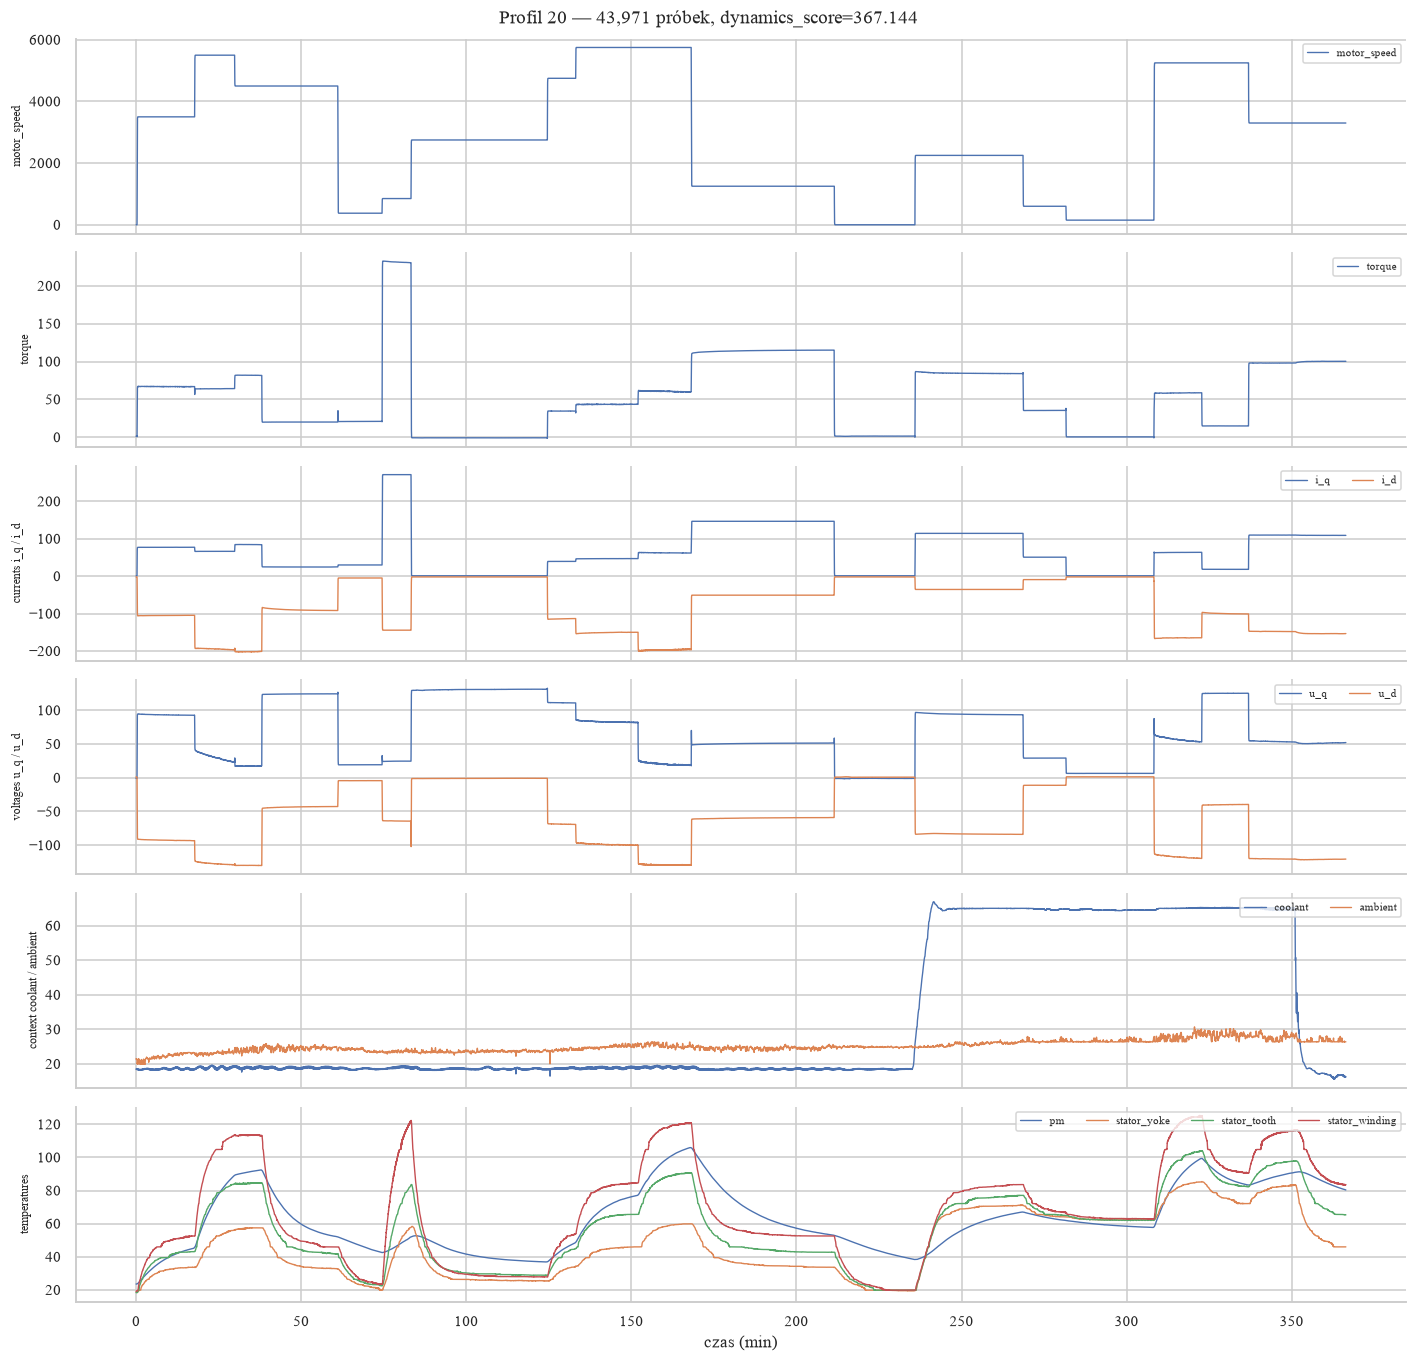

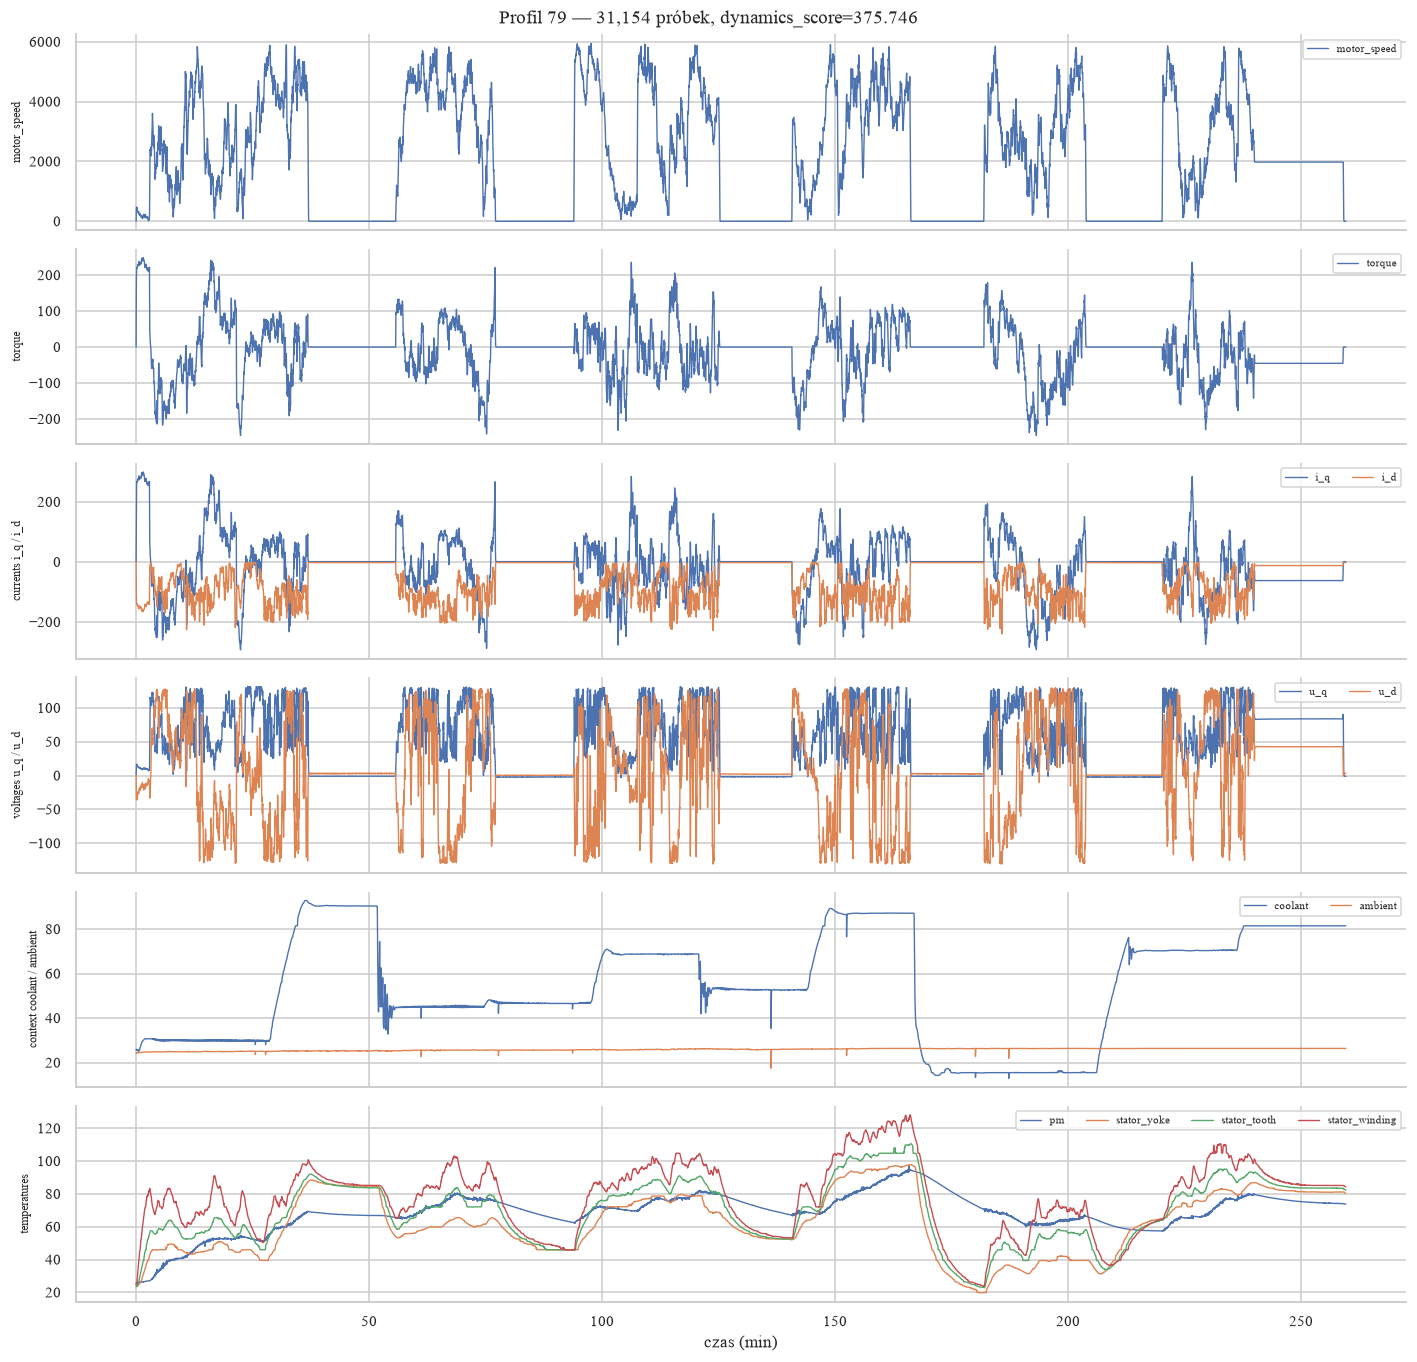

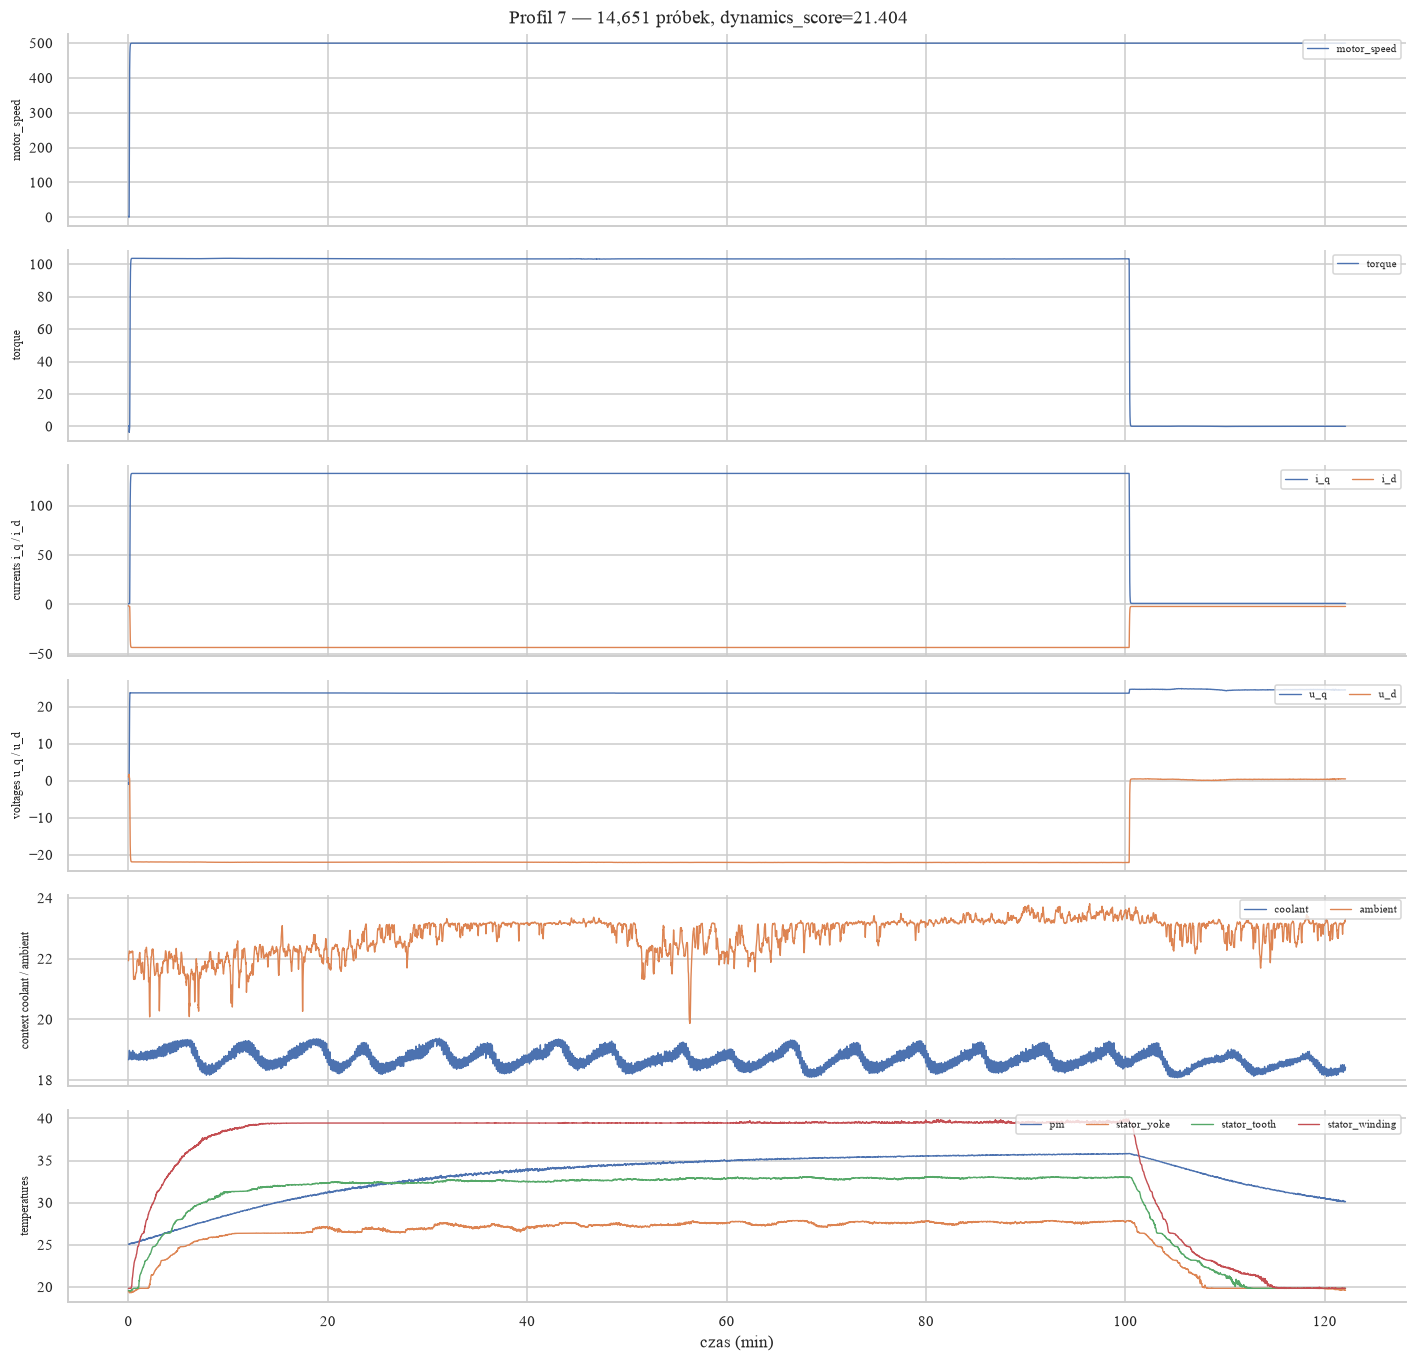

In [37]:
representative_profiles = list(dict.fromkeys([
    most_variable_profile,
    longest_profile,
    hottest_profile,
    least_variable_profile,
]))[:MAX_EXAMPLE_PROFILES_TO_PLOT]

print("Wybrane profile reprezentatywne:", representative_profiles)

def plot_profile_timeseries(pid: int) -> None:
    frame = grouped.get_group(pid).reset_index(drop=True)
    t_min = frame["_time_seconds"] / 60.0

    panels = [
        ("motor_speed", ["motor_speed"], "operational"),
        ("torque", ["torque"], "operational"),
        ("currents i_q / i_d", ["i_q", "i_d"], "electrical"),
        ("voltages u_q / u_d", ["u_q", "u_d"], "electrical"),
        ("context coolant / ambient", CONTEXT_FEATURES, "context"),
        ("temperatures", TEMPERATURE_FEATURES, "thermal"),
    ]

    fig, axes = plt.subplots(len(panels), 1, figsize=(13, 2.1 * len(panels)), sharex=True)

    for ax, (title, cols, _role) in zip(axes, panels):
        for c in cols:
            ax.plot(t_min, frame[c], lw=0.9, label=c)
        ax.set_ylabel(title, fontsize=8)
        ax.legend(loc="upper right", fontsize=7, ncol=len(cols))

    axes[-1].set_xlabel("czas (min)")
    dyn = float(profile_summary.loc[profile_summary[ID_COL] == pid, "dynamics_score"].iloc[0])
    fig.suptitle(f"Profil {pid} — {len(frame):,} próbek, dynamics_score={dyn:.3f}")
    fig.tight_layout()
    save_figure(fig, f"07_timeseries_profile_{pid}")
    plt.show()

for pid in representative_profiles:
    plot_profile_timeseries(pid)

## 7.1 Automatyczne wykrywanie zdarzeń wewnątrz profilu

In [38]:
# NAIWNY BASELINE (do zastąpienia). Ta funkcja używa STAŁEGO progu 0.5*std(dspeed) na
# wygładzonej prędkości. Taki próg globalny sztucznie ZAWYŻA udział stanu „stable operation"
# (np. 98.6% dla profilu 29), ponieważ nie ma histerezy ani odniesienia do zakresu prędkości —
# drobne fluktuacje wokół zera nie przekraczają progu i cały odcinek zostaje uznany za stabilny.
# Rzetelną detekcję transientów przeprowadzono w rozdz. 22.3 (próg WZGLĘDNY do zakresu prędkości
# + HISTEREZA). Tam medianowy udział transientów po profilach wynosi 46.0%, a mediana ciągłego
# odcinka stabilnego 820 s. Poniższą funkcję traktuj wyłącznie jako ilustracyjny baseline.
def characterise_dynamics(pid: int):
    frame = grouped.get_group(pid).reset_index(drop=True)
    speed = frame["motor_speed"].to_numpy()

    win = max(3, int(5 * SAMPLING_FREQUENCY_HZ) | 1)
    kernel = np.ones(win) / win

    speed_smooth = np.convolve(speed, kernel, mode="same")
    dspeed = np.gradient(speed_smooth) * SAMPLING_FREQUENCY_HZ
    thr = 0.5 * np.std(dspeed)  # stały (naiwny) próg — zawyża udział „stable"; patrz rozdz. 22.3

    n = len(dspeed)
    accel = int((dspeed > thr).sum())
    decel = int((dspeed < -thr).sum())
    stable = n - accel - decel

    temp_mean = frame[TEMPERATURE_FEATURES].mean(axis=1).to_numpy()

    result = pd.DataFrame({
        "state": ["acceleration", "deceleration", "stable operation"],
        "samples": [accel, decel, stable],
        "time_pct": [100 * accel / n, 100 * decel / n, 100 * stable / n],
    })

    thermal_span = float(temp_mean.max() - temp_mean.min())
    return result, thermal_span

dyn_table, thermal_span = characterise_dynamics(most_variable_profile)
print(f"Profil: {most_variable_profile}")
print(dyn_table.to_string(index=False))
print(f"Zakres termiczny: {thermal_span:.3f}")

Profil: 29
           state  samples  time_pct
    acceleration      153    0.7164
    deceleration      145    0.6789
stable operation    21060   98.6047
Zakres termiczny: 77.224


> **Interpretacja.** Profile przejściowe mogą być bardziej podobne według kształtu niż według klasycznej odległości euklidesowej, gdy rampy są przesunięte w czasie. Jest to argument za późniejszym rozważeniem DTW lub k-Shape.

# 8. Zależności między zmiennymi

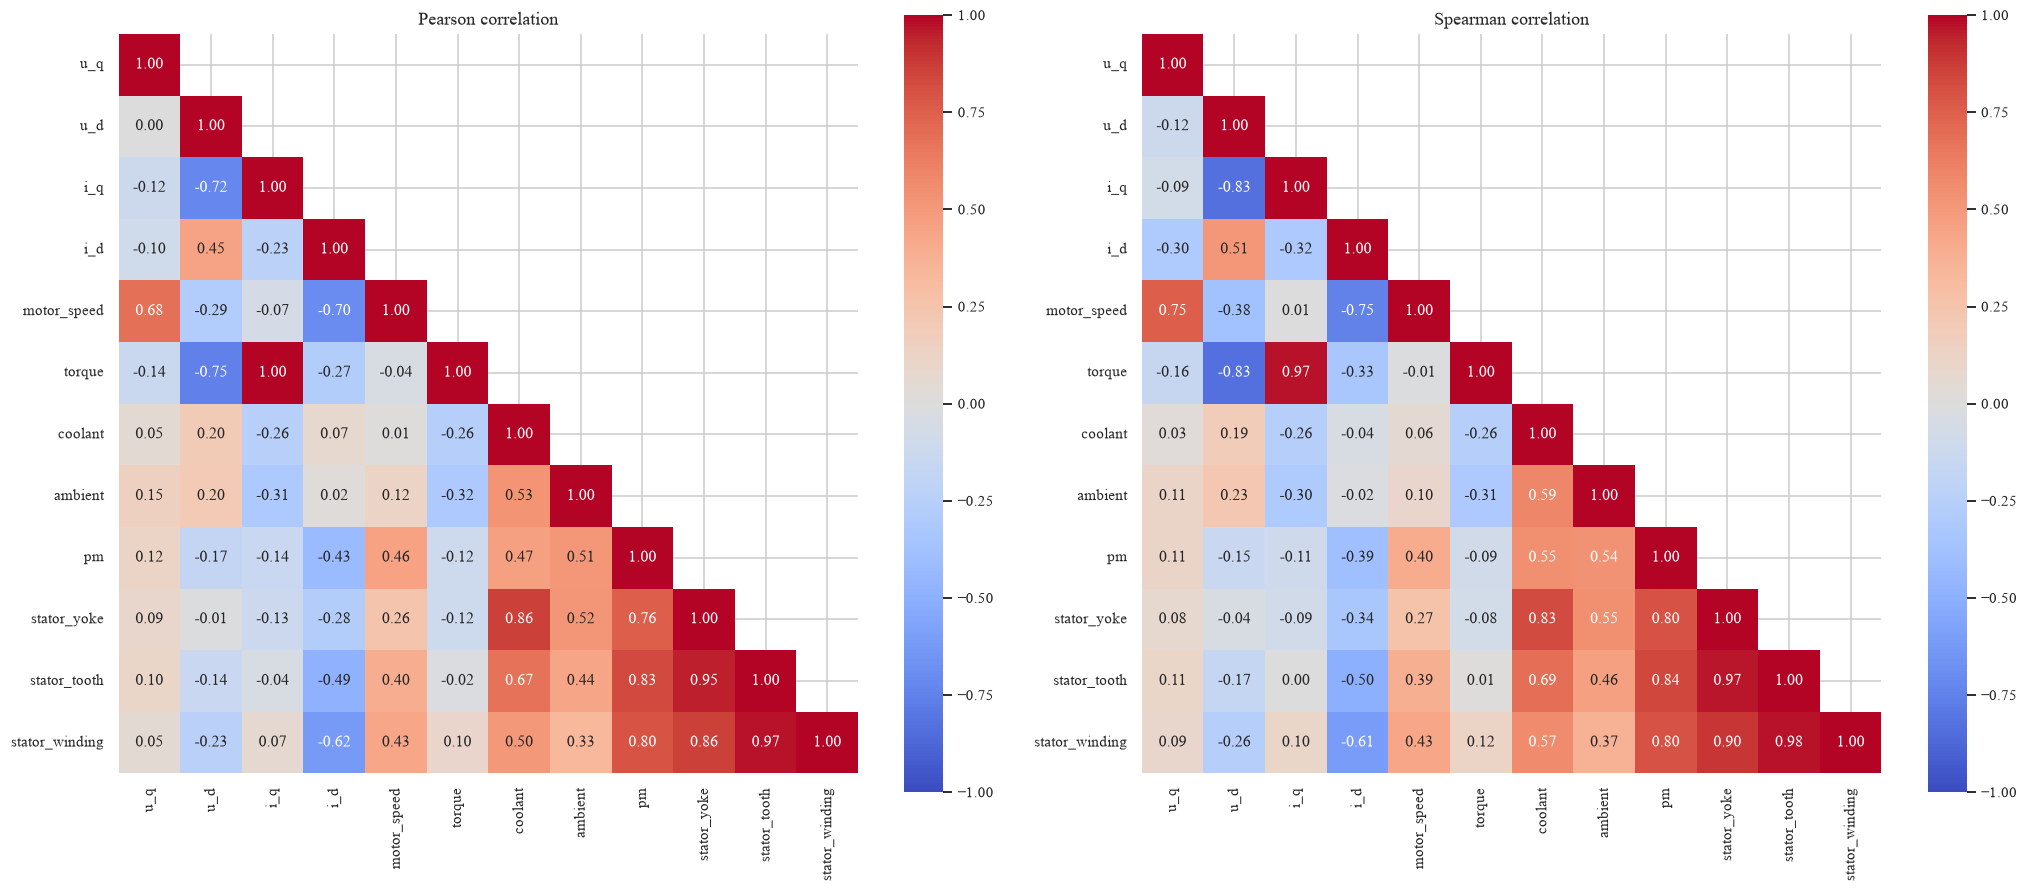

In [39]:
corr_cols = ALL_FEATURES
pearson = work_df[corr_cols].corr(method="pearson")
spearman = work_df[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(19, 8))
mask = np.triu(np.ones_like(pearson, dtype=bool), k=1)

for ax, mat, name in zip(axes, [pearson, spearman], ["Pearson", "Spearman"]):
    sns.heatmap(mat, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1, square=True, ax=ax)
    ax.set_title(f"{name} correlation")

fig.tight_layout()
save_figure(fig, "08_correlation_heatmaps")
plt.show()

## 8.1 Tabela analizy korelacji

In [40]:
pairs = []

for i, a in enumerate(corr_cols):
    for b in corr_cols[i + 1:]:
        p = pearson.loc[a, b]
        s = spearman.loc[a, b]

        pairs.append({
            "feature_a": a,
            "feature_b": b,
            "pearson": p,
            "spearman": s,
            "abs_pearson": abs(p),
            "nonlinearity": abs(s) - abs(p),
        })

correlation_analysis = (
    pd.DataFrame(pairs)
    .sort_values("abs_pearson", ascending=False)
    .reset_index(drop=True)
)

export_table(correlation_analysis, "correlation_analysis.csv",
             "Analiza korelacji Pearson/Spearman z miarą nieliniowości")

correlation_analysis.head(10)

23:58:09 | INFO    | Zapisano correlation_analysis.csv       (66 wierszy) -> Analiza korelacji Pearson/Spearman z miarą nieliniowości


,feature_a,feature_b,pearson,spearman,abs_pearson,nonlinearity
0,i_q,torque,0.9965,0.9738,0.9965,-0.0226
1,stator_tooth,stator_winding,0.9701,0.9766,0.9701,0.0064
2,stator_yoke,stator_tooth,0.9531,0.9652,0.9531,0.0121
3,coolant,stator_yoke,0.8608,0.8269,0.8608,-0.0338
4,stator_yoke,stator_winding,0.8603,0.8969,0.8603,0.0367
5,pm,stator_tooth,0.8321,0.8386,0.8321,0.0065
6,pm,stator_winding,0.7959,0.7994,0.7959,0.0035
7,pm,stator_yoke,0.7567,0.7991,0.7567,0.0424
8,u_d,torque,-0.7538,-0.8333,0.7538,0.0796
9,u_d,i_q,-0.7231,-0.8301,0.7231,0.1070


## 8.2 Pary motywowane fizycznie

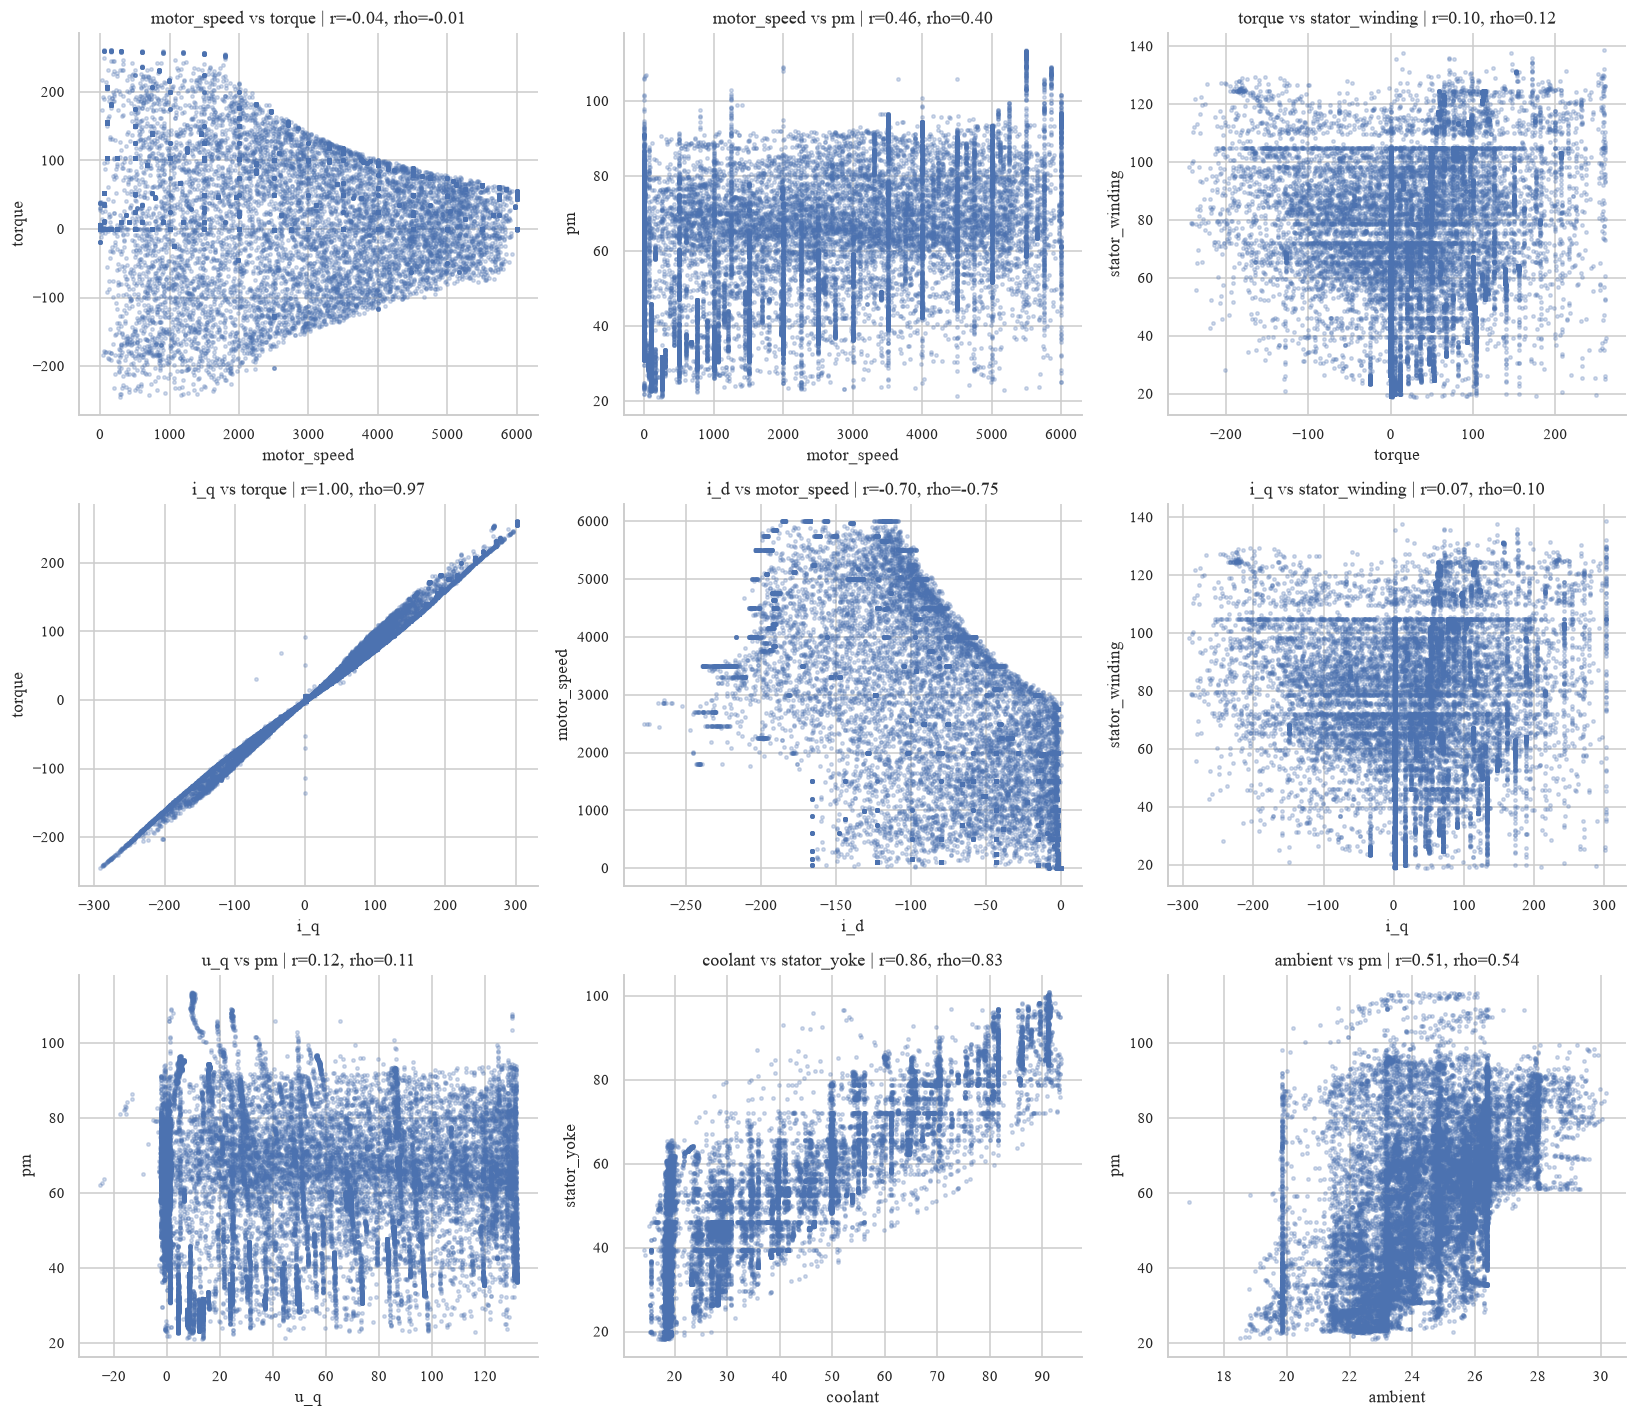

In [41]:
pair_specs = [
    ("motor_speed", "torque"),
    ("motor_speed", "pm"),
    ("torque", "stator_winding"),
    ("i_q", "torque"),
    ("i_d", "motor_speed"),
    ("i_q", "stator_winding"),
    ("u_q", "pm"),
    ("coolant", "stator_yoke"),
    ("ambient", "pm"),
]

scatter_sample = subsample_rows(work_df, MAX_POINTS_FOR_SCATTER)

fig, axes = plt.subplots(3, 3, figsize=(15, 13))

for ax, (a, b) in zip(axes.ravel(), pair_specs):
    ax.scatter(scatter_sample[a], scatter_sample[b], s=5, alpha=0.25)
    r = pearson.loc[a, b]
    rho = spearman.loc[a, b]
    ax.set(xlabel=a, ylabel=b)
    ax.set_title(f"{a} vs {b} | r={r:.2f}, rho={rho:.2f}")

fig.tight_layout()
save_figure(fig, "08_relationship_scatter_grid")
plt.show()

> **Interpretacja.**
>
> - `i_q` i `torque` powinny wykazywać bardzo silną zależność — oba opisują obciążenie osi q.
> - `motor_speed` i `u_q/u_d` są powiązane przez back-EMF i charakterystykę sterowania.
> - Temperatury są silnie wzajemnie skorelowane, ale opóźnione względem zmian punktu pracy.

# 9. Analiza zachowania termicznego

In [42]:
def thermal_profile_metrics(pid: int, frame: pd.DataFrame) -> dict[str, Any]:
    n = len(frame)
    edge = max(1, n // 20)
    load = frame[TEMPERATURE_FEATURES]

    metrics = {ID_COL: pid}

    for c in TEMPERATURE_FEATURES:
        s = frame[c]
        start = s.iloc[:edge].mean()
        end = s.iloc[-edge:].mean()

        metrics[f"{c}_mean"] = s.mean()
        metrics[f"{c}_max"] = s.max()
        metrics[f"{c}_rise"] = end - start
        metrics[f"{c}_rate_per_min"] = (
            (end - start) / max(n * SECONDS_PER_SAMPLE / 60.0, 1e-9)
        )

    return metrics

thermal_metrics = pd.DataFrame([
    thermal_profile_metrics(pid, grouped.get_group(pid))
    for pid in profile_ids
])

thermal_summary = pd.DataFrame({
    "component": TEMPERATURE_FEATURES,
    "avg_temperature": [work_df[c].mean() for c in TEMPERATURE_FEATURES],
    "max_temperature": [work_df[c].max() for c in TEMPERATURE_FEATURES],
    "mean_rise_per_profile": [thermal_metrics[f"{c}_rise"].mean() for c in TEMPERATURE_FEATURES],
    "mean_heating_rate_per_min": [thermal_metrics[f"{c}_rate_per_min"].mean() for c in TEMPERATURE_FEATURES],
    "volatility_std": [work_df[c].std() for c in TEMPERATURE_FEATURES],
})

hottest_component = thermal_summary.loc[thermal_summary["max_temperature"].idxmax(), "component"]
fastest_component = thermal_summary.loc[thermal_summary["mean_heating_rate_per_min"].idxmax(), "component"]
most_stable_component = thermal_summary.loc[thermal_summary["volatility_std"].idxmin(), "component"]

print("Najgorętszy komponent:", hottest_component)
print("Najszybciej nagrzewający się:", fastest_component)
print("Najbardziej stabilny:", most_stable_component)

thermal_summary

Najgorętszy komponent: stator_winding
Najszybciej nagrzewający się: pm
Najbardziej stabilny: pm


,component,avg_temperature,max_temperature,mean_rise_per_profile,mean_heating_rate_per_min,volatility_std
0,pm,58.5068,113.6066,19.4156,0.1700,19.0015
1,stator_yoke,48.1880,101.1480,8.2553,0.0756,19.9910
2,stator_tooth,56.8786,111.9464,7.7327,0.0874,22.9522
3,stator_winding,66.3427,141.3629,4.4537,0.0769,28.6721


## 9.1 Trajektorie termiczne i opóźnienie

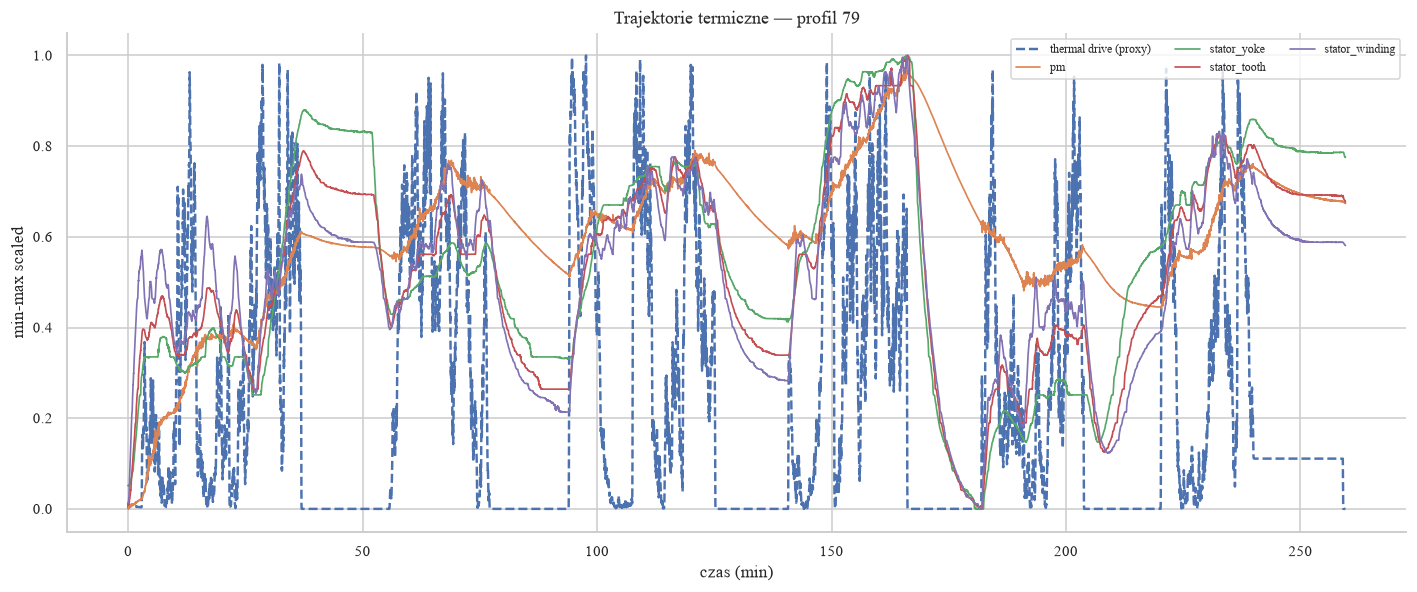

In [43]:
def _minmax(x: np.ndarray) -> np.ndarray:
    rng = np.ptp(x)
    return (x - x.min()) / rng if rng > 0 else np.zeros_like(x)

lag_frame = grouped.get_group(hottest_profile).reset_index(drop=True)
t_min = lag_frame["_time_seconds"] / 60.0

drive = _minmax((lag_frame["torque"] ** 2 + 0.4 * lag_frame["motor_speed"] ** 2).to_numpy())

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(t_min, drive, lw=1.6, ls="--", label="thermal drive (proxy)")

for c in TEMPERATURE_FEATURES:
    ax.plot(t_min, _minmax(lag_frame[c].to_numpy()), lw=1.1, label=c)

ax.set(xlabel="czas (min)", ylabel="min-max scaled", title=f"Trajektorie termiczne — profil {hottest_profile}")
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
save_figure(fig, "09_thermal_trajectories")
plt.show()

In [44]:
def estimated_lag_seconds(drive_sig: np.ndarray, temp_sig: np.ndarray, max_lag_s: float = 300.0) -> float:
    a = drive_sig - drive_sig.mean()
    b = temp_sig - temp_sig.mean()

    max_lag = min(int(max_lag_s * SAMPLING_FREQUENCY_HZ), len(a) - 1)

    best_lag, best_val = 0, -np.inf

    for lag in range(0, max_lag + 1):
        if lag == 0:
            val = np.dot(a, b)
        else:
            val = np.dot(a[:-lag], b[lag:])

        if val > best_val:
            best_val, best_lag = val, lag

    return best_lag * SECONDS_PER_SAMPLE

lag_rows = []

for c in TEMPERATURE_FEATURES:
    lag_s = estimated_lag_seconds(
        (lag_frame["torque"] ** 2 + 0.4 * lag_frame["motor_speed"] ** 2).to_numpy(),
        lag_frame[c].to_numpy(),
    )
    lag_rows.append({"component": c, "estimated_lag_seconds": lag_s})

lag_table = pd.DataFrame(lag_rows)
lag_table

,component,estimated_lag_seconds
0,pm,289.0000
1,stator_yoke,268.5000
2,stator_tooth,169.5000
3,stator_winding,167.0000


## 9.2 Korelacja termiczna i struktura scatter

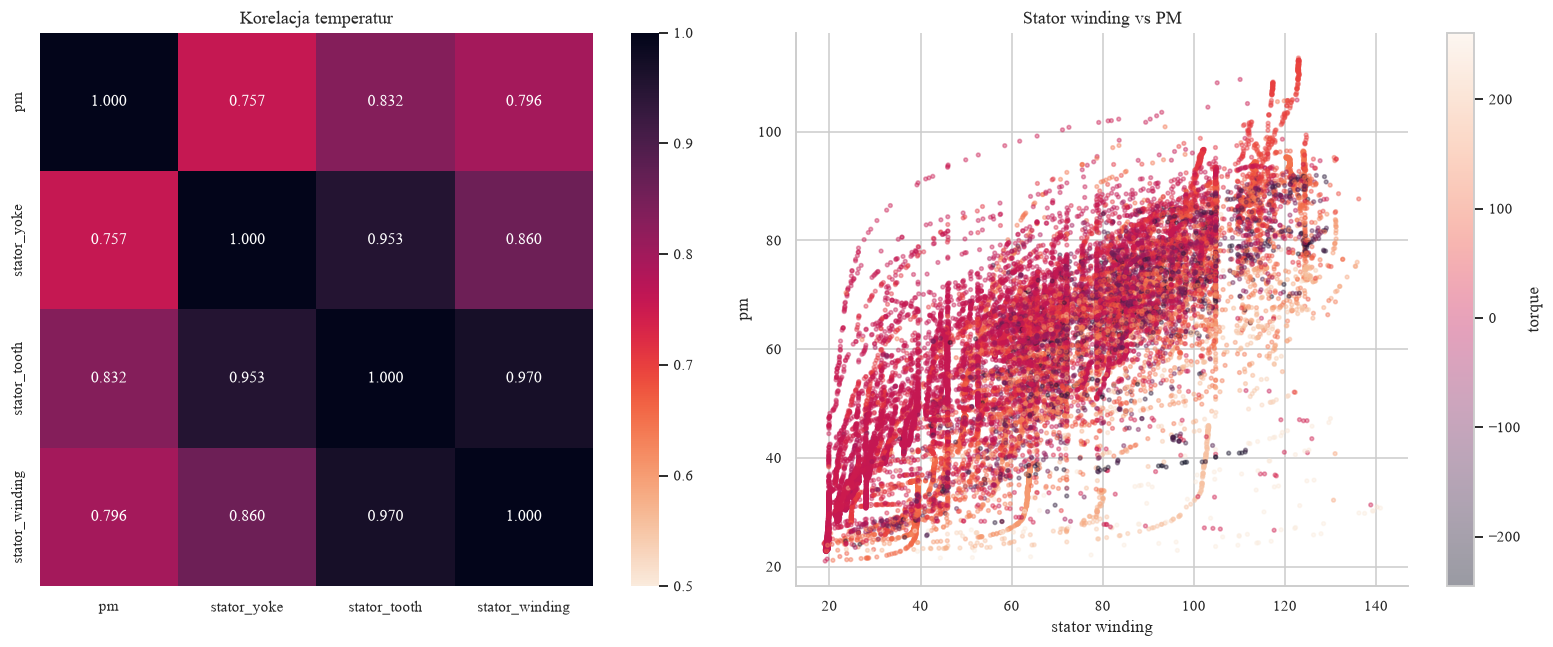

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(
    work_df[TEMPERATURE_FEATURES].corr(),
    annot=True,
    fmt=".3f",
    cmap="rocket_r",
    vmin=0.5,
    vmax=1.0,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Korelacja temperatur")

sc_sample = subsample_rows(work_df, MAX_POINTS_FOR_SCATTER)
sc = axes[1].scatter(
    sc_sample["stator_winding"],
    sc_sample["pm"],
    c=sc_sample["torque"],
    s=6,
    alpha=0.4,
)
axes[1].set(xlabel="stator winding", ylabel="pm", title="Stator winding vs PM")
fig.colorbar(sc, ax=axes[1], label="torque")

fig.tight_layout()
save_figure(fig, "09_thermal_correlation_scatter")
plt.show()

> **Interpretacja.** Kanały temperaturowe nie powinny definiować klastrów operacyjnych, ponieważ opisują skumulowany wynik wcześniejszej pracy. Są natomiast bardzo ważne jako zmienne walidacyjne dla znalezionych reżimów oraz jako ograniczenie fizyczne podczas augmentacji.

# 10. Analiza zachowania elektrycznego

In [46]:
electrical_report = pd.DataFrame({
    "variable": ELECTRICAL_FEATURES,
    "mean": [work_df[c].mean() for c in ELECTRICAL_FEATURES],
    "std": [work_df[c].std() for c in ELECTRICAL_FEATURES],
    "min": [work_df[c].min() for c in ELECTRICAL_FEATURES],
    "max": [work_df[c].max() for c in ELECTRICAL_FEATURES],
    "range": [np.ptp(work_df[c]) for c in ELECTRICAL_FEATURES],
    "mean_abs_step": [
        work_df.groupby(ID_COL)[c].apply(lambda s: s.diff().abs().mean()).mean()
        for c in ELECTRICAL_FEATURES
    ],
})

electrical_report["dynamism_rank"] = electrical_report["mean_abs_step"].rank(
    ascending=False
).astype(int)

most_dynamic_electrical = electrical_report.loc[
    electrical_report["mean_abs_step"].idxmax(),
    "variable"
]

print("Najbardziej dynamiczna zmienna elektryczna:", most_dynamic_electrical)
electrical_report

Najbardziej dynamiczna zmienna elektryczna: i_q


,variable,mean,std,min,max,range,mean_abs_step,dynamism_rank
0,u_q,54.2790,44.1732,-25.2909,133.0370,158.3279,0.8710,4
1,u_d,-25.1338,63.0920,-131.5304,131.4698,263.0002,1.0548,3
2,i_q,37.4128,92.1819,-293.4268,301.7079,595.1346,1.2279,1
3,i_d,-68.7168,64.9332,-278.0036,0.0519,278.0555,1.1698,2


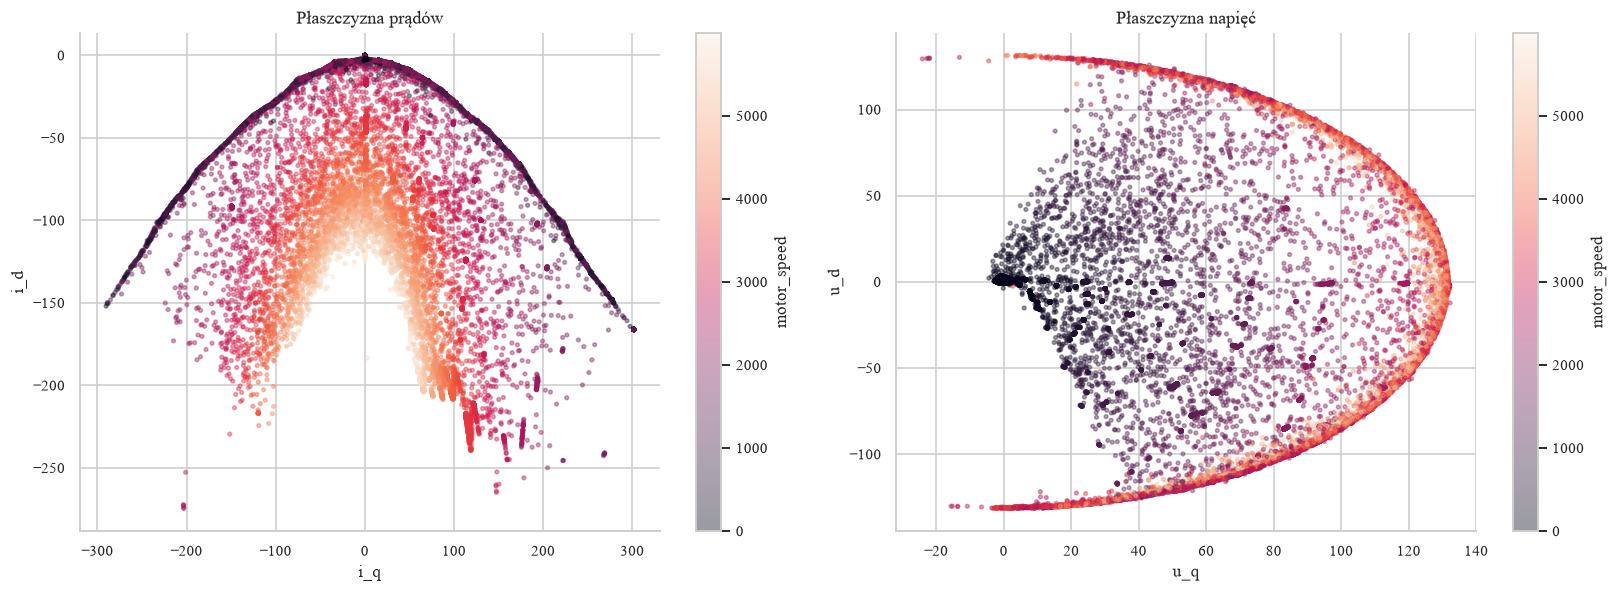

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
elec_sample = subsample_rows(work_df, MAX_POINTS_FOR_SCATTER)

sc1 = axes[0].scatter(elec_sample["i_q"], elec_sample["i_d"], c=elec_sample["motor_speed"], s=6, alpha=0.4)
axes[0].set(xlabel="i_q", ylabel="i_d", title="Płaszczyzna prądów")
fig.colorbar(sc1, ax=axes[0], label="motor_speed")

sc2 = axes[1].scatter(elec_sample["u_q"], elec_sample["u_d"], c=elec_sample["motor_speed"], s=6, alpha=0.4)
axes[1].set(xlabel="u_q", ylabel="u_d", title="Płaszczyzna napięć")
fig.colorbar(sc2, ax=axes[1], label="motor_speed")

fig.tight_layout()
save_figure(fig, "10_electrical_planes")
plt.show()

> **Interpretacja.** `i_q` zwykle śledzi zapotrzebowanie na moment, a `i_d` staje się bardziej ujemne w obszarze osłabiania pola przy wysokiej prędkości. Kanały elektryczne są częściowo redundantne względem `speed/torque`, ale nie wszystkie — wybrane mogą być użyteczne w przyszłej klasteryzacji.

# 11. Analiza stanów pracy

/var/folders/nf/j0vc12bd6kvblbd7by89d73r0000gn/T/ipykernel_79362/3947205544.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


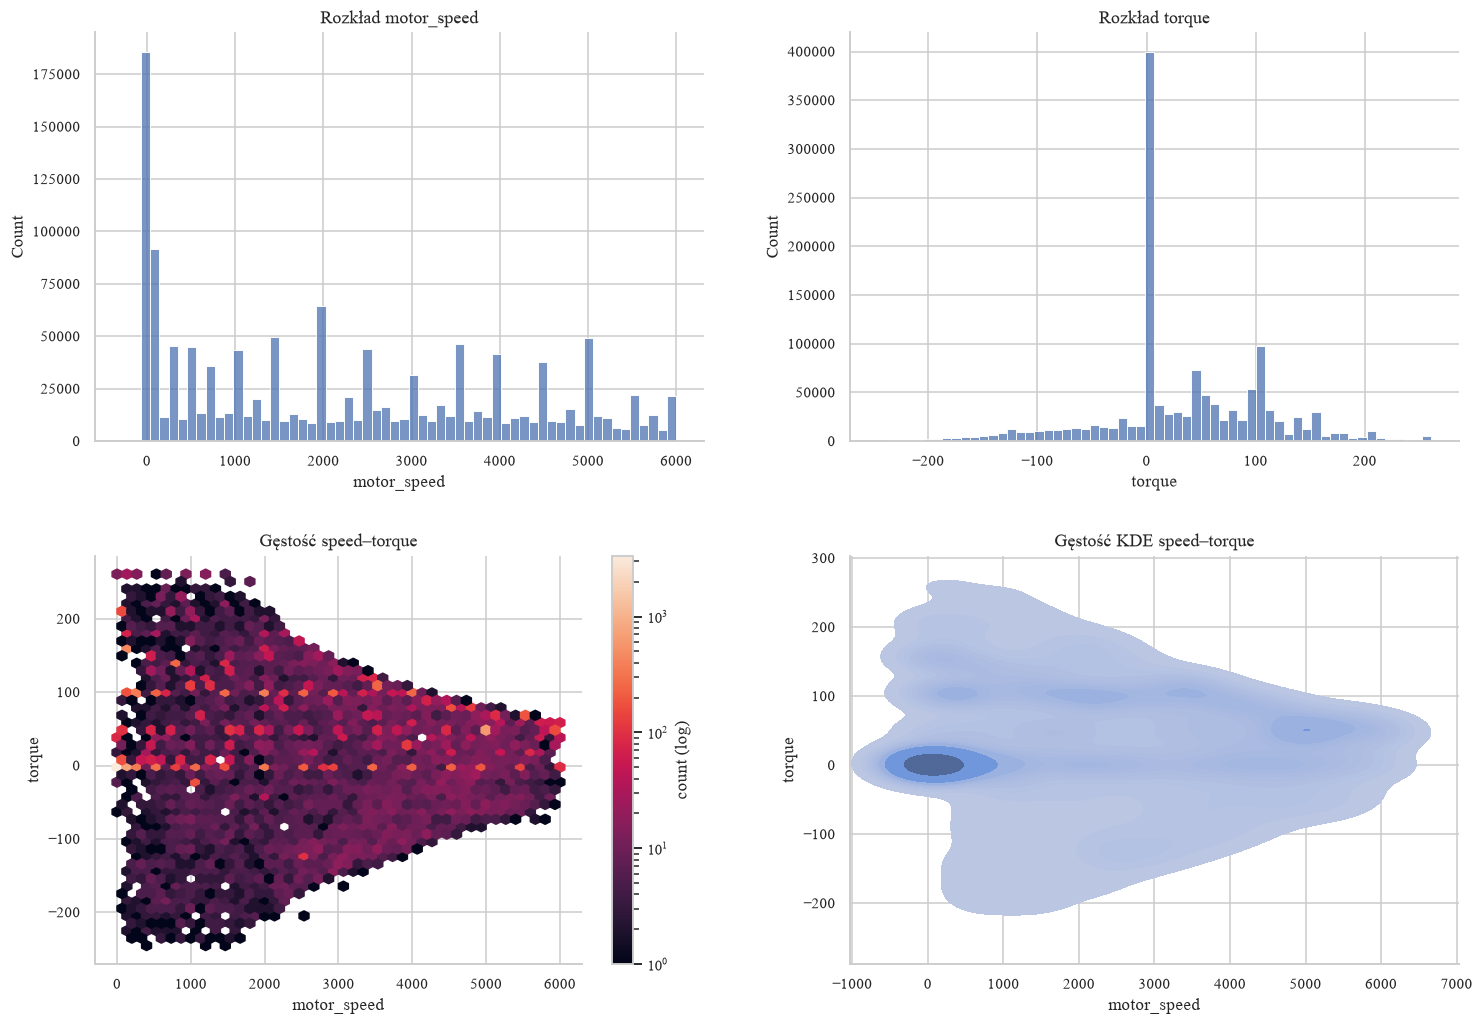

In [48]:
os_sample = subsample_rows(work_df, MAX_POINTS_FOR_SCATTER)

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, figure=fig, hspace=0.28, wspace=0.24)

ax0 = fig.add_subplot(gs[0, 0])
sns.histplot(work_df["motor_speed"], bins=60, ax=ax0)
ax0.set_title("Rozkład motor_speed")

ax1 = fig.add_subplot(gs[0, 1])
sns.histplot(work_df["torque"], bins=60, ax=ax1)
ax1.set_title("Rozkład torque")

ax2 = fig.add_subplot(gs[1, 0])
hb = ax2.hexbin(os_sample["motor_speed"], os_sample["torque"], gridsize=45, bins="log")
ax2.set(xlabel="motor_speed", ylabel="torque", title="Gęstość speed–torque")
fig.colorbar(hb, ax=ax2, label="count (log)")

ax3 = fig.add_subplot(gs[1, 1])
sns.kdeplot(data=os_sample, x="motor_speed", y="torque", fill=True, levels=12, thresh=0.02, ax=ax3)
ax3.set(xlabel="motor_speed", ylabel="torque", title="Gęstość KDE speed–torque")

fig.tight_layout()
save_figure(fig, "11_operating_state")
plt.show()

## 11.1 Kandydackie definicje stanów pracy

> **Adnotacja metodologiczna.** Podział 3×3 według tercyli `motor_speed`/`torque` jest **jedynie wstępną wizualizacją rozkładu** punktów pracy i **zostaje odrzucony** w dalszej pracy na rzecz **klasteryzacji beznadzorowej**. Sztywne progi kwantylowe są arbitralne i — co kluczowe — **nie uwzględniają fizycznej obwiedni osłabiania pola** (field weakening): granica moment–prędkość jest nieliniowa i krzywoliniowa, więc prostokątna siatka tercyli tnie spójne reżimy fizyczne i łączy niespójne. Traktuj tę sekcję opisowo, nie jako docelową definicję reżimów.

In [49]:
speed_t = work_df["motor_speed"].quantile([1/3, 2/3]).to_numpy()
torque_t = work_df["torque"].quantile([1/3, 2/3]).to_numpy()

def label_state(row: pd.Series) -> str:
    s = "low" if row["motor_speed"] <= speed_t[0] else ("high" if row["motor_speed"] > speed_t[1] else "mid")
    l = "low" if row["torque"] <= torque_t[0] else ("high" if row["torque"] > torque_t[1] else "mid")

    if s == "low" and l == "low":
        return "idle / low-load"
    if s == "high" and l == "high":
        return "high-speed high-load"
    if s == "high" and l == "low":
        return "high-speed light-load"
    return f"{s}-speed {l}-load"

work_df["_operating_state"] = work_df.apply(label_state, axis=1)

state_counts = (
    work_df["_operating_state"]
    .value_counts()
    .rename_axis("operating_state")
    .reset_index(name="samples")
)

state_counts["time_pct"] = 100.0 * state_counts["samples"] / len(work_df)
state_counts

,operating_state,samples,time_pct
0,low-speed mid-load,200815,15.0896
1,mid-speed high-load,192850,14.4911
2,mid-speed low-load,164290,12.3451
3,high-speed light-load,157790,11.8566
4,high-speed mid-load,152984,11.4955
5,high-speed high-load,132830,9.9811
6,idle / low-load,124866,9.3827
7,low-speed high-load,117925,8.8611
8,mid-speed mid-load,86466,6.4972


# 12. Eksploracja na poziomie segmentów

In [50]:
def build_segments(frame: pd.DataFrame, length: int, overlap: float) -> list[dict[str, Any]]:
    step = max(1, int(length * (1 - overlap)))
    rows = []

    for pid, g in frame.groupby(ID_COL):
        g = g.reset_index(drop=True)
        n = len(g)

        if n < length:
            continue

        for start in range(0, n - length + 1, step):
            seg = g.iloc[start:start + length]
            temp_mean = seg[TEMPERATURE_FEATURES].mean(axis=1)

            rows.append({
                ID_COL: pid,
                "start_sample": start,
                "avg_speed": seg["motor_speed"].mean(),
                "avg_torque": seg["torque"].mean(),
                "speed_variability": seg["motor_speed"].std(),
                "torque_variability": seg["torque"].std(),
                "current_variability": seg[["i_q", "i_d"]].std().mean(),
                "temperature_change": temp_mean.iloc[-1] - temp_mean.iloc[0],
                "operating_state": seg["_operating_state"].mode().iloc[0],
            })

    return rows

segment_tables: dict[int, pd.DataFrame] = {}
segment_rows_all = []

for length_s in SEGMENT_LENGTHS_SECONDS:
    length = int(length_s * SAMPLING_FREQUENCY_HZ)
    rows = build_segments(work_df, length, SEGMENT_OVERLAP)
    tbl = pd.DataFrame(rows)
    tbl.insert(1, "segment_seconds", length_s)
    segment_tables[length_s] = tbl
    segment_rows_all.extend(tbl.to_dict("records"))
    LOGGER.info("%3d s -> %d segmentów z %d profili",
                length_s, len(tbl), tbl[ID_COL].nunique() if len(tbl) else 0)

segment_summary = pd.DataFrame(segment_rows_all)
export_table(segment_summary, "segment_summary.csv",
             "Podsumowanie segmentów dla wszystkich kandydackich długości")

segment_summary.head(10)

23:59:05 | INFO    |  60 s -> 22079 segmentów z 69 profili
23:59:16 | INFO    | 120 s -> 10992 segmentów z 69 profili
23:59:22 | INFO    | 300 s -> 4333 segmentów z 69 profili
23:59:23 | INFO    | Zapisano segment_summary.csv            (37404 wierszy) -> Podsumowanie segmentów dla wszystkich kandydackich długości


,profile_id,segment_seconds,start_sample,avg_speed,avg_torque,speed_variability,torque_variability,current_variability,temperature_change,operating_state
0,2,60,0,100.0349,164.2771,0.1206,80.8669,70.6951,5.1264,low-speed high-load
1,2,60,60,99.9943,208.1828,0.0220,0.0554,0.0004,7.1621,low-speed high-load
2,2,60,120,99.9941,208.0847,0.0235,0.0590,0.0004,6.9497,low-speed high-load
3,2,60,180,99.9941,207.9818,0.0243,0.0618,0.0004,6.5804,low-speed high-load
4,2,60,240,99.9941,207.8731,0.0233,0.0638,0.0004,5.8846,low-speed high-load
5,2,60,300,99.9939,207.7776,0.0241,0.0491,0.0003,5.5217,low-speed high-load
6,2,60,360,99.9941,207.6846,0.0250,0.0681,0.0004,4.8863,low-speed high-load
7,2,60,420,99.9940,207.6178,0.0235,0.0454,0.0004,4.1913,low-speed high-load
8,2,60,480,99.9943,207.6128,0.0232,0.0254,0.0004,4.1215,low-speed high-load
9,2,60,540,99.9950,207.6071,0.0248,0.0217,0.0004,3.7986,low-speed high-load


## 12.1 Porównanie długości segmentów

23:59:23 | INFO    | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
23:59:23 | INFO    | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
23:59:23 | INFO    | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
23:59:23 | INFO    | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
23:59:23 | INFO    | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbe

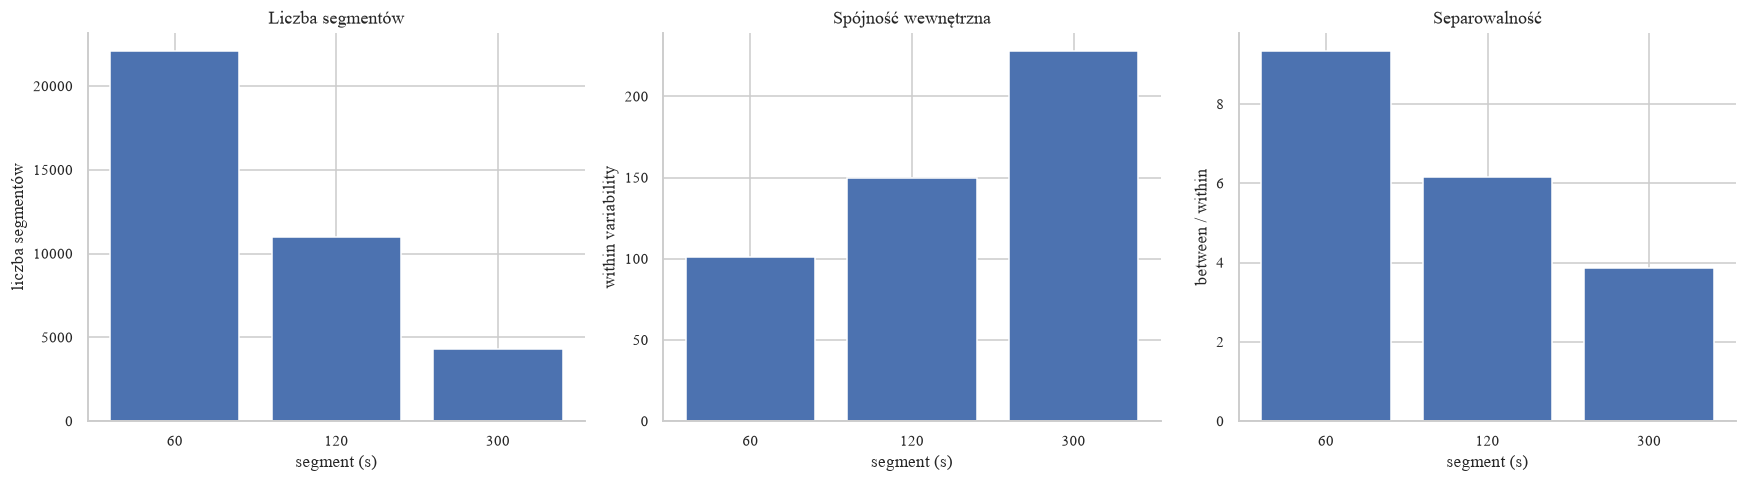

Rekomendowana długość segmentu: 60 s


,segment_seconds,n_segments,mean_within_segment_variability,between_segment_spread,separability_ratio,profiles_covered,profiles_too_short
0,60,22079,100.9732,942.3304,9.3325,69,0
1,120,10992,149.6043,921.0637,6.1567,69,0
2,300,4333,227.8176,881.6405,3.8699,69,0


In [51]:
def segment_duration_metrics(length_s: int, tbl: pd.DataFrame) -> dict[str, Any]:
    if tbl.empty:
        return {"segment_seconds": length_s, "n_segments": 0}

    within = tbl[["speed_variability", "torque_variability"]].mean().mean()
    between = tbl[["avg_speed", "avg_torque"]].std().mean()

    return {
        "segment_seconds": length_s,
        "n_segments": len(tbl),
        "mean_within_segment_variability": within,
        "between_segment_spread": between,
        "separability_ratio": between / within if within > 0 else np.nan,
        "profiles_covered": int(tbl[ID_COL].nunique()),
        "profiles_too_short": n_profiles - int(tbl[ID_COL].nunique()),
    }

segment_comparison = pd.DataFrame([
    segment_duration_metrics(s, segment_tables[s])
    for s in SEGMENT_LENGTHS_SECONDS
])

best_row = segment_comparison.loc[segment_comparison["separability_ratio"].idxmax()]
recommended_segment_seconds = int(best_row["segment_seconds"])
# UWAGA METODOLOGICZNA: recommended_segment_seconds (60 s przy separability_ratio ~9.33)
# maksymalizuje wylacznie elektromechaniczna separowalnosc segmentow (szybka dynamika
# speed/torque). Jest to okno POPRAWNE dla szybkiej analizy elektromechanicznej, ale
# FIZYCZNIE ZBYT KROTKIE dla modelowania termicznego: mediana lagu pm wynosi ~269.5 s,
# a czas zaniku ACF ~560.5 s (rozdz. 22.2). Oficjalna rekomendacja badawcza dla
# Notebooka #2 to okno 120 s lub 300 s (kompromis dynamika vs. bezwladnosc termiczna).

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].bar(segment_comparison["segment_seconds"].astype(str), segment_comparison["n_segments"])
axes[0].set(xlabel="segment (s)", ylabel="liczba segmentów", title="Liczba segmentów")

axes[1].bar(segment_comparison["segment_seconds"].astype(str),
            segment_comparison["mean_within_segment_variability"])
axes[1].set(xlabel="segment (s)", ylabel="within variability", title="Spójność wewnętrzna")

axes[2].bar(segment_comparison["segment_seconds"].astype(str),
            segment_comparison["separability_ratio"])
axes[2].set(xlabel="segment (s)", ylabel="between / within", title="Separowalność")

fig.tight_layout()
save_figure(fig, "12_segment_duration_comparison")
plt.show()

print(f"Rekomendowana długość segmentu: {recommended_segment_seconds} s")
segment_comparison

> **Interpretacja.** Krótkie okna dostarczają więcej próbek, ale łatwiej przecinają przejścia dynamiczne. Długie okna są stabilniejsze, ale mogą mieszać dwa reżimy. Wybór długości segmentu powinien opierać się na kompromisie liczebność–spójność–separowalność.
>
> **Zastrzeżenie metodologiczne (długość okna).** Wskazanie `recommended_segment_seconds = 60 s` (maksimum `separability_ratio ≈ 9.33`) jest poprawne **wyłącznie dla szybkiej analizy elektromechanicznej**, gdzie liczy się rozdzielenie stanów prędkość/moment. Jest ono jednak **fizycznie zbyt krótkie do modelowania termicznego**: mediana opóźnienia temperatury magnesów (`pm`) wynosi **≈ 269.5 s**, a czas zaniku autokorelacji (ACF) **≈ 560.5 s** (por. Rozdział 22.2). Okno 60 s nie obejmuje pełnej stałej czasowej bezwładności termicznej i ucina dynamikę nagrzewania.
>
> **Oficjalna rekomendacja badawcza dla Notebooka #2: okno 120 s lub 300 s** — kompromis między elektromechaniczną separowalnością a bezwładnością termiczną. Okno 60 s pozostaje wyłącznie jako baseline elektromechaniczny.

# 13. Analiza pokrycia przestrzeni pracy

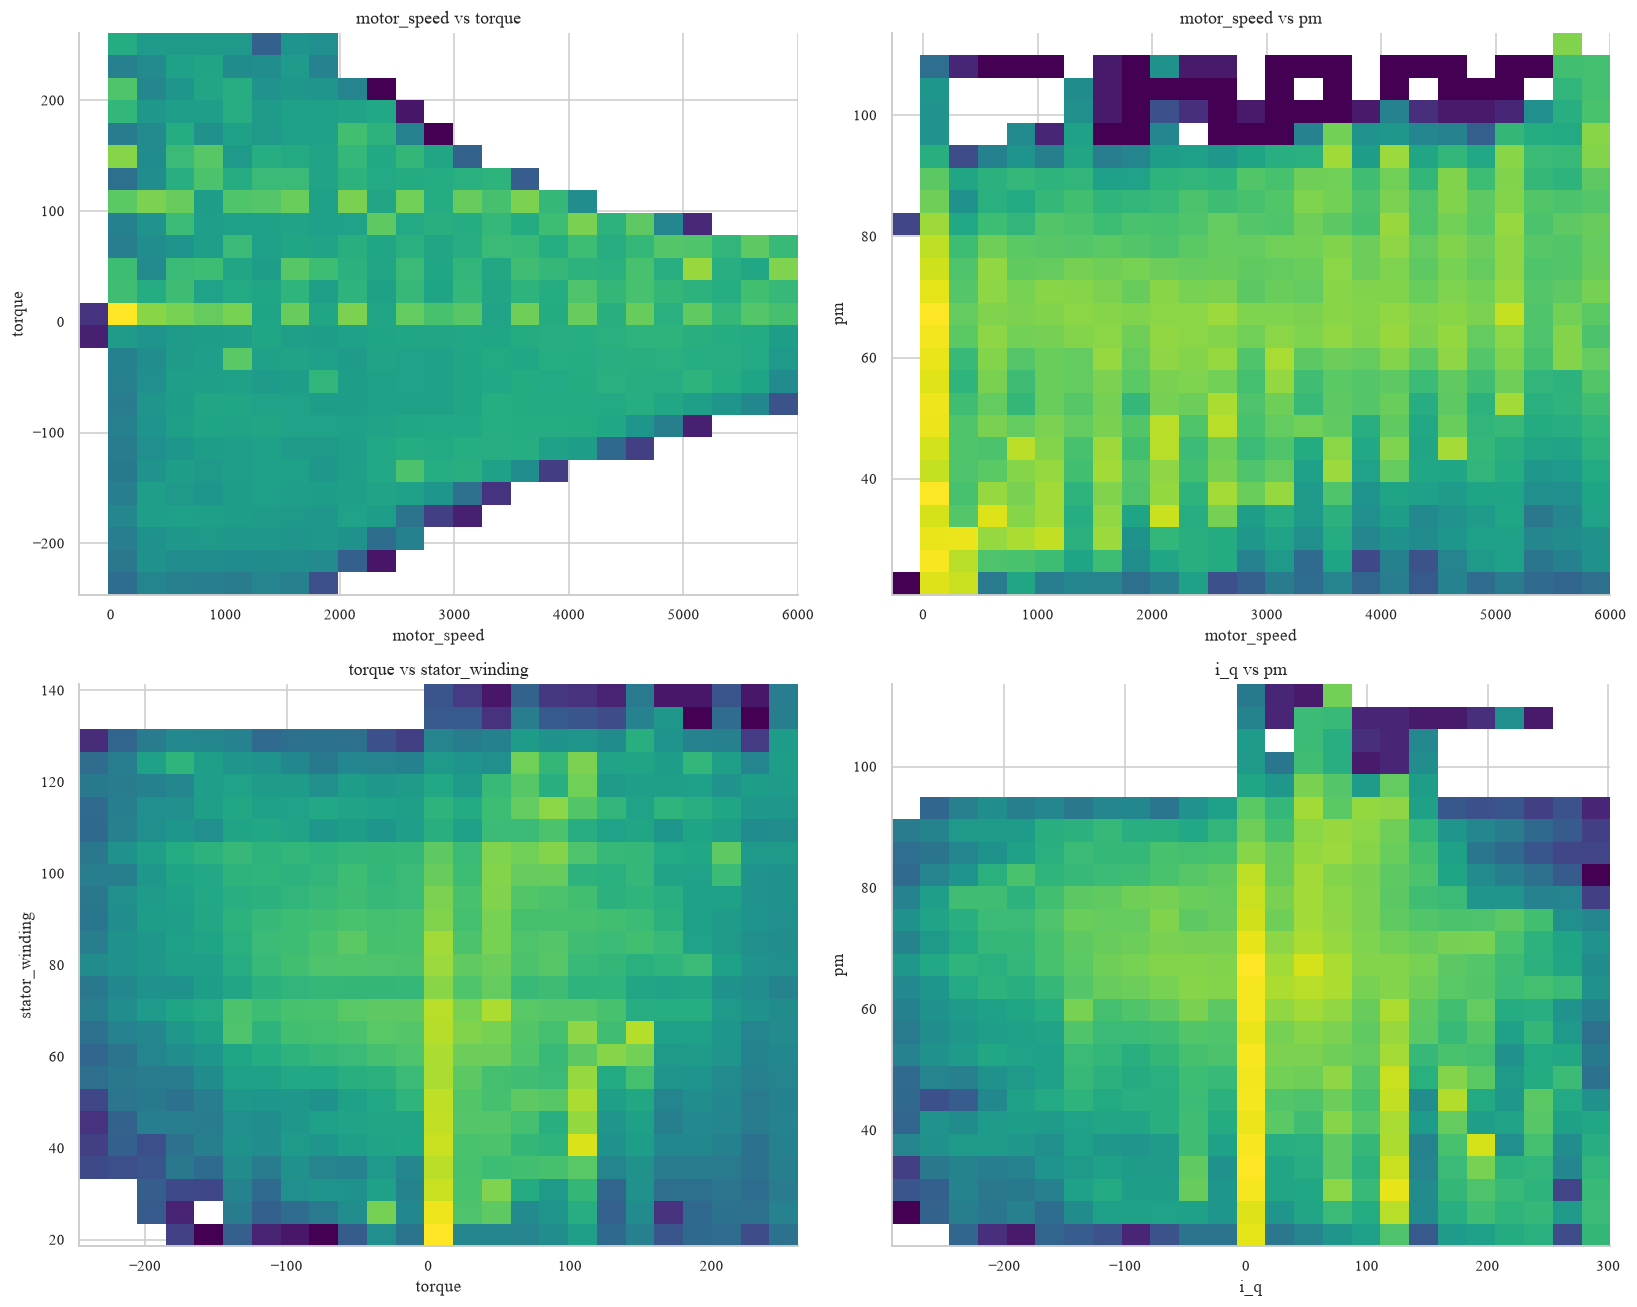

23:59:24 | INFO    | Zapisano coverage_analysis.csv          (4 wierszy) -> Pokrycie kluczowych płaszczyzn pracy


,plane,grid,occupied_cells,empty_cells,coverage_pct,dense_cells,sparse_cells,max_cell_count
0,motor_speed vs torque,25x25,421,204,67.3600,106,107,227177
1,motor_speed vs pm,25x25,559,66,89.4400,140,140,25787
2,torque vs stator_winding,25x25,593,32,94.8800,149,149,80971
3,i_q vs pm,25x25,532,93,85.1200,134,133,33921


In [52]:
coverage_pairs = [
    ("motor_speed", "torque"),
    ("motor_speed", "pm"),
    ("torque", "stator_winding"),
    ("i_q", "pm"),
]

N_BINS = 25
cov_sample = subsample_rows(work_df, MAX_POINTS_FOR_SCATTER)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
coverage_records = []

for ax, (a, b) in zip(axes.ravel(), coverage_pairs):
    counts, xedges, yedges, im = ax.hist2d(
        work_df[a],
        work_df[b],
        bins=N_BINS,
        cmap="viridis",
        norm=matplotlib.colors.LogNorm(),
    )
    ax.set(xlabel=a, ylabel=b, title=f"{a} vs {b}")

    occupied = counts > 0
    total_cells = counts.size
    n_occupied = int(occupied.sum())

    nonzero = counts[occupied]
    dense_thr = np.quantile(nonzero, 0.75) if nonzero.size else 0
    sparse_thr = np.quantile(nonzero, 0.25) if nonzero.size else 0

    coverage_records.append({
        "plane": f"{a} vs {b}",
        "grid": f"{N_BINS}x{N_BINS}",
        "occupied_cells": n_occupied,
        "empty_cells": total_cells - n_occupied,
        "coverage_pct": 100.0 * n_occupied / total_cells,
        "dense_cells": int((counts >= dense_thr).sum()) if dense_thr > 0 else 0,
        "sparse_cells": int(((counts > 0) & (counts <= sparse_thr)).sum()) if sparse_thr > 0 else 0,
        "max_cell_count": int(counts.max()),
    })

fig.tight_layout()
save_figure(fig, "13_coverage_maps")
plt.show()

coverage_analysis = pd.DataFrame(coverage_records)
export_table(coverage_analysis, "coverage_analysis.csv",
             "Pokrycie kluczowych płaszczyzn pracy")

coverage_analysis

> **Interpretacja.** Rzadkie, ale zajęte obszary są potencjalnym celem augmentacji. Puste obszary nie powinny być automatycznie wypełniane — mogą odpowiadać warunkom pracy, których maszyna nie osiąga lub które są fizycznie niedozwolone.

# 14. Gotowość do klasteryzacji — przestrzeń cech na poziomie profilu

> **Doprecyzowanie zakresu analizy.** PCA i przestrzeń cech w tym rozdziale liczone są na **82 cechach zagregowanych na poziomie całych sesji pomiarowych** (jeden wektor cech na `profile_id`). Jest to więc **Profile Fingerprinting** — analiza *różnorodności i podobieństwa całych profili* między sobą. **Nie służy** do wyznaczania **lokalnych reżimów wewnątrzprofilowych** (te wykrywa dopiero segmentacja + klasteryzacja beznadzorowa w Notebooku #2). Innymi słowy: tu odpowiadamy „jak bardzo różnią się sesje pomiarowe", a nie „jakie reżimy pracy występują wewnątrz jednej sesji".

In [53]:
def _slope_per_min(series: pd.Series) -> float:
    y = series.to_numpy()
    if len(y) < 2:
        return 0.0
    x = np.arange(len(y)) * SECONDS_PER_SAMPLE / 60.0
    return float(np.polyfit(x, y, 1)[0])

def _approx_entropy(series: pd.Series, bins: int = 16) -> float:
    hist, _ = np.histogram(series.dropna(), bins=bins, density=False)
    p = hist / hist.sum() if hist.sum() else hist
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

def _lag1_autocorr(series: pd.Series) -> float:
    y = series.to_numpy()
    if len(y) < 3 or np.std(y) == 0:
        return 0.0
    return float(np.corrcoef(y[:-1], y[1:])[0, 1])

def engineer_profile_features(pid: int, frame: pd.DataFrame) -> dict[str, Any]:
    feats: dict[str, Any] = {ID_COL: pid}

    for c in CONDITION_FEATURES:
        s = frame[c]
        feats[f"{c}_mean"] = s.mean()
        feats[f"{c}_std"] = s.std()
        feats[f"{c}_min"] = s.min()
        feats[f"{c}_max"] = s.max()
        feats[f"{c}_median"] = s.median()
        feats[f"{c}_slope"] = _slope_per_min(s)
        feats[f"{c}_energy"] = float(np.mean(np.square(s.to_numpy())))
        feats[f"{c}_entropy"] = _approx_entropy(s)
        feats[f"{c}_acf1"] = _lag1_autocorr(s)

    edge = max(1, len(frame) // 20)

    for c in TEMPERATURE_FEATURES:
        s = frame[c]
        feats[f"{c}_delta"] = s.iloc[-edge:].mean() - s.iloc[:edge].mean()
        feats[f"{c}_heating_rate"] = feats[f"{c}_delta"] / max(
            len(frame) * SECONDS_PER_SAMPLE / 60.0, 1e-9
        )

    feats["avg_speed"] = frame["motor_speed"].mean()
    feats["avg_torque"] = frame["torque"].mean()

    return feats

profile_features = pd.DataFrame([
    engineer_profile_features(pid, grouped.get_group(pid))
    for pid in profile_ids
])

feature_matrix_cols = [c for c in profile_features.columns if c != ID_COL]

X = profile_features[feature_matrix_cols].to_numpy()
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
X_scaled = StandardScaler().fit_transform(X)

print(f"Macierz cech profilowych: {X_scaled.shape[0]} profili x {X_scaled.shape[1]} cech")

Macierz cech profilowych: 69 profili x 82 cech


## 14.1 PCA — struktura liniowa i wyjaśniona wariancja

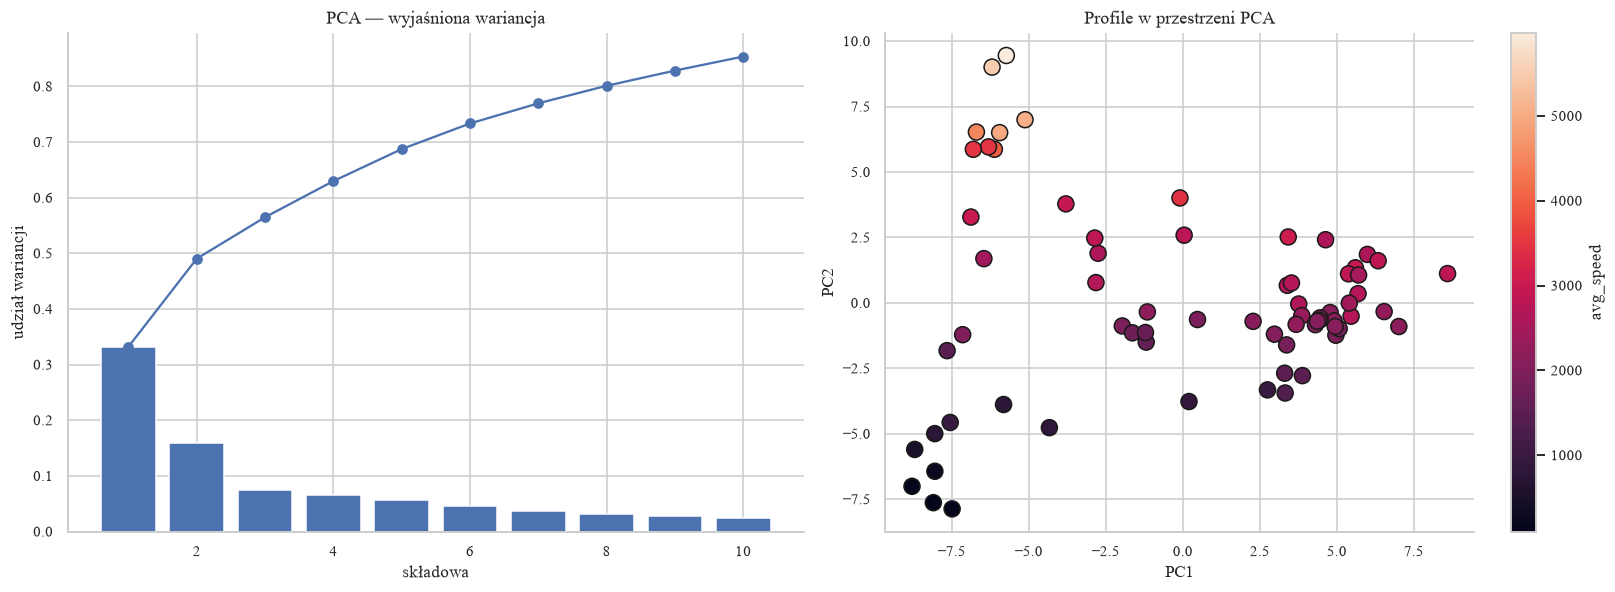

Wariancja PC1+PC2: 49.0%
Liczba komponentów do 90%: 11


In [54]:
n_comp = min(10, X_scaled.shape[0], X_scaled.shape[1])
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].bar(np.arange(1, len(explained) + 1), explained)
axes[0].plot(np.arange(1, len(explained) + 1), np.cumsum(explained), marker="o")
axes[0].set(xlabel="składowa", ylabel="udział wariancji", title="PCA — wyjaśniona wariancja")

sc = axes[1].scatter(
    pcs[:, 0],
    pcs[:, 1],
    c=profile_summary.set_index(ID_COL).loc[profile_ids, "avg_speed"],
    s=110,
    edgecolor="k",
)
axes[1].set(xlabel="PC1", ylabel="PC2", title="Profile w przestrzeni PCA")
fig.colorbar(sc, ax=axes[1], label="avg_speed")

fig.tight_layout()
save_figure(fig, "14_pca")
plt.show()

print(f"Wariancja PC1+PC2: {explained[:2].sum() * 100:.1f}%")
print(f"Liczba komponentów do 90%: {int(np.searchsorted(np.cumsum(explained), 0.90) + 1)}")

# 15. Ważność cech dla przyszłej klasteryzacji

In [55]:
abs_corr = work_df[ALL_FEATURES].corr().abs()
# Uwaga: corr() moze zwracac tablice tylko-do-odczytu (read-only), przez co
# np.fill_diagonal(abs_corr.values, 0.0) rzuca ValueError: underlying array is read-only.
# Wymuszamy kopie tablicy, zerujemy przekatna i odtwarzamy DataFrame.
abs_corr_values = abs_corr.to_numpy(copy=True)
np.fill_diagonal(abs_corr_values, 0.0)
abs_corr = pd.DataFrame(abs_corr_values, index=abs_corr.index, columns=abs_corr.columns)

readiness_rows = []

for c in ALL_FEATURES:
    role = (
        "thermal" if c in TEMPERATURE_FEATURES
        else "context" if c in CONTEXT_FEATURES
        else "operational" if c in OPERATIONAL_FEATURES
        else "electrical"
    )

    activity = work_df.groupby(ID_COL)[c].apply(lambda s: s.diff().abs().mean()).mean()
    max_redundancy = abs_corr[c].max()
    most_redundant_with = abs_corr[c].idxmax()

    readiness_rows.append({
        "feature": c,
        "role": role,
        "std": work_df[c].std(),
        "dynamic_activity": activity,
        "max_abs_corr": max_redundancy,
        "redundant_with": most_redundant_with,
    })

readiness = pd.DataFrame(readiness_rows)

readiness["uniqueness"] = 1.0 - readiness["max_abs_corr"]
readiness["info_score"] = (
    readiness["dynamic_activity"] / max(readiness["dynamic_activity"].max(), 1e-9)
) * (0.5 + 0.5 * readiness["uniqueness"])

def assign_tier(row: pd.Series) -> str:
    if row["role"] == "thermal":
        return "Avoid (outcome — use to validate, not to cluster)"
    if row["feature"] in OPERATIONAL_FEATURES:
        return "Must Include"
    if row["role"] == "context":
        return "Optional (regime context; risks clustering by test setup)"
    if row["info_score"] >= 0.5 and row["max_abs_corr"] < 0.95:
        return "Useful"
    return "Optional (electrical, partly redundant)"

readiness["tier"] = readiness.apply(assign_tier, axis=1)
readiness["reasoning"] = readiness.apply(
    lambda r: f"role={r['role']}; activity={r['dynamic_activity']:.3f}; "
              f"max|corr|={r['max_abs_corr']:.3f} with {r['redundant_with']}",
    axis=1,
)

clustering_readiness = readiness[
    ["feature", "role", "tier", "std", "dynamic_activity",
     "max_abs_corr", "redundant_with", "info_score", "reasoning"]
].sort_values(["tier", "info_score"], ascending=[True, False]).reset_index(drop=True)

export_table(clustering_readiness, "clustering_readiness_report.csv",
             "Ocena przydatności cech do klasteryzacji")

clustering_readiness

23:59:27 | INFO    | Zapisano clustering_readiness_report.csv (12 wierszy) -> Ocena przydatności cech do klasteryzacji


,feature,role,tier,std,dynamic_activity,max_abs_corr,redundant_with,info_score,reasoning
0,stator_winding,thermal,"Avoid (outcome — use to validate, not to cluster)",28.6721,0.0484,0.9701,stator_tooth,0.0018,role=thermal; activity=0.048; max|corr|=0.970 ...
1,pm,thermal,"Avoid (outcome — use to validate, not to cluster)",19.0015,0.0416,0.8321,stator_tooth,0.0017,role=thermal; activity=0.042; max|corr|=0.832 ...
2,stator_tooth,thermal,"Avoid (outcome — use to validate, not to cluster)",22.9522,0.0256,0.9701,stator_winding,0.0010,role=thermal; activity=0.026; max|corr|=0.970 ...
3,stator_yoke,thermal,"Avoid (outcome — use to validate, not to cluster)",19.9910,0.0185,0.9531,stator_tooth,0.0007,role=thermal; activity=0.019; max|corr|=0.953 ...
4,motor_speed,operational,Must Include,1859.6634,13.8839,0.7006,i_d,0.6497,role=operational; activity=13.884; max|corr|=0...
5,torque,operational,Must Include,77.1358,1.0998,0.9965,i_q,0.0397,role=operational; activity=1.100; max|corr|=0....
6,i_d,electrical,"Optional (electrical, partly redundant)",64.9332,1.1698,0.7006,motor_speed,0.0547,role=electrical; activity=1.170; max|corr|=0.7...
7,u_d,electrical,"Optional (electrical, partly redundant)",63.0920,1.0548,0.7538,torque,0.0473,role=electrical; activity=1.055; max|corr|=0.7...
8,i_q,electrical,"Optional (electrical, partly redundant)",92.1819,1.2279,0.9965,torque,0.0444,role=electrical; activity=1.228; max|corr|=0.9...
9,u_q,electrical,"Optional (electrical, partly redundant)",44.1732,0.8710,0.6836,motor_speed,0.0413,role=electrical; activity=0.871; max|corr|=0.6...


## 15.1 Czy temperatury, coolant i ambient powinny uczestniczyć w klasteryzacji?

**Temperatury — raczej nie.** Są skutkiem wcześniejszej pracy maszyny i mają silną pamięć. Powinny przede wszystkim walidować znalezione klastry.

**Coolant — opcjonalnie.** Jest wolnym warunkiem brzegowym i może prowadzić do klasteryzacji według konfiguracji chłodzenia zamiast zachowania maszyny.

**Ambient — opcjonalnie / słabo.** Zmienność wewnątrz pojedynczego profilu jest zwykle mała.

Domyślny zestaw wejściowy do klasteryzacji powinien obejmować `motor_speed`, `torque` oraz wybrane, nieredundantne kanały elektryczne.

# 16. Gotowość do augmentacji — co musi zostać zachowane

In [56]:
def relationship_strength(a: str, b: str) -> tuple[float, float]:
    return float(pearson.loc[a, b]), float(spearman.loc[a, b])

constraint_specs = [
    ("motor_speed", "torque", "punkt pracy musi pozostać w osiągalnej obwiedni speed–torque"),
    ("i_q", "torque", "prąd q odpowiada za moment i powinien skalować się wspólnie"),
    ("i_d", "motor_speed", "prąd osłabiania pola zależy od prędkości"),
    ("i_q", "stator_winding", "temperatura uzwojenia zależy od historii prądu"),
    ("torque", "pm", "temperatura wirnika zależy od historii obciążenia"),
    ("coolant", "stator_yoke", "chłodziwo wyznacza termiczną linię bazową"),
    ("ambient", "pm", "temperatura otoczenia jest wolnym warunkiem brzegowym"),
    ("u_q", "motor_speed", "napięcie rośnie wraz z prędkością / back-EMF"),
]

constraint_rows = []

for a, b, why in constraint_specs:
    r, rho = relationship_strength(a, b)
    strength = max(abs(r), abs(rho))

    constraint_rows.append({
        "relationship": f"{a} <-> {b}",
        "feature_a": a,
        "feature_b": b,
        "pearson": r,
        "spearman": rho,
        "strength": strength,
        "priority": "MUST preserve" if strength >= 0.7 else ("Should preserve" if strength >= 0.4 else "Monitor"),
        "temporal": "lagged" if (a in TEMPERATURE_FEATURES or b in TEMPERATURE_FEATURES) else "instantaneous",
        "why": why,
    })

augmentation_constraints = (
    pd.DataFrame(constraint_rows)
    .sort_values("strength", ascending=False)
    .reset_index(drop=True)
)

export_table(augmentation_constraints, "augmentation_constraints.csv",
             "Zależności, które muszą być zachowane przez dane syntetyczne")

augmentation_constraints

23:59:27 | INFO    | Zapisano augmentation_constraints.csv   (8 wierszy) -> Zależności, które muszą być zachowane przez dane syntetyczne


,relationship,feature_a,feature_b,pearson,spearman,strength,priority,temporal,why
0,i_q <-> torque,i_q,torque,0.9965,0.9738,0.9965,MUST preserve,instantaneous,prąd q odpowiada za moment i powinien skalować...
1,coolant <-> stator_yoke,coolant,stator_yoke,0.8608,0.8269,0.8608,MUST preserve,lagged,chłodziwo wyznacza termiczną linię bazową
2,u_q <-> motor_speed,u_q,motor_speed,0.6836,0.7510,0.7510,MUST preserve,instantaneous,napięcie rośnie wraz z prędkością / back-EMF
3,i_d <-> motor_speed,i_d,motor_speed,-0.7006,-0.7458,0.7458,MUST preserve,instantaneous,prąd osłabiania pola zależy od prędkości
4,ambient <-> pm,ambient,pm,0.5137,0.5360,0.5360,Should preserve,lagged,temperatura otoczenia jest wolnym warunkiem br...
5,torque <-> pm,torque,pm,-0.1171,-0.0932,0.1171,Monitor,lagged,temperatura wirnika zależy od historii obciążenia
6,i_q <-> stator_winding,i_q,stator_winding,0.0656,0.1016,0.1016,Monitor,lagged,temperatura uzwojenia zależy od historii prądu
7,motor_speed <-> torque,motor_speed,torque,-0.0439,-0.0096,0.0439,Monitor,instantaneous,punkt pracy musi pozostać w osiągalnej obwiedn...


> **Interpretacja.** Najsilniejsze zależności należy traktować jako ograniczenia fizyczne. Relacji opóźnionych — szczególnie obciążenie/prąd → temperatura — nie należy niszczyć przez niezależne perturbowanie kanałów temperaturowych.

# 19. Raport kluczowych wniosków

In [57]:
_len_ratio = profile_summary["samples"].max() / max(profile_summary["samples"].min(), 1)
_iq_torque = float(pearson.loc["i_q", "torque"])
_id_speed = float(pearson.loc["i_d", "motor_speed"])
_uq_speed = float(pearson.loc["u_q", "motor_speed"])
_temp_intercorr = work_df[TEMPERATURE_FEATURES].corr().values[np.triu_indices(4, 1)].mean()
_speed_torque = float(pearson.loc["motor_speed", "torque"])
_pc12 = float(explained[:2].sum() * 100)
_state_top = state_counts.iloc[0]
_cov_speed_torque = float(
    coverage_analysis.loc[coverage_analysis["plane"] == "motor_speed vs torque", "coverage_pct"].iloc[0]
)
_must_preserve = augmentation_constraints.loc[
    augmentation_constraints["priority"] == "MUST preserve",
    "relationship"
].tolist()

insight_specs = [
    (
        "Profile mają bardzo różne długości.",
        f"Stosunek longest/shortest = {_len_ratio:.1f}x; skew = {profile_summary['samples'].skew():.2f}.",
        "Każdy profil jest niezależnym eksperymentem o innej długości.",
        "Nie porównuj surowych profili bezpośrednio odległością euklidesową.",
        "Augmentuj segmenty o stałej długości, a nie całe profile.",
    ),
    (
        "Kilka stref operacyjnych dominuje w danych.",
        f"Najczęstszy stan: {_state_top['operating_state']} ({_state_top['time_pct']:.1f}% czasu).",
        "Maszyna nie odwiedza przestrzeni pracy równomiernie.",
        "Naturalne reżimy są prawdopodobne.",
        "Augmentacja powinna densyfikować rzadkie regiony.",
    ),
    (
        "i_q jest silnie powiązane z momentem.",
        f"Pearson(i_q, torque) = {_iq_torque:.2f}.",
        "Prąd osi q i moment są blisko redundantne.",
        "Nie pozwól obu zmiennym dominować nad przestrzenią cech.",
        "Sprzężenie i_q↔torque musi zostać zachowane.",
    ),
    (
        "i_d śledzi obszar osłabiania pola.",
        f"Pearson(i_d, motor_speed) = {_id_speed:.2f}.",
        "i_d jest użytecznym markerem reżimu wysokiej prędkości.",
        "Wybrane kanały elektryczne mogą uzupełniać speed/torque.",
        "Zachowaj zależność i_d–speed.",
    ),
    (
        "Napięcie rośnie wraz z prędkością.",
        f"Pearson(u_q, motor_speed) = {_uq_speed:.2f}.",
        "Napięcia częściowo duplikują informację o prędkości.",
        "Można użyć zwartego podzbioru kanałów elektrycznych.",
        "Napięcia powinny być regenerowane warunkowo względem prędkości.",
    ),
    (
        "Temperatury są silnie wzajemnie skorelowane.",
        f"Średnia korelacja pomiędzy kanałami temperatur = {_temp_intercorr:.2f}.",
        "Cztery kanały termiczne niosą dużo wspólnej informacji.",
        "Nie używaj wszystkich temperatur jako niezależnych cech klasteryzacji.",
        "Temperatury powinny być generowane jako sprzężony blok.",
    ),
    (
        "Temperatury są opóźnione względem punktu pracy.",
        f"Maksymalny estymowany lag = {lag_table['estimated_lag_seconds'].max():.0f} s.",
        "Stan termiczny jest opóźnioną całką historii obciążenia.",
        "Temperatura powinna walidować klastry, nie je definiować.",
        "Nigdy nie perturbuj temperatury niezależnie od historii pracy.",
    ),
    (
        "Speed i torque są tylko umiarkowanie sprzężone.",
        f"Pearson(speed, torque) = {_speed_torque:.2f}.",
        "Obie osie są potrzebne do pełnego opisu punktu pracy.",
        "Przestrzeń 2D speed–torque pozostaje kluczową reprezentacją.",
        "Augmentacja powinna zachowywać obwiednię speed–torque.",
    ),
    (
        "Przestrzeń profili jest niskowymiarowa.",
        f"PC1+PC2 wyjaśniają {_pc12:.1f}% wariancji.",
        "Kilka czynników latentnych może opisywać całe sesje.",
        "Klasteryzacja profili może być użyteczna jako sanity check.",
        "Modele generatywne powinny respektować niskowymiarową strukturę.",
    ),
    (
        "Przestrzeń pracy jest pokryta tylko częściowo.",
        f"Pokrycie speed–torque = {_cov_speed_torque:.1f}% komórek siatki.",
        "Duże obszary przestrzeni operacyjnej nie występują w danych.",
        "Metody gęstościowe mogą być użyteczne do detekcji rzadkich regionów.",
        "Nie generuj syntetycznych próbek w pustych, nieobserwowanych regionach.",
    ),
    (
        "Segmenty przejściowe i stabilne współistnieją.",
        f"Najbardziej dynamiczny profil: {most_variable_profile}; najmniej dynamiczny: {least_variable_profile}.",
        "Niektóre przebiegi są kształtowe, inne prawie stałe.",
        "Warto porównać Euclidean z DTW/k-Shape.",
        "Time warping jest sensowny głównie dla reżimów przejściowych.",
    ),
    (
        "Rekomendowana długość segmentu wynika z danych.",
        f"Najlepszy segment wg separability ratio = {recommended_segment_seconds} s.",
        "Zbyt krótkie okna są hałaśliwe, zbyt długie mieszają reżimy.",
        "Użyj rekomendowanej długości jako domyślnej w klasteryzacji.",
        "Augmentuj na tej samej długości segmentu.",
    ),
    (
        "Coolant jest wolnym warunkiem brzegowym.",
        "Zmienność chłodziwa jest niska względem driverów.",
        "Może grupować profile według konfiguracji testu zamiast zachowania maszyny.",
        "Traktuj coolant jako kontekst, nie obowiązkowy driver.",
        "Zachowaj offset chłodziwa przy regeneracji temperatur.",
    ),
    (
        "Ambient ma niewielką dynamikę wewnątrz profilu.",
        "Zmienność ambient jest zwykle mniejsza niż sygnałów operacyjnych.",
        "To wolny warunek brzegowy.",
        "Nie powinien dominować przestrzeni klasteryzacji.",
        "Utrzymuj go stałego lub prawie stałego w obrębie syntetycznego profilu.",
    ),
    (
        "Kanały prądowe są bardzo dynamiczne.",
        f"Najbardziej dynamiczny kanał elektryczny: {most_dynamic_electrical}.",
        "Prądy szybko reagują na zmianę obciążenia.",
        "Mogą pomagać rozróżniać reżimy przejściowe.",
        "Zachowaj charakterystyczną dynamikę krokową prądów.",
    ),
    (
        "Braki i wartości nieskończone powinny być nieobecne.",
        f"Braki sensorów: {len(missing_sensor_cols)}, infinities: {n_infinite_total}.",
        "Dane są gotowe do modelowania tylko po przejściu audytu jakości.",
        "Waliduj dane przed klasteryzacją.",
        "Dane syntetyczne również nie mogą zawierać artefaktów imputacji.",
    ),
    (
        "profile_id jest granicą niezależnej serii.",
        f"Liczba profili = {n_profiles}.",
        "Każda sesja jest niezależnym eksperymentem.",
        "Segmenty nigdy nie powinny przekraczać granicy profilu.",
        "Próbki syntetyczne również powinny należeć do pojedynczego reżimu/profilu.",
    ),
    (
        "Kanały termiczne zawierają prawdziwe ekstremalne zdarzenia.",
        "Rozkłady temperatur mogą być skośne i zawierać IQR outliers.",
        "Nie każdy outlier jest błędem — może oznaczać rzadkie przegrzanie.",
        "Nie przycinaj temperatur przed analizą.",
        "Rzadkie wysokie temperatury powinny być zachowane, jeśli są fizycznie wiarygodne.",
    ),
    (
        "Kanały elektryczne są częściowo redundantne względem speed/torque.",
        "Silne korelacje z driverami są widoczne w correlation_analysis.csv.",
        "Zwięzły podzbiór może klasteryzować równie dobrze jak wszystkie kanały.",
        "Porównaj pełny i zredukowany zestaw cech.",
        "Redundantne kanały mogą być regenerowane z punktu pracy.",
    ),
    (
        "Rotor pm zachowuje się inaczej niż stator.",
        "pm i stator_winding mają różne dynamiki i lags.",
        "Temperatura wirnika ma własną odpowiedź dynamiczną.",
        "Nie należy zakładać identycznej odpowiedzi wszystkich temperatur.",
        "Generuj pm z osobną dynamiką/opóźnieniem.",
    ),
    (
        "Prawdopodobnie wystarczy niewielka liczba reżimów.",
        f"PC1+PC2 = {_pc12:.1f}% wariancji.",
        "Zachowanie operacyjne nie wygląda na wysokowymiarowe.",
        "Zacznij od małego k i porównaj z metodami gęstościowymi.",
        "W przyszłości łatwiej utrzymać osobne generatory per reżim.",
    ),
    (
        "Punkty pracy profili są rozproszone.",
        "Średnie punkty speed–torque różnią się pomiędzy profilami.",
        "Różne sesje eksplorują inne obszary pracy.",
        "Walidacja train/test powinna zachować różnorodność profili.",
        "Augmentacja powinna pokrywać pełny zakres międzyprofilowy.",
    ),
    (
        "Augmentacja cluster-aware jest uzasadniona jako hipoteza.",
        f"Wykryto {len(_must_preserve)} relacji MUST-preserve.",
        "Globalna augmentacja mogłaby mieszać różne reżimy fizyczne.",
        "Klasteryzacja powinna poprzedzać augmentację.",
        "Generuj dane warunkowo na reżim i zachowuj kluczowe sprzężenia.",
    ),
]

eda_key_insights = pd.DataFrame([
    {
        "rank": i + 1,
        "observation": obs,
        "evidence": ev,
        "interpretation": interp,
        "implication_for_clustering": clu,
        "implication_for_augmentation": aug,
    }
    for i, (obs, ev, interp, clu, aug) in enumerate(insight_specs)
])

export_table(eda_key_insights, "eda_key_insights.csv",
             "Kluczowe wnioski EDA z dowodami i implikacjami")

print(f"Zebrano {len(eda_key_insights)} wniosków.")
eda_key_insights

23:59:27 | INFO    | Zapisano eda_key_insights.csv           (23 wierszy) -> Kluczowe wnioski EDA z dowodami i implikacjami
Zebrano 23 wniosków.


,rank,observation,evidence,interpretation,implication_for_clustering,implication_for_augmentation
0,1,Profile mają bardzo różne długości.,Stosunek longest/shortest = 20.2x; skew = 0.65.,Każdy profil jest niezależnym eksperymentem o ...,Nie porównuj surowych profili bezpośrednio odl...,"Augmentuj segmenty o stałej długości, a nie ca..."
1,2,Kilka stref operacyjnych dominuje w danych.,Najczęstszy stan: low-speed mid-load (15.1% cz...,Maszyna nie odwiedza przestrzeni pracy równomi...,Naturalne reżimy są prawdopodobne.,Augmentacja powinna densyfikować rzadkie regiony.
2,3,i_q jest silnie powiązane z momentem.,"Pearson(i_q, torque) = 1.00.",Prąd osi q i moment są blisko redundantne.,Nie pozwól obu zmiennym dominować nad przestrz...,Sprzężenie i_q↔torque musi zostać zachowane.
3,4,i_d śledzi obszar osłabiania pola.,"Pearson(i_d, motor_speed) = -0.70.",i_d jest użytecznym markerem reżimu wysokiej p...,Wybrane kanały elektryczne mogą uzupełniać spe...,Zachowaj zależność i_d–speed.
4,5,Napięcie rośnie wraz z prędkością.,"Pearson(u_q, motor_speed) = 0.68.",Napięcia częściowo duplikują informację o pręd...,Można użyć zwartego podzbioru kanałów elektryc...,Napięcia powinny być regenerowane warunkowo wz...
5,6,Temperatury są silnie wzajemnie skorelowane.,Średnia korelacja pomiędzy kanałami temperatur...,Cztery kanały termiczne niosą dużo wspólnej in...,Nie używaj wszystkich temperatur jako niezależ...,Temperatury powinny być generowane jako sprzęż...
6,7,Temperatury są opóźnione względem punktu pracy.,Maksymalny estymowany lag = 289 s.,Stan termiczny jest opóźnioną całką historii o...,"Temperatura powinna walidować klastry, nie je ...",Nigdy nie perturbuj temperatury niezależnie od...
7,8,Speed i torque są tylko umiarkowanie sprzężone.,"Pearson(speed, torque) = -0.04.",Obie osie są potrzebne do pełnego opisu punktu...,Przestrzeń 2D speed–torque pozostaje kluczową ...,Augmentacja powinna zachowywać obwiednię speed...
8,9,Przestrzeń profili jest niskowymiarowa.,PC1+PC2 wyjaśniają 49.0% wariancji.,Kilka czynników latentnych może opisywać całe ...,Klasteryzacja profili może być użyteczna jako ...,Modele generatywne powinny respektować niskowy...
9,10,Przestrzeń pracy jest pokryta tylko częściowo.,Pokrycie speed–torque = 67.4% komórek siatki.,Duże obszary przestrzeni operacyjnej nie wystę...,Metody gęstościowe mogą być użyteczne do detek...,"Nie generuj syntetycznych próbek w pustych, ni..."


# 20. Końcowa rekomendacja

In [58]:
final_recommendation = pd.DataFrame([
    (
        "1. Poziom profilu czy segmentu?",
        f"Segment. Profile różnią się długością ~{_len_ratio:.1f}x, dlatego segmenty o stałej długości są lepiej porównywalne."
    ),
    (
        "2. Rekomendowana długość segmentu?",
        f"{recommended_segment_seconds} s maksymalizuje separability ratio, ale jest poprawne WYŁĄCZNIE dla szybkiej analizy "
        f"elektromechanicznej — jest fizycznie zbyt krótkie dla modelowania termicznego (mediana lagu pm ~269.5 s, "
        f"czas zaniku ACF ~560.5 s; por. rozdz. 22.2). Oficjalna rekomendacja badawcza dla Notebooka #2: okno 120 s lub 300 s; "
        f"okno {recommended_segment_seconds} s pozostaje jedynie jako baseline elektromechaniczny."
    ),
    (
        "3. Rekomendowane cechy?",
        "Must: motor_speed, torque. Useful: nieredundantne elektryczne (np. i_d i jeden z i_q/u_q). "
        "Optional: coolant/ambient. Avoid: temperatury jako input do klasteryzacji."
    ),
    (
        "4. Od jakiego algorytmu zacząć?",
        "Euclidean / k-means jako baseline, następnie k-Shape/DTW dla kształtu i HDBSCAN dla rzadkich reżimów."
    ),
    (
        "5. Jakie relacje trzeba zachować?",
        ", ".join(_must_preserve[:6]) + " oraz opóźnione zależności prąd/moment → temperatura."
    ),
    (
        "6. Jakie reżimy mogą istnieć?",
        "idle/low-load, mid-speed cruise, high-speed/high-load oraz reżimy przejściowe."
    ),
    (
        "7. Czy augmentacja cluster-aware ma sens?",
        "Tak jako hipoteza badawcza: reżimy pracy oraz silne sprzężenia fizyczne przemawiają za augmentacją warunkowaną."
    ),
    (
        "8. Co powinien zbadać Notebook #2?",
        "Zbudować segmenty, porównać reprezentacje, zmierzyć clusterability, sprawdzić liczbę reżimów i wskazać wejście do finalnej klasteryzacji."
    ),
], columns=["question", "answer"])

pd.set_option("display.max_colwidth", 220)
final_recommendation

,question,answer
0,1. Poziom profilu czy segmentu?,"Segment. Profile różnią się długością ~20.2x, dlatego segmenty o stałej długości są lepiej porównywalne."
1,2. Rekomendowana długość segmentu?,"60 s maksymalizuje separability ratio, ale jest poprawne WYŁĄCZNIE dla szybkiej analizy elektromechanicznej — jest fizycznie zbyt krótkie dla modelowania termicznego (mediana lagu pm ~269.5 s, czas zaniku ACF ~560.5 ..."
2,3. Rekomendowane cechy?,"Must: motor_speed, torque. Useful: nieredundantne elektryczne (np. i_d i jeden z i_q/u_q). Optional: coolant/ambient. Avoid: temperatury jako input do klasteryzacji."
3,4. Od jakiego algorytmu zacząć?,"Euclidean / k-means jako baseline, następnie k-Shape/DTW dla kształtu i HDBSCAN dla rzadkich reżimów."
4,5. Jakie relacje trzeba zachować?,"i_q <-> torque, coolant <-> stator_yoke, u_q <-> motor_speed, i_d <-> motor_speed oraz opóźnione zależności prąd/moment → temperatura."
5,6. Jakie reżimy mogą istnieć?,"idle/low-load, mid-speed cruise, high-speed/high-load oraz reżimy przejściowe."
6,7. Czy augmentacja cluster-aware ma sens?,Tak jako hipoteza badawcza: reżimy pracy oraz silne sprzężenia fizyczne przemawiają za augmentacją warunkowaną.
7,8. Co powinien zbadać Notebook #2?,"Zbudować segmenty, porównać reprezentacje, zmierzyć clusterability, sprawdzić liczbę reżimów i wskazać wejście do finalnej klasteryzacji."


# 21. Artefakty — wyeksportowane tabele i figury

In [59]:
deliverables = pd.DataFrame(
    [{"file": name, "description": desc} for name, desc in EXPORTED_TABLES.items()]
)

print("Wyeksportowane tabele")
print("-" * 70)
for _, row in deliverables.iterrows():
    print(f"  {row['file']:<34} {row['description']}")

figure_files = sorted(p.name for p in FIGURE_DIR.glob("*.png"))

print(f"\nWyeksportowane figury: {len(figure_files)}")
for f in figure_files:
    print(" ", f)

with open(OUTPUT_DIR / "config_snapshot.json", "w", encoding="utf-8") as fh:
    json.dump({
        "DATA_PATH": DATA_PATH,
        "ID_COL": ID_COL,
        "SAMPLING_FREQUENCY_HZ": SAMPLING_FREQUENCY_HZ,
        "SEGMENT_LENGTHS_SECONDS": SEGMENT_LENGTHS_SECONDS,
        "SEGMENT_OVERLAP": SEGMENT_OVERLAP,
        "RANDOM_STATE": RANDOM_STATE,
        "versions": {
            "python": platform.python_version(),
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "scipy": scipy.__version__,
            "scikit-learn": sklearn.__version__,
            "matplotlib": matplotlib.__version__,
            "seaborn": sns.__version__,
        },
    }, fh, indent=2, default=str)

print(f"\nŹródło danych: {DATA_LABEL}")
print("\nEDA zakończona — zbiór został scharakteryzowany i jest gotowy do dalszej pracy.")

Wyeksportowane tabele
----------------------------------------------------------------------
  data_quality_report.csv            Audyt jakości danych dla każdej kolumny
  profile_summary.csv                Podsumowanie wielkości, czasu i zachowania profili
  profile_summary_temperature_extrema.csv Profile z najwyższą i najniższą średnią oraz maksymalną i minimalną temperaturą
  temperature_extrema_by_vars.csv    Profile z temperaturą maksymalną, minimalną oraz najwyższą i najniższą średnią dla poszczególnych zmiennych termicznych
  feature_statistics.csv             Statystyki opisowe wszystkich kanałów
  correlation_analysis.csv           Analiza korelacji Pearson/Spearman z miarą nieliniowości
  segment_summary.csv                Podsumowanie segmentów dla wszystkich kandydackich długości
  coverage_analysis.csv              Pokrycie kluczowych płaszczyzn pracy
  clustering_readiness_report.csv    Ocena przydatności cech do klasteryzacji
  augmentation_constraints.csv       Zależnoś

## Notatka końcowa

Ten notebook **nie buduje modelu predykcyjnego**. Jego zadaniem jest ustalenie:

- czym dokładnie jest zbiór danych,
- które zmienne są najważniejsze,
- jak segmentować szeregi czasowe,
- jakie reżimy pracy mogą istnieć,
- jakie zależności fizyczne musi zachować każda przyszła augmentacja.

Notebook #2 może następnie przeprowadzić systematyczne **odkrywanie struktury reżimów pracy** przed finalną klasteryzacją.

> Wszystkie ilościowe wnioski są wyliczane z aktualnie załadowanego `measures_v2.csv`.

# 22. Uzupełnienie EDA przed segmentacją (MUST-HAVE)

Ta sekcja domyka luki blokujące decyzję o segmentacji reżimów PMSM. Zgodnie z dyscypliną notebooka rozdzielamy **wynik statystyczny** (obliczony) od **interpretacji**. Nie definiujemy reżimów przy użyciu `pm` (target) — służy on wyłącznie do analizy bezwładności termicznej.

Analizy:
- 22.1 Multimodalność **globalna vs wewnątrz profilu** (test formalny zamiast heurystyki kurtozy).
- 22.2 **Autokorelacja i stała czasowa termiczna** (`pm`) — rozkład po profilach, nie jeden przypadek.
- 22.3 **Stany ustalone vs transienty** z progiem względnym + **ciągłość reżimu** (run-length).
- 22.4 **Podział walidacyjny bez wycieku** — po `profile_id`.

> Komórki należy uruchomić po wykonaniu całego notebooka (korzystają z `work_df`, `grouped`, `profile_ids`, `estimated_lag_seconds`).

## 22.1 Multimodalność: globalna vs wewnątrz profilu

**Pytanie badawcze.** Czy wielomodalność obserwowana w rozkładach zbiorczych jest właściwością *pojedynczej sesji* (dowód na dyskretne reżimy), czy jedynie efektem **złożenia 69 profili** o różnych punktach pracy?

Flaga oparta na kurtozie (rozdz. 6.3) nie odpowiada na to pytanie. Zastępujemy ją porównaniem dopasowania mieszanin Gaussa (1 vs 2 vs 3 składowe) kryterium BIC: osobno dla rozkładu zbiorczego oraz jako mediana po profilach.

**Jak czytać wynik:** jeśli `n_modes_bic (within)` ≈ 1 przy `n_modes_bic (global)` > 1 → multimodalność jest **artefaktem poolingu**, a nie dyskretnym reżimem w obrębie sesji. Odwrotny wzorzec wspiera hipotezę reżimów wewnątrz profilu.

In [60]:
from sklearn.mixture import GaussianMixture


def modality_bic(values: np.ndarray, max_k: int = 3, max_points: int = 8000) -> dict[str, Any]:
    """Liczba modów wg minimum BIC dla mieszaniny 1..max_k Gaussów."""
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 100 or np.std(x) == 0:
        return {"n_modes_bic": 1, "bic_gain_vs_unimodal": 0.0}

    if x.size > max_points:
        x = x[np.sort(RNG.choice(x.size, max_points, replace=False))]
    xs = x.reshape(-1, 1)

    bics: dict[int, float] = {}
    for k in range(1, max_k + 1):
        gm = GaussianMixture(n_components=k, covariance_type="full",
                             random_state=RANDOM_STATE, n_init=1, reg_covar=1e-6)
        gm.fit(xs)
        bics[k] = float(gm.bic(xs))

    best_k = min(bics, key=bics.get)
    return {"n_modes_bic": int(best_k), "bic_gain_vs_unimodal": float(bics[1] - bics[best_k])}


MODALITY_CHANNELS = ["motor_speed", "torque", "i_d", "i_q", "u_q", "pm"]

modality_rows = []
for c in MODALITY_CHANNELS:
    g = modality_bic(work_df[c].to_numpy())
    within_k = [modality_bic(grouped.get_group(pid)[c].to_numpy(), max_points=5000)["n_modes_bic"]
                for pid in profile_ids]
    modality_rows.append({
        "channel": c,
        "global_n_modes_bic": g["n_modes_bic"],
        "global_bic_gain": round(g["bic_gain_vs_unimodal"], 1),
        "within_median_modes": int(np.median(within_k)),
        "within_pct_multimodal": round(100.0 * np.mean(np.asarray(within_k) > 1), 1),
        "verdict": ("pooling artifact" if g["n_modes_bic"] > 1 and np.median(within_k) <= 1
                    else "multimodal within profile" if np.median(within_k) > 1
                    else "unimodal"),
    })

modality_report = pd.DataFrame(modality_rows)
export_table(modality_report, "modality_report.csv",
             "Multimodalnosc globalna vs wewnatrz profilu (GMM/BIC)")
modality_report

23:59:55 | INFO    | Zapisano modality_report.csv            (6 wierszy) -> Multimodalnosc globalna vs wewnatrz profilu (GMM/BIC)


,channel,global_n_modes_bic,global_bic_gain,within_median_modes,within_pct_multimodal,verdict
0,motor_speed,3,6673.5000,3,100.0000,multimodal within profile
1,torque,3,14913.5000,3,100.0000,multimodal within profile
2,i_d,3,33641.5000,3,100.0000,multimodal within profile
3,i_q,3,31718.5000,3,100.0000,multimodal within profile
4,u_q,3,4769.2000,3,100.0000,multimodal within profile
5,pm,3,638.2000,3,100.0000,multimodal within profile


## 22.2 Autokorelacja i stała czasowa termiczna

**Pytanie badawcze.** Jak silna jest pamięć sygnałów i jak duże jest opóźnienie odpowiedzi `pm` względem wymuszenia? Poprzednia analiza (rozdz. 9.1) liczyła lag na **jednym** profilu; tutaj estymujemy **rozkład po wszystkich profilach**.

Liczymy: (a) czas zaniku autokorelacji do progu 1/e dla `pm` i `torque` (miara bezwładności), (b) opóźnienie krzyżowe `pm` względem proxy strat `torque² + 0.4·motor_speed²` dla każdego profilu.

**Jak czytać wynik:** wyraźnie dłuższy czas zaniku ACF dla `pm` niż dla `torque` oraz dodatni, powtarzalny lag potwierdzają bezwładność termiczną — uzasadnienie dla lagów/EWMA i **zakazu losowego podziału rekordów**. Rozrzut lagu między profilami mówi, czy jedna stała czasowa jest wystarczającym przybliżeniem.

In [61]:
def acf_decay_time_s(series: np.ndarray, max_lag_s: float = 900.0) -> float:
    """Czas (s), po ktorym autokorelacja spada ponizej 1/e."""
    x = np.asarray(series, dtype=float)
    x = x - x.mean()
    denom = float(np.dot(x, x))
    if denom == 0 or len(x) < 5:
        return np.nan
    n_lags = int(min(max_lag_s * SAMPLING_FREQUENCY_HZ, len(x) - 1))
    thr = 1.0 / np.e
    for k in range(1, n_lags + 1):
        if np.dot(x[:-k], x[k:]) / denom < thr:
            return k * SECONDS_PER_SAMPLE
    return np.nan


decay_rows = []
for pid in profile_ids:
    f = grouped.get_group(pid)
    drive = (f["torque"].to_numpy() ** 2 + 0.4 * f["motor_speed"].to_numpy() ** 2)
    decay_rows.append({
        ID_COL: pid,
        "pm_acf_decay_s": acf_decay_time_s(f["pm"].to_numpy()),
        "torque_acf_decay_s": acf_decay_time_s(f["torque"].to_numpy()),
        "pm_lag_vs_drive_s": estimated_lag_seconds(drive, f["pm"].to_numpy()),
    })

thermal_time_constants = pd.DataFrame(decay_rows)
export_table(thermal_time_constants, "thermal_time_constants.csv",
             "Rozklad czasow zaniku ACF i lagu pm po profilach")

summary = thermal_time_constants[["pm_acf_decay_s", "torque_acf_decay_s", "pm_lag_vs_drive_s"]].describe(
    percentiles=[0.25, 0.5, 0.75]
).loc[["50%", "25%", "75%", "mean"]]
print("Rozklad po profilach (sekundy):")
print(summary.round(1).to_string())
print(f"\nMediana zaniku ACF  pm/torque: "
      f"{thermal_time_constants['pm_acf_decay_s'].median():.0f}s / "
      f"{thermal_time_constants['torque_acf_decay_s'].median():.0f}s")
thermal_time_constants.head(10)

23:59:57 | INFO    | Zapisano thermal_time_constants.csv     (69 wierszy) -> Rozklad czasow zaniku ACF i lagu pm po profilach
Rozklad po profilach (sekundy):
      pm_acf_decay_s  torque_acf_decay_s  pm_lag_vs_drive_s
50%         560.5000            106.5000           269.5000
25%         480.0000             66.4000            91.5000
75%         673.2000            363.1000           300.0000
mean        557.9000            235.8000           195.7000

Mediana zaniku ACF  pm/torque: 560s / 106s


,profile_id,pm_acf_decay_s,torque_acf_decay_s,pm_lag_vs_drive_s
0,2,NaN,NaN,300.0000
1,3,NaN,NaN,300.0000
2,4,NaN,NaN,300.0000
3,5,NaN,NaN,300.0000
4,6,NaN,NaN,300.0000
5,7,NaN,788.5000,300.0000
6,8,NaN,NaN,9.0000
7,9,NaN,NaN,7.5000
8,10,867.5000,733.5000,269.5000
9,11,377.0000,7.0000,189.0000


## 22.3 Stany ustalone vs transienty i ciągłość reżimu

**Pytanie badawcze.** Jaki udział czasu to praca ustalona, a jaki transienty, i **jak długie są odcinki stabilne**? Detekcja z rozdz. 7.1 używała progu `0.5·std(dspeed)` na wygładzonej prędkości, co zawyżało udział „stable”. Tu stosujemy próg **względny do zakresu prędkości** z **histerezą**, i liczymy rozkład długości ciągłych odcinków stabilnych (run-length).

**Jak czytać wynik:** długie, powtarzalne odcinki stabilne uzasadniają segmentację (istnieją lokalnie jednorodne fragmenty); dominacja krótkich odcinków i częste przełączenia sugerują raczej **ciągłe przejścia** niż dyskretne reżimy. Mediana run-length jest dolną wskazówką co do sensownej długości okna.

In [62]:
import itertools


def transient_profile(pid: int, rel_thr: float = 0.02, hysteresis: float = 0.5) -> dict[str, Any]:
    """Udzial transientow i dlugosci odcinkow stabilnych z progiem wzglednym + histereza."""
    f = grouped.get_group(pid).reset_index(drop=True)
    speed = f["motor_speed"].to_numpy()

    win = max(3, int(5 * SAMPLING_FREQUENCY_HZ) | 1)
    smooth = np.convolve(speed, np.ones(win) / win, mode="same")
    dspeed = np.abs(np.gradient(smooth) * SAMPLING_FREQUENCY_HZ)

    speed_range = np.ptp(speed)
    if speed_range == 0:
        return {ID_COL: pid, "transient_pct": 0.0, "n_stable_runs": 1,
                "median_stable_run_s": len(f) * SECONDS_PER_SAMPLE}

    thr_hi = rel_thr * speed_range * SAMPLING_FREQUENCY_HZ
    thr_lo = hysteresis * thr_hi

    is_transient = np.zeros(len(dspeed), dtype=bool)
    state = False
    for i, d in enumerate(dspeed):
        state = d > thr_hi if not state else d > thr_lo
        is_transient[i] = state

    stable = ~is_transient
    stable_runs = np.array(
        [sum(1 for _ in grp) for val, grp in itertools.groupby(stable) if val],
        dtype=float,
    )

    return {
        ID_COL: pid,
        "transient_pct": round(100.0 * is_transient.mean(), 2),
        "n_stable_runs": int(len(stable_runs)),
        "median_stable_run_s": round(float(np.median(stable_runs)) * SECONDS_PER_SAMPLE, 1) if stable_runs.size else 0.0,
    }


regime_continuity = pd.DataFrame([transient_profile(pid) for pid in profile_ids])
export_table(regime_continuity, "regime_continuity.csv",
             "Udzial transientow i ciaglosc odcinkow stabilnych po profilach")

print(f"Transienty (mediana po profilach): {regime_continuity['transient_pct'].median():.1f}%")
print(f"Mediana dlugosci odcinka stabilnego: {regime_continuity['median_stable_run_s'].median():.0f} s")
print(f"Mediana liczby odcinkow stabilnych/profil: {regime_continuity['n_stable_runs'].median():.0f}")
regime_continuity.describe(percentiles=[0.25, 0.5, 0.75]).loc[["25%", "50%", "75%"]].round(1)

23:59:57 | INFO    | Zapisano regime_continuity.csv          (69 wierszy) -> Udzial transientow i ciaglosc odcinkow stabilnych po profilach
Transienty (mediana po profilach): 0.3%
Mediana dlugosci odcinka stabilnego: 820 s
Mediana liczby odcinkow stabilnych/profil: 6


,profile_id,transient_pct,n_stable_runs,median_stable_run_s
25%,19.0000,0.2000,2.0000,259.5000
50%,46.0000,0.4000,6.0000,819.8000
75%,63.0000,1.4000,13.0000,3984.5000


## 22.4 Podział walidacyjny bez wycieku informacji

**Pytanie badawcze.** Jak podzielić dane na train/val/test, aby uniknąć wycieku wynikającego z autokorelacji i z przynależności tego samego `profile_id` do wielu zbiorów?

Ze względu na silną pamięć sygnałów (22.2) losowy podział pojedynczych rekordów prowadzi do wycieku. Poprawny podział jest **na poziomie profilu**. Zapisujemy przypisanie profili do zbiorów jako artefakt dla kolejnych etapów (segmentacja, klasteryzacja, model `pm`).

**Zasada dla dalszych etapów:** okna/segmenty, lagi, EWMA oraz `StandardScaler`/PCA wyznaczamy **wyłącznie w obrębie profilu i dopasowujemy na train**; cały profil trafia do jednego zbioru.

> **Protokół bezwyciekowy (obligatoryjny).** Tabela `profile_split.csv` (podział `GroupShuffleSplit` 70/15/15 **na poziomie profilu**) jest **wiążącym, obowiązkowym artefaktem dla wszystkich kolejnych notebooków** (#2 segmentacja/klasteryzacja, #3 porównania, modele `pm`). Każdy z nich **musi wczytać ten sam podział** i go respektować. **Zabronione jest:** (1) dopasowywanie `StandardScaler`/PCA na danych spoza `train` (fit wyłącznie na train, transform na val/test), (2) ekstrahowanie cech/segmentów z **nakładaniem się próbek między profilami**, (3) umieszczanie tego samego `profile_id` w więcej niż jednym zbiorze. Ze względu na silną pamięć sygnałów (rozdz. 22.2) złamanie tych reguł skutkuje wyciekiem informacji i zawyżoną, nierzetelną oceną modeli.

In [63]:
from sklearn.model_selection import GroupShuffleSplit

# Podzial na poziomie profilu: 70% train, 15% val, 15% test.
ids = np.array(profile_ids)

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
trainval_pos, test_pos = next(gss_test.split(ids, groups=ids))

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=RANDOM_STATE)  # 0.15/0.85
train_pos, val_pos = next(gss_val.split(ids[trainval_pos], groups=ids[trainval_pos]))

split_of = {}
for p in ids[trainval_pos][train_pos]:
    split_of[int(p)] = "train"
for p in ids[trainval_pos][val_pos]:
    split_of[int(p)] = "val"
for p in ids[test_pos]:
    split_of[int(p)] = "test"

profile_split = pd.DataFrame(
    {ID_COL: list(split_of.keys()), "split": list(split_of.values())}
).sort_values(ID_COL).reset_index(drop=True)

# Weryfikacja: brak wspolnego profilu miedzy zbiorami + udzial probek.
sizes = work_df.groupby(ID_COL).size().rename("samples")
profile_split = profile_split.merge(sizes, left_on=ID_COL, right_index=True)
sample_share = profile_split.groupby("split")["samples"].sum() / len(work_df) * 100.0
overlap_ok = profile_split[ID_COL].is_unique

export_table(profile_split, "profile_split.csv",
             "Przypisanie profili do train/val/test (bez wycieku)")

print("Profile na zbior:", profile_split["split"].value_counts().to_dict())
print("Udzial probek [%]:", sample_share.round(1).to_dict())
print("Rozlaczne profile (brak wycieku):", overlap_ok)
profile_split.groupby("split").agg(n_profiles=(ID_COL, "nunique"),
                                    samples=("samples", "sum")).reset_index()

23:59:57 | INFO    | Zapisano profile_split.csv              (69 wierszy) -> Przypisanie profili do train/val/test (bez wycieku)
Profile na zbior: {'train': 47, 'test': 11, 'val': 11}
Udzial probek [%]: {'test': 20.1, 'train': 63.9, 'val': 16.0}
Rozlaczne profile (brak wycieku): True


,split,n_profiles,samples
0,test,11,267199
1,train,47,850748
2,val,11,212869
